Mini-proyecto
# Reconstrucción inversa de metamateriales
## Alumno: Vicente Allendes

---

# Preparación

Librerías

In [1]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logsumexp

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


Carga de datos

In [2]:
# Carga
df = pd.read_csv("db_spinodoid.csv").dropna()


theta_cols = ['Beta', 'Rho', 'Aniso_X', 'Aniso_Y', 'Aniso_Z']
G_cols = ['Area_Inner', 'Area_Outer', 'Total_Area', 'Volume', 'SA_Vol_Ratio', 'Porosity', 'Pore_Size']

print(f"Datos cargados y limpios. Filas totales: {len(df)}")

Datos cargados y limpios. Filas totales: 10011


In [3]:
X = df[theta_cols].values
y = df[G_cols].values

División de datos en 80/20

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalización
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

A tensores

In [5]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [6]:
def check_data(name, data):
    nans = np.isnan(data).sum()
    print(f"{name} -> NaNs: {nans}")

print("Verificación post-limpieza:")
check_data("X_train", X_train)
check_data("y_train", y_train)

Verificación post-limpieza:
X_train -> NaNs: 0
y_train -> NaNs: 0


Dataloaders

In [7]:
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

In [8]:
print("Datos listos:", X_train.shape, y_train.shape)

Datos listos: (8008, 5) (8008, 7)


# Redes

## f‑NN

Definición

In [9]:
class ForwardNN(nn.Module):
    def __init__(self, input_dim=5, output_dim=7, hidden=[512, 256, 256, 128], dropout=0.1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

f_nn = ForwardNN()
print(f_nn)

ForwardNN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=7, bias=True)
  )
)


Entrenamiento

In [10]:
for param in f_nn.parameters():
    param.requires_grad = True

f_nn.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(f_nn.parameters(), lr=0.0005, weight_decay=1e-5)

epochs = 500
patience = 25
best_loss = np.inf
counter = 0
f_train_losses, f_val_losses = [], [] 

for epoch in range(epochs):
    f_nn.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        pred = f_nn(batch_x)
        loss = criterion(pred, batch_y)
        if torch.isnan(loss): continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(f_nn.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    f_train_losses.append(train_loss)

    f_nn.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            pred = f_nn(batch_x)
            val_loss += criterion(pred, batch_y).item()
    val_loss /= len(test_loader)
    f_val_losses.append(val_loss)

    if val_loss < best_loss and not np.isnan(val_loss):
        best_loss = val_loss
        counter = 0
        torch.save(f_nn.state_dict(), "modelos/f_nn_best.pt")
    else:
        counter += 1
        if counter >= patience: break

Evaluación

R² en test (normalizado): 0.9865


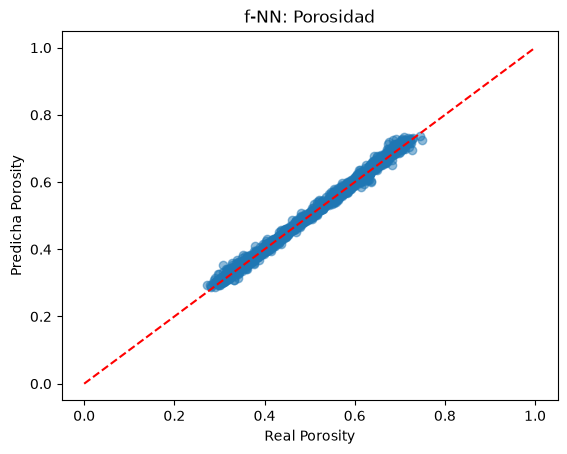

In [11]:
f_nn.eval()
with torch.no_grad():
    preds = f_nn(X_test_t.to(device)).cpu().numpy()
    real = y_test_t.cpu().numpy()

# Desnormalizar para métricas interpretables
preds_orig = scaler_y.inverse_transform(preds)
real_orig = scaler_y.inverse_transform(real)

# R²
ss_res = np.sum((real - preds)**2)
ss_tot = np.sum((real - np.mean(real))**2)
r2 = 1 - ss_res / ss_tot
print(f"R² en test (normalizado): {r2:.4f}")

# Graficar componente Porosidad (índice 5)
plt.scatter(real_orig[:,5], preds_orig[:,5], alpha=0.5)
plt.xlabel("Real Porosity")
plt.ylabel("Predicha Porosity")
plt.title("f‑NN: Porosidad")
plt.plot([0,1],[0,1],'r--')
plt.show()

Congelar

In [12]:
for param in f_nn.parameters():
    param.requires_grad = False

In [13]:
f_nn.load_state_dict(torch.load("modelos/f_nn_best.pt"))
f_nn.eval()

ForwardNN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=7, bias=True)
  )
)

## i-NN

definición

In [14]:
class InverseNN(nn.Module):
    def __init__(self, input_dim=7, output_dim=5, hidden=[128, 128, 64], dropout=0.1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

i_nn = InverseNN().to(device)
print(i_nn)

InverseNN(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=64, out_features=5, bias=True)
  )
)


---
### Función de perdida

In [15]:
def reconstruction_loss(i_nn, f_nn, x_G, y_theta, scaler_X, scaler_y, lambda_reg=0.1):
    # x_G y y_theta ya vienen normalizados de los DataLoaders
    theta_pred_norm = i_nn(x_G)

    # Pasar theta predicha por f-NN (que espera y entrega datos normalizados)
    G_recon_norm = f_nn(theta_pred_norm)

    # MSE de reconstrucción
    mse_recon = nn.MSELoss()(G_recon_norm, x_G)

    # MSE de parámetros (supervisión)
    mse_theta = nn.MSELoss()(theta_pred_norm, y_theta)

    return mse_recon + lambda_reg * mse_theta, mse_recon, mse_theta

---
Entrenamiento

In [16]:
train_loader_inv = DataLoader(TensorDataset(y_train_t, X_train_t), batch_size=64, shuffle=True)
test_loader_inv = DataLoader(TensorDataset(y_test_t, X_test_t), batch_size=64, shuffle=False)

optimizer_i = optim.Adam(i_nn.parameters(), lr=0.001, weight_decay=1e-5)
lambda_reg = 0.1
epochs = 200
patience = 30
best_loss_i = np.inf
counter = 0
i_train_losses, i_val_losses = [], [] 

def lambda_schedule(epoch):
    if epoch < 20:
        return 0.1    # Guía suave, corta
    else:
        return 0.0    # Libertad total

for epoch in range(epochs):
    i_nn.train()
    t_loss = 0
    for batch_G, batch_theta in train_loader_inv:
        batch_G, batch_theta = batch_G.to(device), batch_theta.to(device)
        optimizer_i.zero_grad()
        loss, _, _ = reconstruction_loss(i_nn, f_nn, batch_G, batch_theta, scaler_X, scaler_y, lambda_reg=lambda_schedule(epoch))
        loss.backward()
        optimizer_i.step()
        t_loss += loss.item()
    i_train_losses.append(t_loss / len(train_loader_inv))

    i_nn.eval()
    v_loss = 0
    with torch.no_grad():
        for batch_G, batch_theta in test_loader_inv:
            batch_G, batch_theta = batch_G.to(device), batch_theta.to(device)
            loss, _, _ = reconstruction_loss(i_nn, f_nn, batch_G, batch_theta, scaler_X, scaler_y, lambda_reg=0.0)
            v_loss += loss.item()
    v_loss /= len(test_loader_inv)
    i_val_losses.append(v_loss)

    if v_loss < best_loss_i:
        best_loss_i = v_loss
        counter = 0
        torch.save(i_nn.state_dict(), "modelos/i_nn_best.pt")
    else:
        counter += 1
        if counter >= patience: break

Evaluación

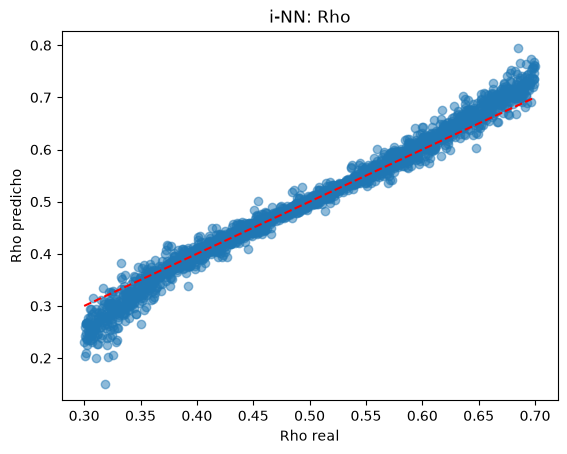

In [17]:
if os.path.exists("modelos/i_nn_best.pt"):
    i_nn.load_state_dict(torch.load("modelos/i_nn_best.pt"))
    i_nn.eval()
    with torch.no_grad():
        theta_pred = i_nn(y_test_t.to(device)).cpu().numpy()
        # Desnormalizar parámetros predichos
        theta_pred_orig = scaler_X.inverse_transform(theta_pred)
        theta_real_orig = scaler_X.inverse_transform(X_test)

    # Comparar Rho (columna 1)
    plt.scatter(theta_real_orig[:,1], theta_pred_orig[:,1], alpha=0.5)
    plt.xlabel("Rho real")
    plt.ylabel("Rho predicho")
    plt.title("i‑NN: Rho")
    plt.plot([0.3,0.7],[0.3,0.7],'r--')
    plt.show()
else:
    print("Error: El archivo 'i_nn_best.pt' no existe. Por favor, limpia los NaNs de tus datos (y_train tiene 7 NaNs) y entrena de nuevo.")

### Visualización de Entrenamiento y Resultados 3D

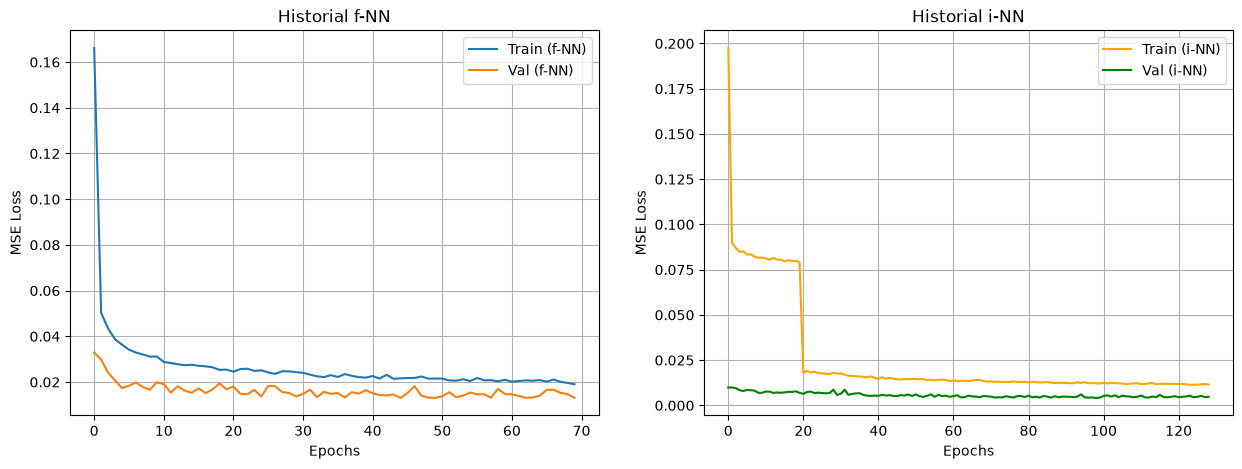

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica f-NN
ax[0].plot(f_train_losses, label='Train (f-NN)')
ax[0].plot(f_val_losses, label='Val (f-NN)')
ax[0].set_title('Historial f-NN')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('MSE Loss')
ax[0].legend()
ax[0].grid(True)

# Gráfica i-NN
ax[1].plot(i_train_losses, label='Train (i-NN)', color='orange')
ax[1].plot(i_val_losses, label='Val (i-NN)', color='green')
ax[1].set_title('Historial i-NN')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('MSE Loss')
ax[1].legend()
ax[1].grid(True)

plt.show()

### Visualización Exhaustiva de Resultados

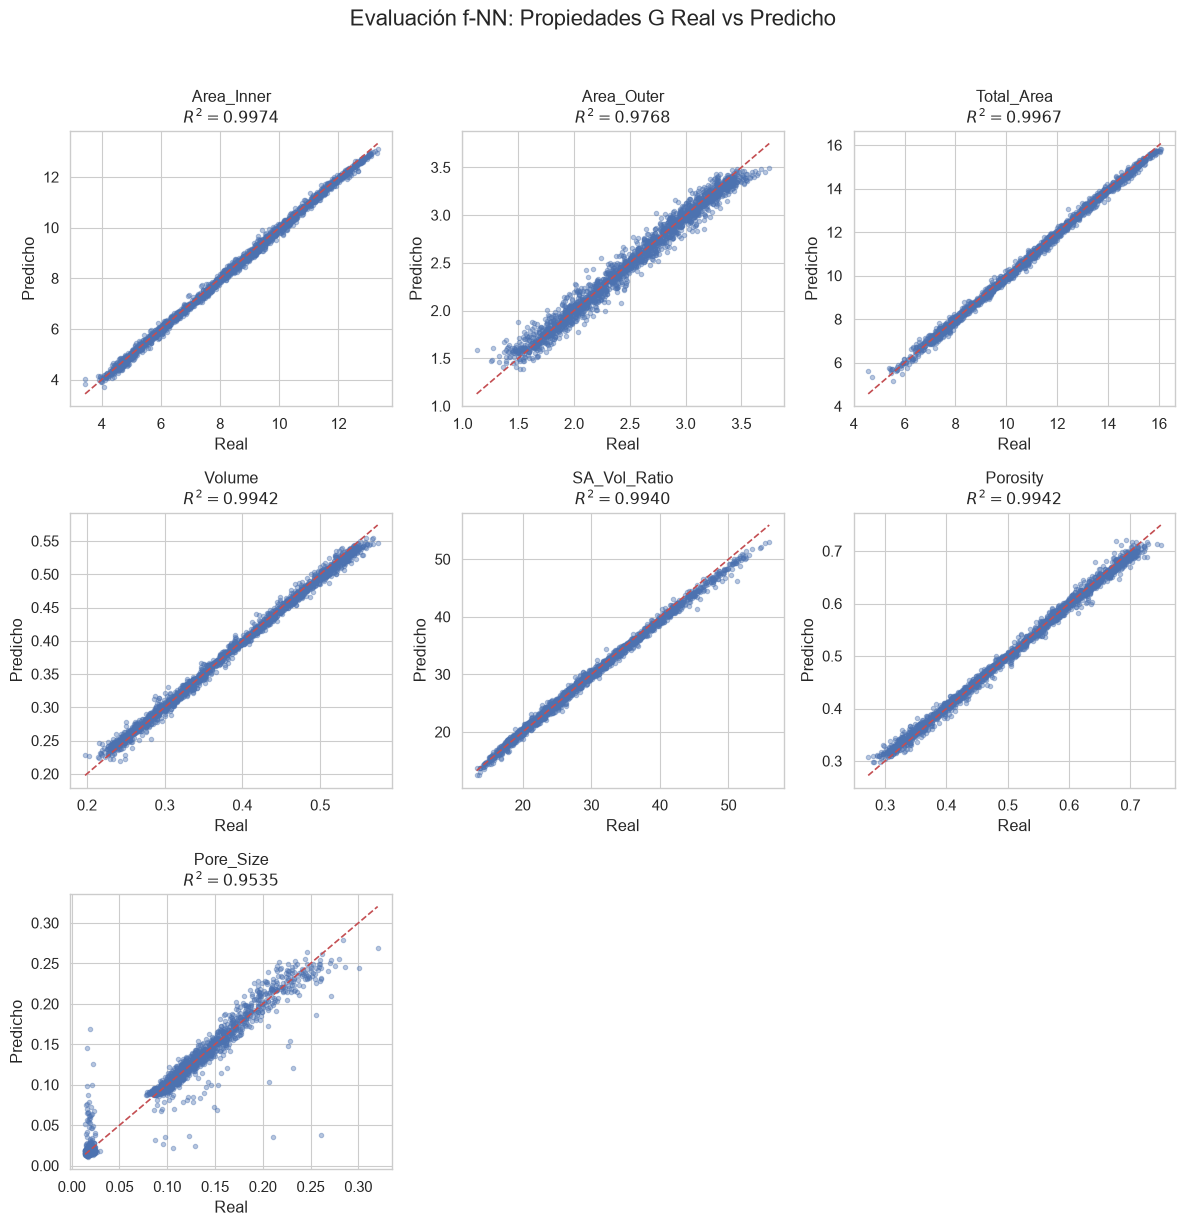

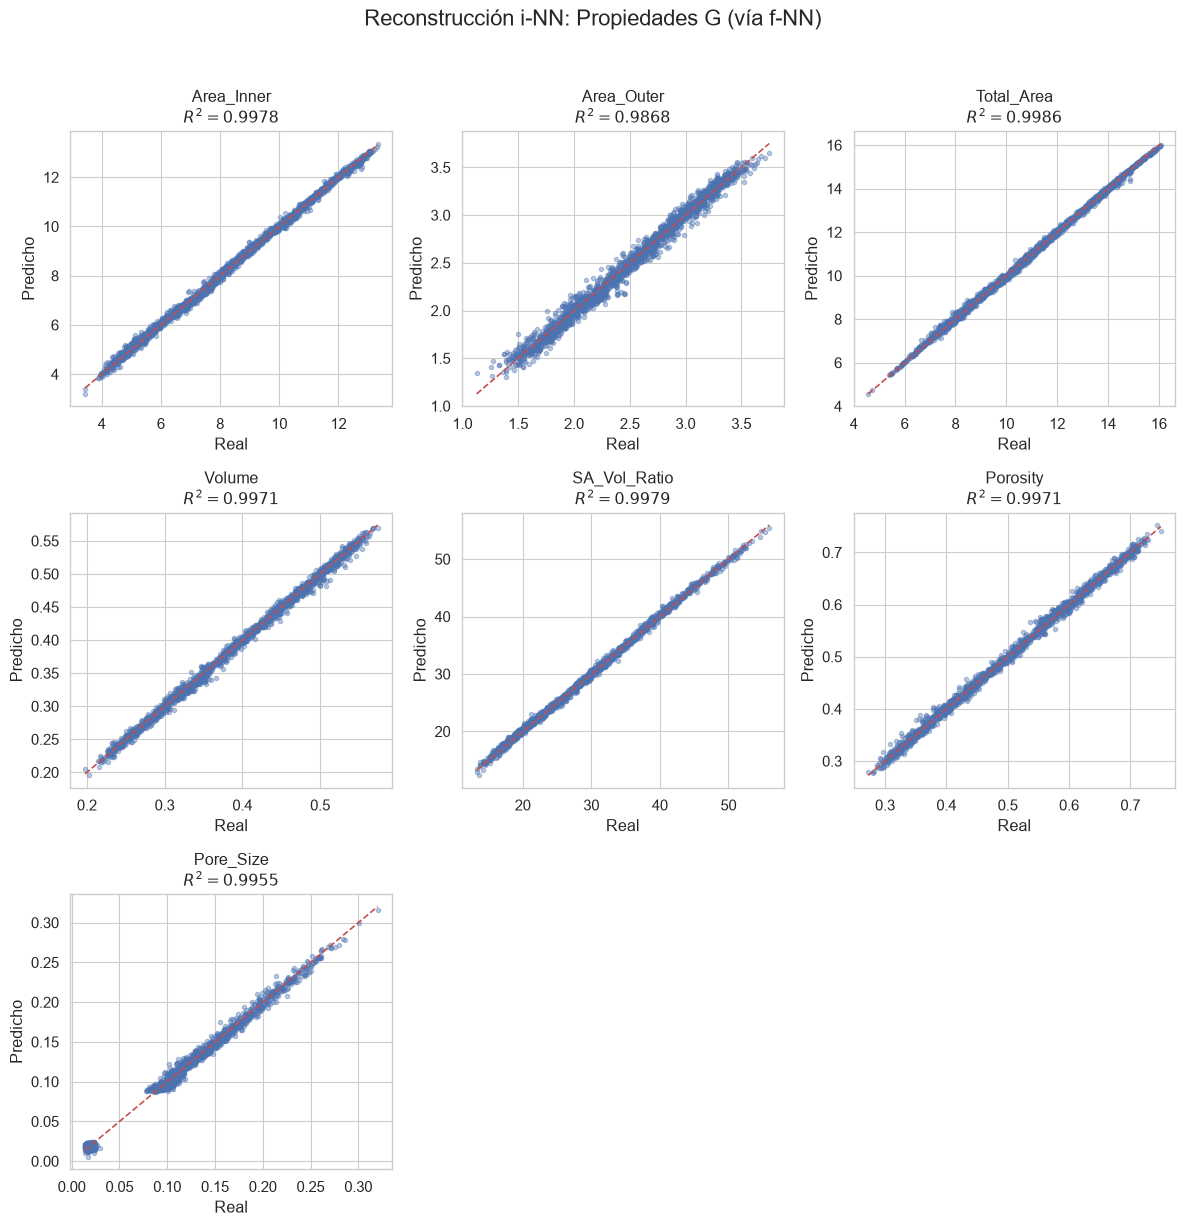

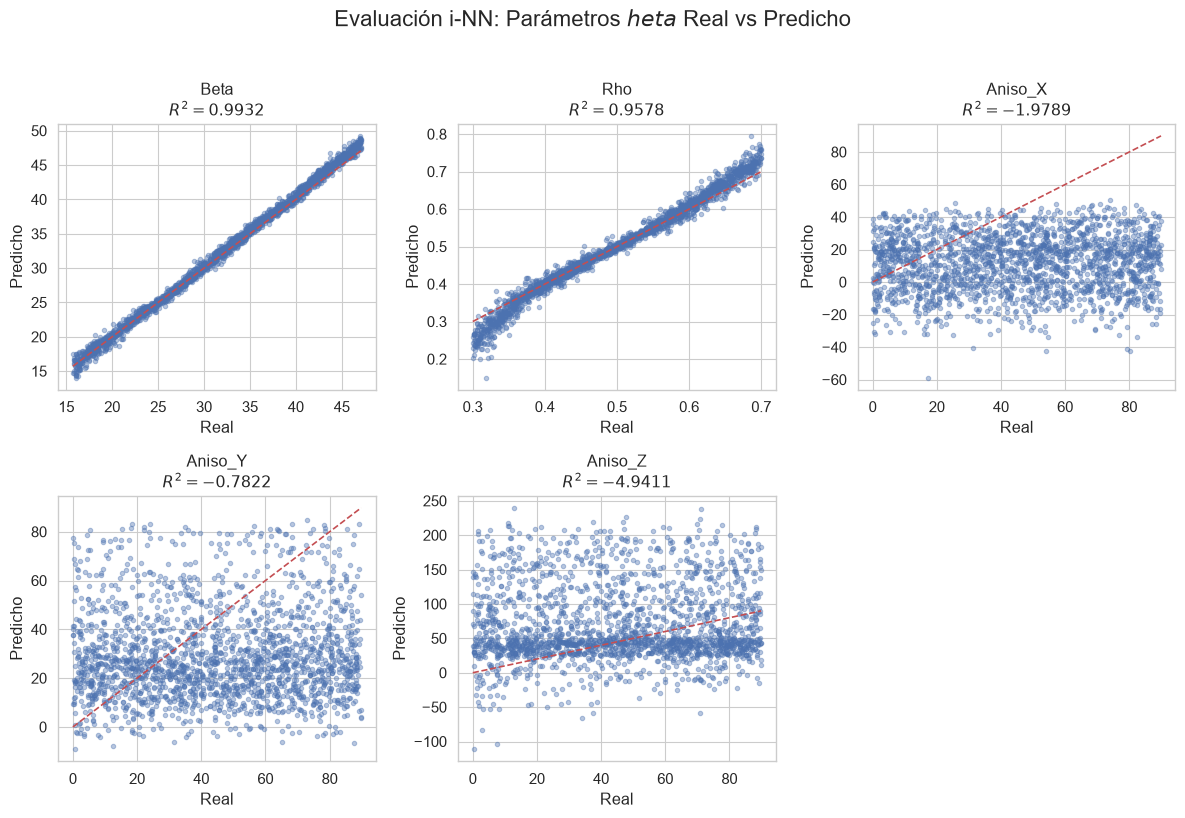

In [19]:
def plot_scatter_grid(real, pred, names, title, rows=3, cols=3):
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten()
    r2_values = []
    for i in range(len(names)):
        r2 = r2_score(real[:, i], pred[:, i])
        r2_values.append(r2)
        axes[i].scatter(real[:, i], pred[:, i], alpha=0.4, s=10)
        min_val, max_val = real[:, i].min(), real[:, i].max()
        axes[i].plot([min_val, max_val], [min_val, max_val], 'r--')
        axes[i].set_title(f"{names[i]}\n$R^2 = {r2:.4f}$")
        axes[i].set_xlabel("Real")
        axes[i].set_ylabel("Predicho")
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    return r2_values



sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
f_nn.eval()
i_nn.eval()

with torch.no_grad():
    # f-NN predictions
    f_preds_norm = f_nn(X_test_t.to(device)).cpu().numpy()
    f_preds = scaler_y.inverse_transform(f_preds_norm)
    f_real = scaler_y.inverse_transform(y_test_t.cpu().numpy())

    # i-NN predictions (Parameters)
    i_theta_preds_norm = i_nn(y_test_t.to(device)).cpu().numpy()
    i_theta_preds = scaler_X.inverse_transform(i_theta_preds_norm)
    i_theta_real = scaler_X.inverse_transform(X_test_t.cpu().numpy())

    # i-NN Reconstruction
    i_recon_norm = f_nn(torch.tensor(i_theta_preds_norm).to(device)).cpu().numpy()
    i_recon = scaler_y.inverse_transform(i_recon_norm)

# Usamos las variables ya calculadas
r2_fnn = plot_scatter_grid(f_real, f_preds, G_cols, "Evaluación f-NN: Propiedades G Real vs Predicho")
r2_recon = plot_scatter_grid(f_real, i_recon, G_cols, "Reconstrucción i-NN: Propiedades G (vía f-NN)")
_ = plot_scatter_grid(i_theta_real, i_theta_preds, theta_cols, "Evaluación i-NN: Parámetros $\theta$ Real vs Predicho", rows=2, cols=3)

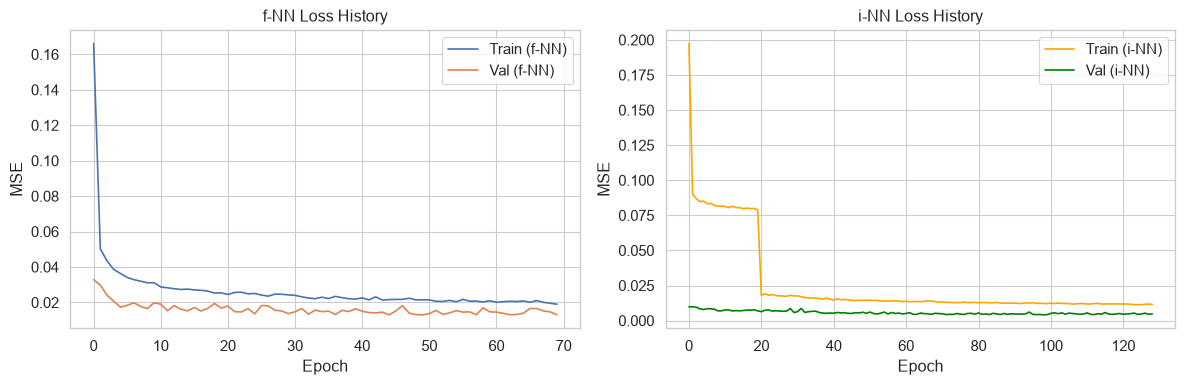

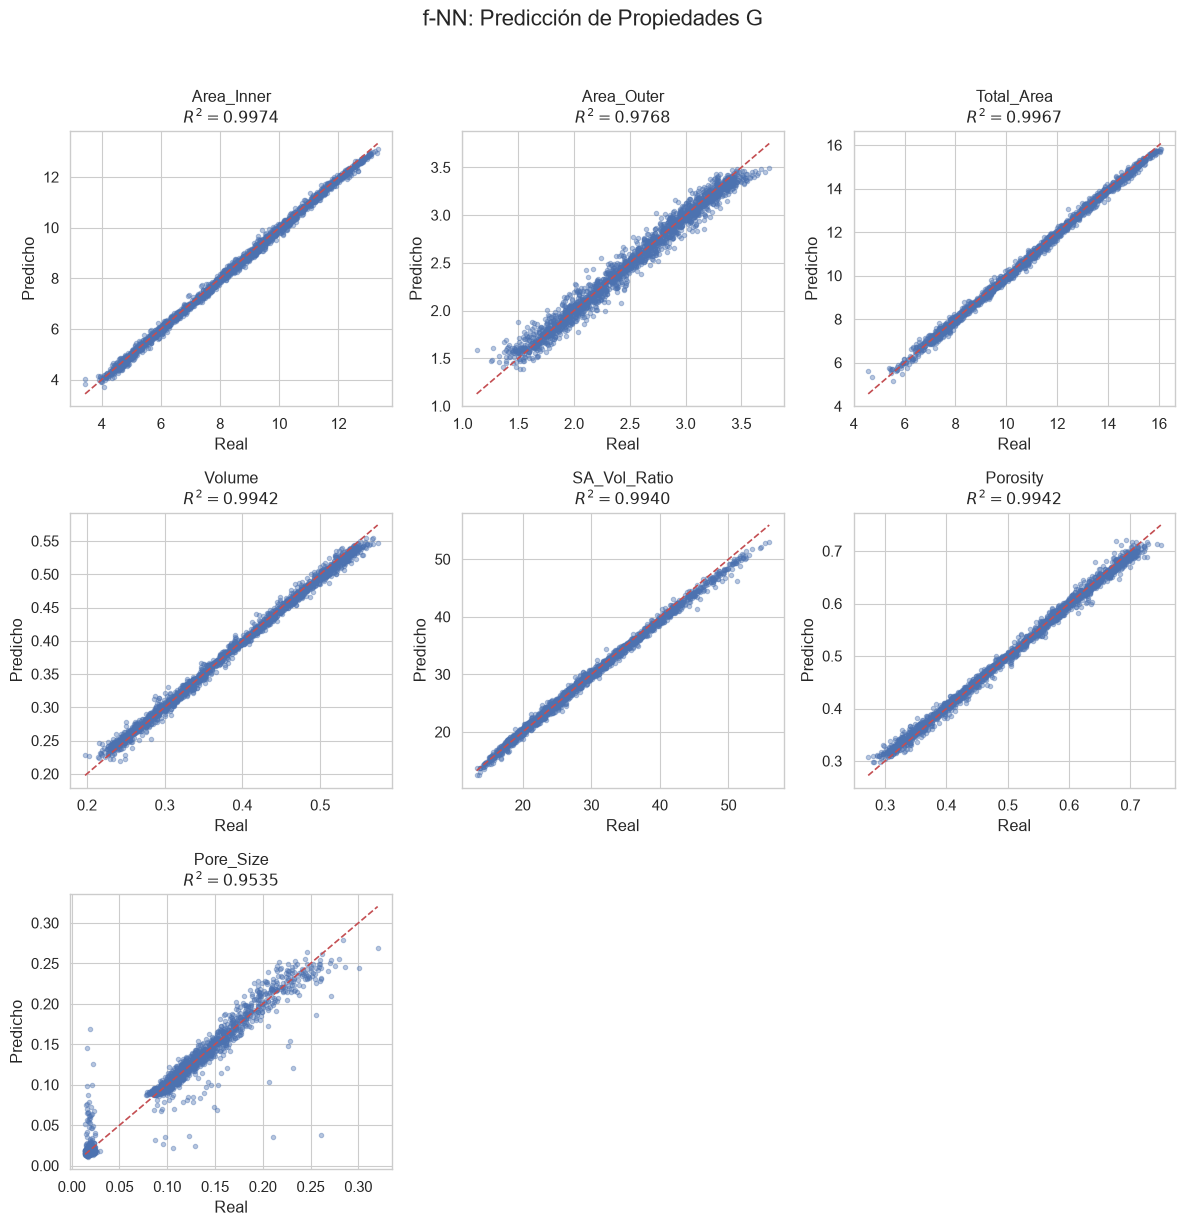

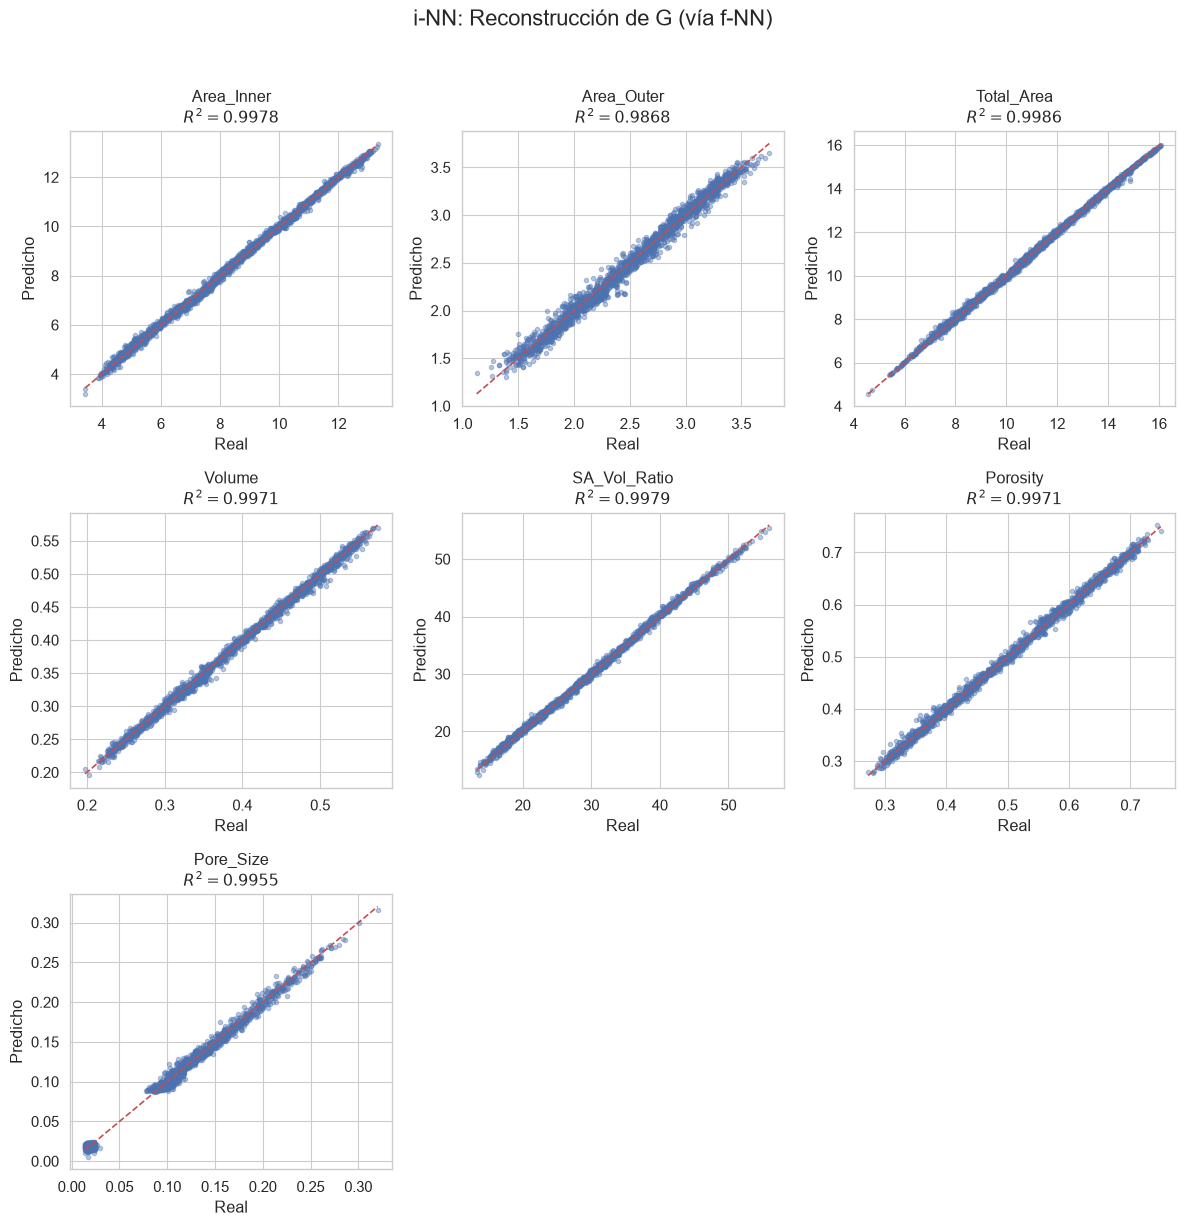

In [20]:
# 1. Preparación de datos y Predicciones
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
f_nn.eval()
i_nn.eval()

with torch.no_grad():
    # f-NN predictions
    f_preds_norm = f_nn(X_test_t.to(device)).cpu().numpy()
    f_preds = scaler_y.inverse_transform(f_preds_norm)
    f_real = scaler_y.inverse_transform(y_test_t.cpu().numpy())

    # i-NN predictions (Parameters)
    i_theta_preds_norm = i_nn(y_test_t.to(device)).cpu().numpy()
    i_theta_preds = scaler_X.inverse_transform(i_theta_preds_norm)
    i_theta_real = scaler_X.inverse_transform(X_test_t.cpu().numpy())

    # i-NN Reconstruction
    i_recon_norm = f_nn(torch.tensor(i_theta_preds_norm).to(device)).cpu().numpy()
    i_recon = scaler_y.inverse_transform(i_recon_norm)

# Plot 1: Curvas de Pérdida con las variables de historial correctas
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(f_train_losses, label='Train (f-NN)')
ax[0].plot(f_val_losses, label='Val (f-NN)')
ax[0].set_title('f-NN Loss History')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE'); ax[0].legend()

ax[1].plot(i_train_losses, label='Train (i-NN)', color='orange')
ax[1].plot(i_val_losses, label='Val (i-NN)', color='green')
ax[1].set_title('i-NN Loss History')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('MSE'); ax[1].legend()
plt.tight_layout(); plt.show()

# Los grids de dispersión utilizan la función ya definida
r2_fnn = plot_scatter_grid(f_real, f_preds, G_cols, 'f-NN: Predicción de Propiedades G')
r2_recon = plot_scatter_grid(f_real, i_recon, G_cols, 'i-NN: Reconstrucción de G (vía f-NN)')

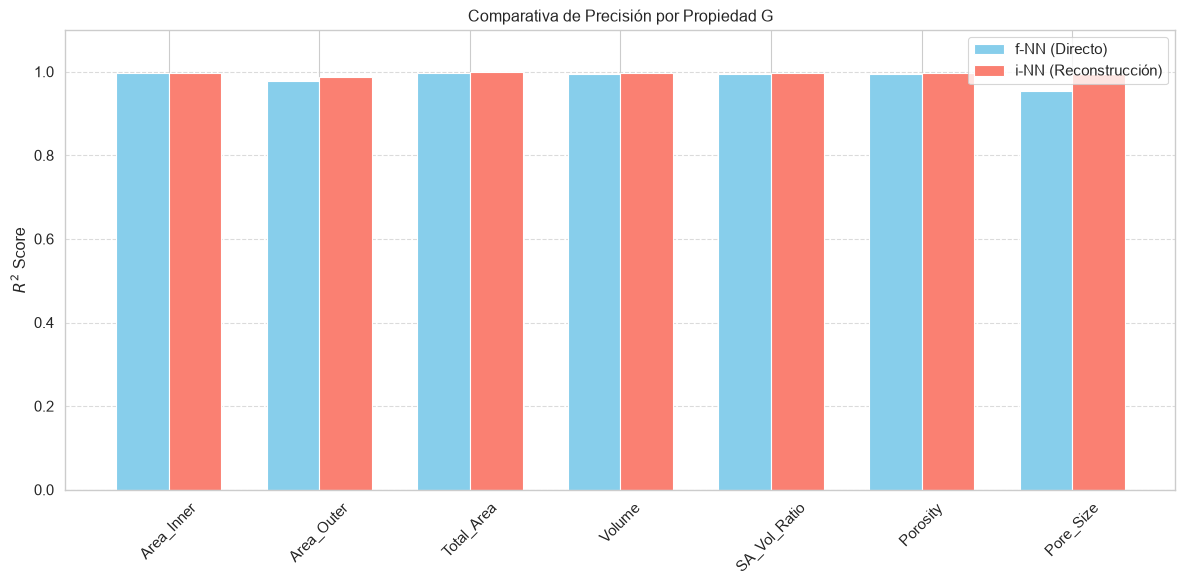

In [21]:
# 5. Comparativa R²
x = np.arange(len(G_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, r2_fnn, width, label='f-NN (Directo)', color='skyblue')
rects2 = ax.bar(x + width/2, r2_recon, width, label='i-NN (Reconstrucción)', color='salmon')

ax.set_ylabel('$R^2$ Score')
ax.set_title('Comparativa de Precisión por Propiedad G')
ax.set_xticks(x)
ax.set_xticklabels(G_cols, rotation=45)
ax.set_ylim(0, 1.1)
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparación Multidimensional: Gráfico de Radar

Este gráfico permite visualizar qué tan cerca están las predicciones de los valores reales en todas las dimensiones de salida ($G$) al mismo tiempo.

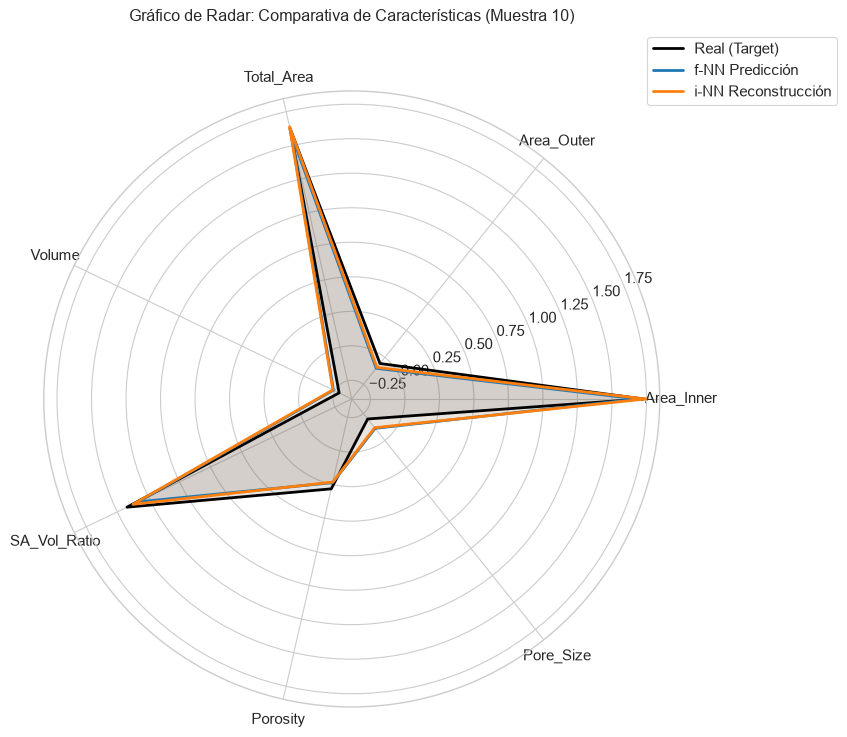

In [22]:
def plot_radar_comparison(real, fnn_pred, inn_recon, feature_names, index=0):
    # Número de variables
    categories = feature_names
    N = len(categories)

    # Lo ideal es usar datos normalizados para que las escalas sean comparables en el radar
    # o normalizar localmente entre 0 y 1 para visualización
    def normalize_row(row):
        return (row - row.min()) / (row.max() - row.min() + 1e-6)

    # Preparar ángulos
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Función auxiliar para cerrar el loop del gráfico
    def add_to_radar(values, label, color):
        values = list(values)
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=2, label=label)
        ax.fill(angles, values, color=color, alpha=0.1)

    # Seleccionar una muestra y normalizar para visualización comparativa
    # Nota: Usamos los datos ya escalados (normalizados) para que el radar no se deforme por magnitudes
    v_real = y_test[index]
    v_fnn = f_preds_norm[index]
    v_inn = i_recon_norm[index]

    add_to_radar(v_real, "Real (Target)", "black")
    add_to_radar(v_fnn, "f-NN Predicción", "#1f77b4")
    add_to_radar(v_inn, "i-NN Reconstrucción", "#ff7f0e")

    # Arreglar etiquetas
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    plt.title(f"Gráfico de Radar: Comparativa de Características (Muestra {index})", y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Visualizar la primera muestra del test set
plot_radar_comparison(y_test, f_preds_norm, i_recon_norm, G_cols, index=10)

### Radar de Desempeño ($R^2$)

Visualización de la precisión ($R^2$) para cada propiedad geométrica, comparando la capacidad predictiva de la f-NN y la capacidad de reconstrucción de la i-NN.

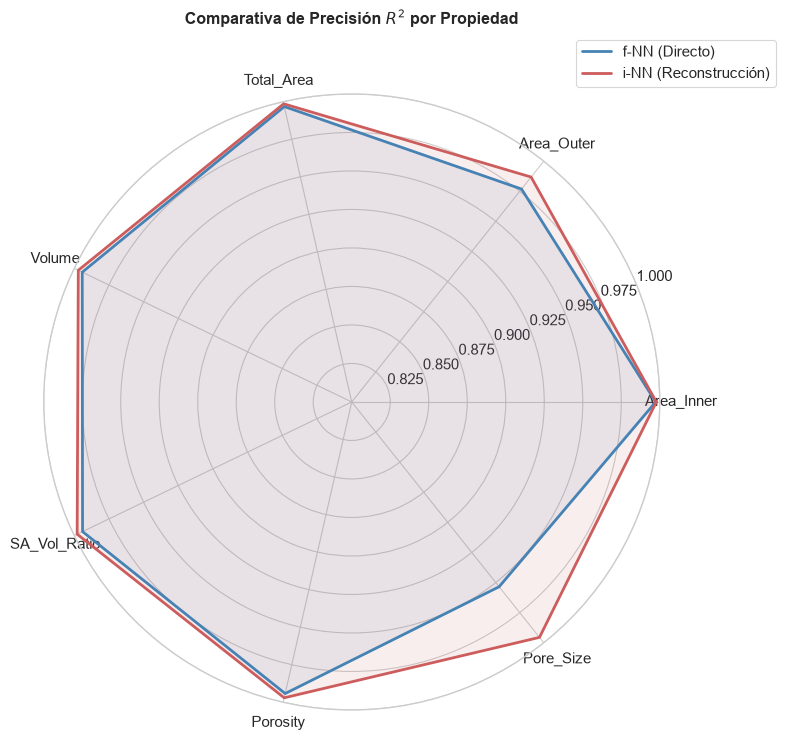

In [23]:
def plot_r2_radar(r2_fnn, r2_recon, categories):
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # f-NN
    values_fnn = list(r2_fnn)
    values_fnn += values_fnn[:1]
    ax.plot(angles, values_fnn, color='steelblue', linewidth=2, label='f-NN (Directo)')
    ax.fill(angles, values_fnn, color='steelblue', alpha=0.1)

    # i-NN Reconstruction
    values_recon = list(r2_recon)
    values_recon += values_recon[:1]
    ax.plot(angles, values_recon, color='indianred', linewidth=2, label='i-NN (Reconstrucción)')
    ax.fill(angles, values_recon, color='indianred', alpha=0.1)

    # Configuración de ejes
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0.8, 1.0) # Enfocamos el rango de alta precisión

    plt.title("Comparativa de Precisión $R^2$ por Propiedad", y=1.1, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.show()

plot_r2_radar(r2_fnn, r2_recon, G_cols)

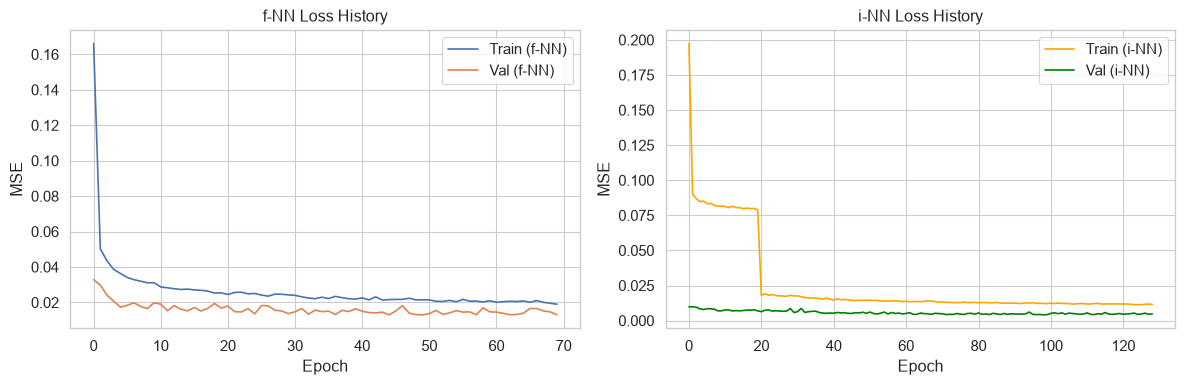

In [24]:
# Plot 1: Historial de Pérdidas corregido
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(f_train_losses, label='Train (f-NN)')
ax[0].plot(f_val_losses, label='Val (f-NN)')
ax[0].set_title('f-NN Loss History')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE'); ax[0].legend()

ax[1].plot(i_train_losses, label='Train (i-NN)', color='orange')
ax[1].plot(i_val_losses, label='Val (i-NN)', color='green')
ax[1].set_title('i-NN Loss History')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('MSE'); ax[1].legend()
plt.tight_layout(); plt.show()

# Los grids de dispersión ya se generan en la celda anterior corregida (ae79e0a9)

### Evaluación de i-NN: Recuperación de Parámetros de Diseño ($\theta$)

Esta gráfica muestra qué tan bien la red inversa puede recuperar los parámetros de entrada originales a partir de las propiedades geométricas.

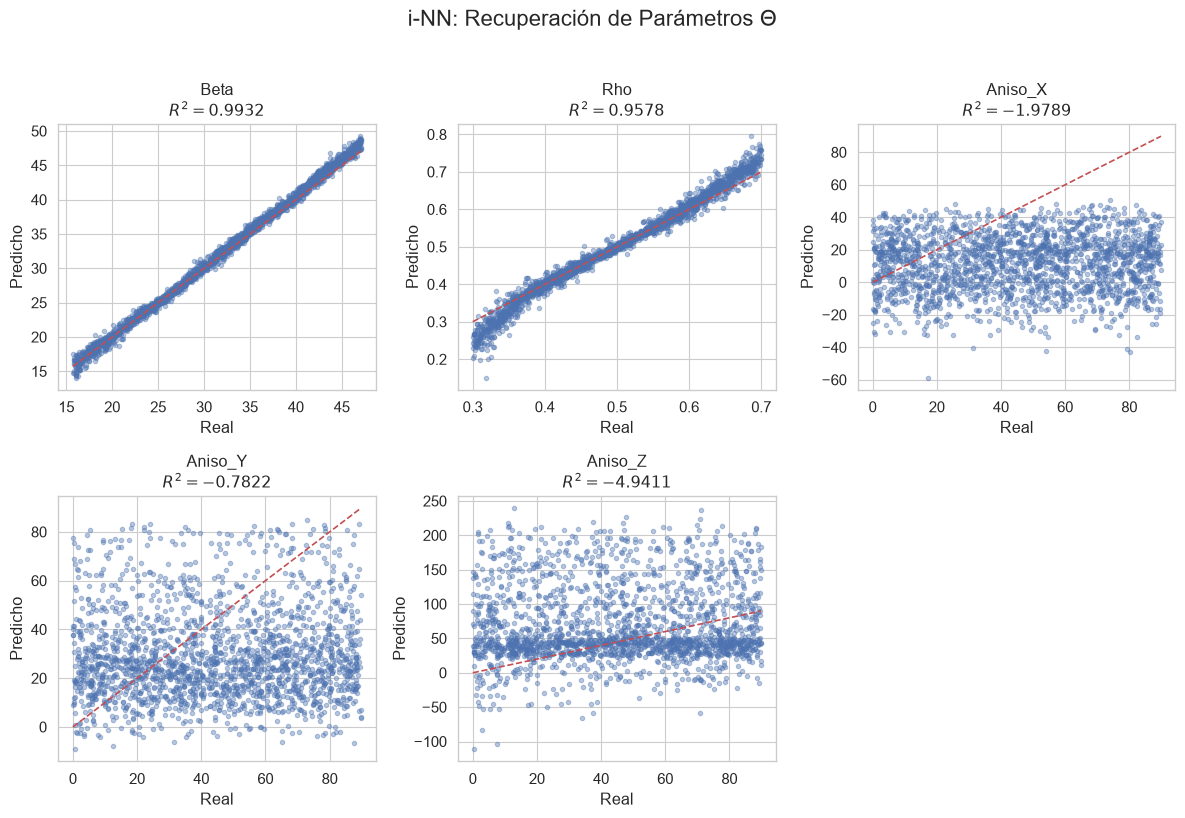

In [25]:
# Graficar la recuperación de los 5 parámetros theta
# Usamos la función plot_scatter_grid definida anteriormente
r2_theta = plot_scatter_grid(
    i_theta_real,
    i_theta_preds,
    theta_cols,
    r'i-NN: Recuperación de Parámetros $\Theta$',
    rows=2,
    cols=3
)

# f-NN Probabilística

## Verosimilitud y log-verosimilitud negativa

Asumimos que la salida objetivo $y_j$ para una entrada $x$ sigue una distribución normal con media y varianza dependientes de la entrada:

$$p(y_j \mid x) = \mathcal{N}(y_j \mid \mu_j(x), \sigma_j^2(x))$$

La **log-verosimilitud negativa (NLL)** está dada por:

$$\text{NLL} = \sum_j \left[ \tfrac{1}{2} \log(\sigma_j^2) + \tfrac{1}{2} \frac{(y_j - \mu_j)^2}{\sigma_j^2} \right]$$

Para evitar varianzas negativas, reparametrizamos $s_j = \log(\sigma_j^2)$:

$$\text{NLL} = \sum_j \left[ \tfrac{1}{2} s_j + \tfrac{1}{2} (y_j - \mu_j)^2 \exp(-s_j) \right]$$

- El primer término penaliza varianzas grandes.
- El segundo pondera el error cuadrático por la precisión, dando menos peso a predicciones con alta incertidumbre.

### Definición

In [26]:
class ForwardNNProb(nn.Module):
    def __init__(self, input_dim=5, output_dim=7, hidden=[512, 256, 256, 128], dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers.extend([nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)])
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.mu_head = nn.Linear(prev, output_dim)      # Media
        self.logvar_head = nn.Linear(prev, output_dim)  # Log(sigma^2)

    def forward(self, x):
        h = self.backbone(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def predict(self, x):
        """Prediccion puntual: solo la media."""
        mu, _ = self.forward(x)
        return mu


def gaussian_nll_loss(mu, logvar, target):
    """
    NLL heterocedastica gaussiana.
    Entrada: mu, logvar, target  ->  todos [batch, 7]
    """
    precision = torch.exp(-logvar)
    squared_error = (target - mu) ** 2
    nll = 0.5 * (logvar + squared_error * precision)
    return nll.mean()

### Entrenamiento

In [27]:
# --- Entrenamiento ---
f_nn_prob = ForwardNNProb().to(device)
optimizer_p = torch.optim.Adam(f_nn_prob.parameters(), lr=0.0005, weight_decay=1e-5)

epochs = 1000
patience = 25
best_loss_p = np.inf
counter_p = 0
p_train_losses, p_val_losses = [], []

for epoch in range(epochs):
    f_nn_prob.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer_p.zero_grad()
        mu, logvar = f_nn_prob(batch_x)
        loss = gaussian_nll_loss(mu, logvar, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(f_nn_prob.parameters(), max_norm=1.0)
        optimizer_p.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    p_train_losses.append(train_loss)

    # Validacion
    f_nn_prob.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            mu, logvar = f_nn_prob(batch_x)
            val_loss += gaussian_nll_loss(mu, logvar, batch_y).item()
    val_loss /= len(test_loader)
    p_val_losses.append(val_loss)

    if val_loss < best_loss_p and not np.isnan(val_loss):
        best_loss_p = val_loss
        counter_p = 0
        torch.save(f_nn_prob.state_dict(), "modelos/f_nn_prob_best.pt")
    else:
        counter_p += 1
        if counter_p >= patience:
            print(f"Early stopping f-NN-prob en epoch {epoch+1}")
            break

Early stopping f-NN-prob en epoch 129


### Evaluación

In [28]:
# Cargar mejor modelo
f_nn_prob.load_state_dict(torch.load("modelos/f_nn_prob_best.pt", map_location=device))
f_nn_prob.eval()

ForwardNNProb(
  (backbone): Sequential(
    (0): Linear(in_features=5, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
  )
  (mu_head): Linear(in_features=128, out_features=7, bias=True)
  (logvar_head): Linear(in_features=128, out_features=7, bias=True)
)

In [29]:
# --- Evaluacion en test ---
with torch.no_grad():
    mu_test, logvar_test = f_nn_prob(X_test_t.to(device))
    mu_test = mu_test.cpu().numpy()
    logvar_test = logvar_test.cpu().numpy()
    real_test = y_test_t.cpu().numpy()

# R^2 de la media (comparar con f-NN determinista)
ss_res = np.sum((real_test - mu_test)**2)
ss_tot = np.sum((real_test - np.mean(real_test))**2)
r2_prob = 1 - ss_res / ss_tot
print(f"R^2 f-NN-prob (media) en test: {r2_prob:.4f}")

# NLL en test
precision = np.exp(-logvar_test)
squared_error = (real_test - mu_test)**2
nll_test = np.mean(0.5 * (logvar_test + squared_error * precision))
print(f"NLL en test: {nll_test:.4f}")


R^2 f-NN-prob (media) en test: 0.9878
NLL en test: -2.0471


In [30]:
# --- Comparativa: f-NN determinista vs f-NN-prob (media) ---
f_nn.eval(); pred_det = f_nn(X_test_t.to(device)).cpu().numpy()

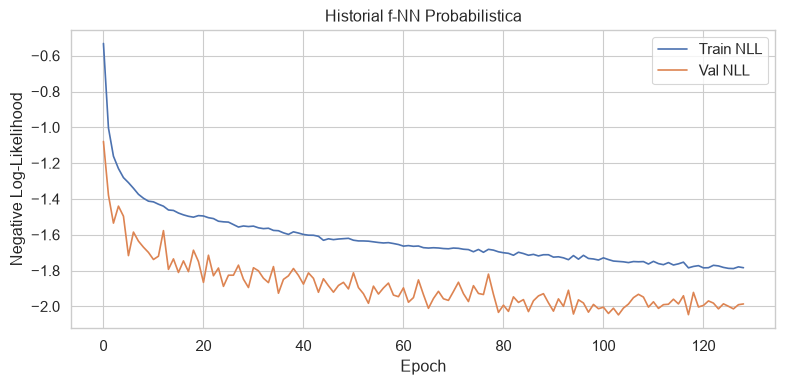

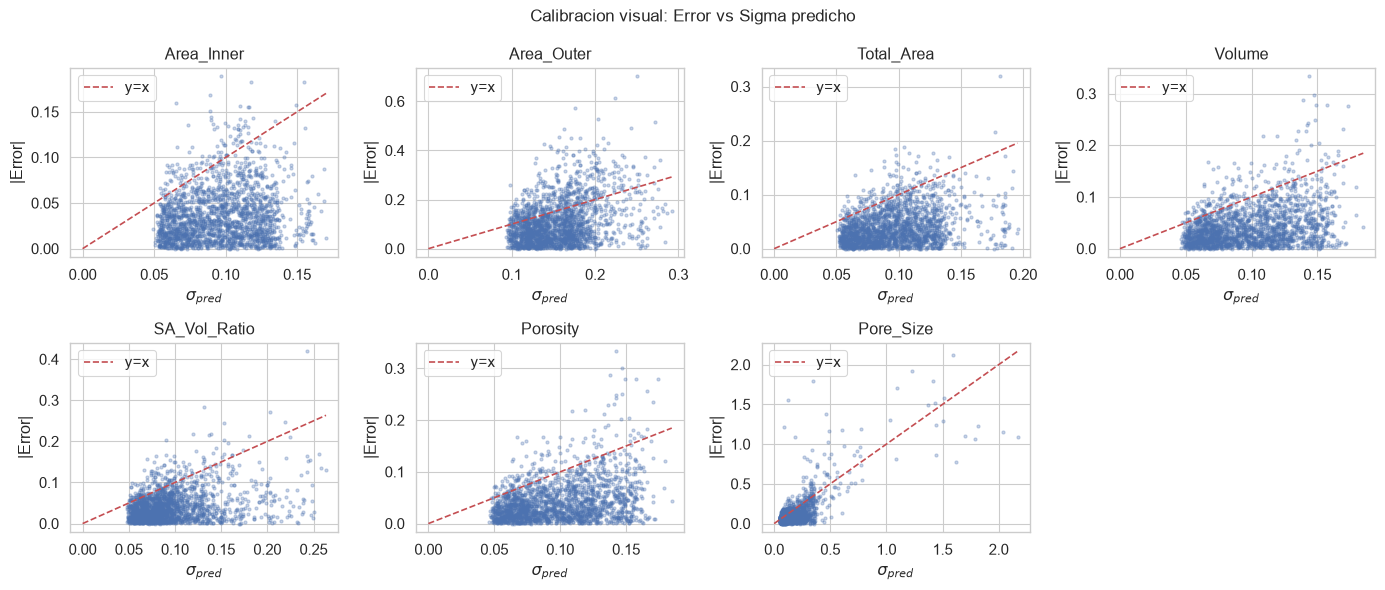

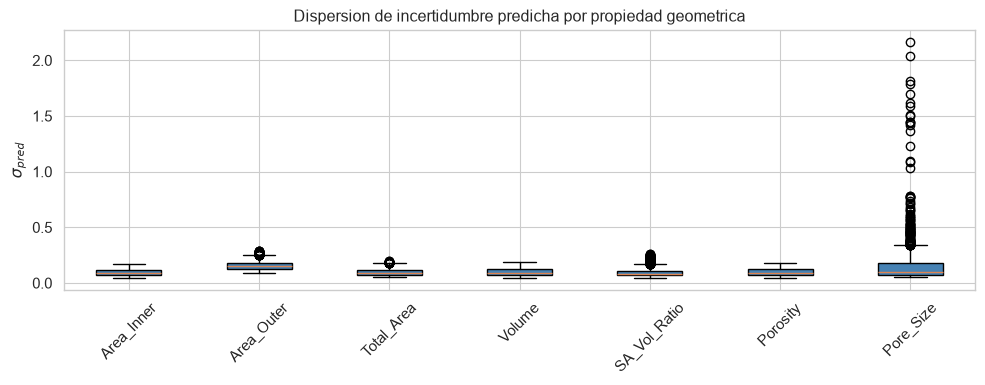

In [31]:
# --- Visualizacion 1: Historial de perdida ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p_train_losses, label='Train NLL')
ax.plot(p_val_losses, label='Val NLL')
ax.set_xlabel('Epoch')
ax.set_ylabel('Negative Log-Likelihood')
ax.set_title('Historial f-NN Probabilistica')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Visualizacion 2: Sigma predicho por propiedad (calibracion visual) ---
sigma_test = np.exp(0.5 * logvar_test)  # sigma = sqrt(exp(logvar)) = exp(0.5*logvar)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for j, col in enumerate(G_cols):
    ax = axes[j]
    # Error absoluto vs sigma predicho
    abs_err = np.abs(real_test[:, j] - mu_test[:, j])
    ax.scatter(sigma_test[:, j], abs_err, alpha=0.3, s=5)
    ax.plot([0, sigma_test[:, j].max()], [0, sigma_test[:, j].max()], 'r--', label='y=x')
    ax.set_xlabel(r'$\sigma_{pred}$')
    ax.set_ylabel('|Error|')
    ax.set_title(col)
    ax.legend()

axes[-1].axis('off')
plt.suptitle('Calibracion visual: Error vs Sigma predicho', fontsize=12)
plt.tight_layout()
plt.show()

# --- Visualizacion 3: Boxplot de sigma por propiedad ---
fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot([sigma_test[:, j] for j in range(7)], tick_labels=G_cols, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
ax.set_ylabel(r'$\sigma_{pred}$')
ax.set_title('Dispersion de incertidumbre predicha por propiedad geometrica')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Diagrama de calibración

**Protocolo:** agrupar predicciones en quintiles según $\sigma^2$ predicho. Para cada quintil, comparar el MSE empírico contra $E[\sigma^2]$. Un modelo bien calibrado cumple $\text{MSE} \approx E[\sigma^2]$ (diagonal $y=x$). Métrica global: Expected Calibration Error (ECE).

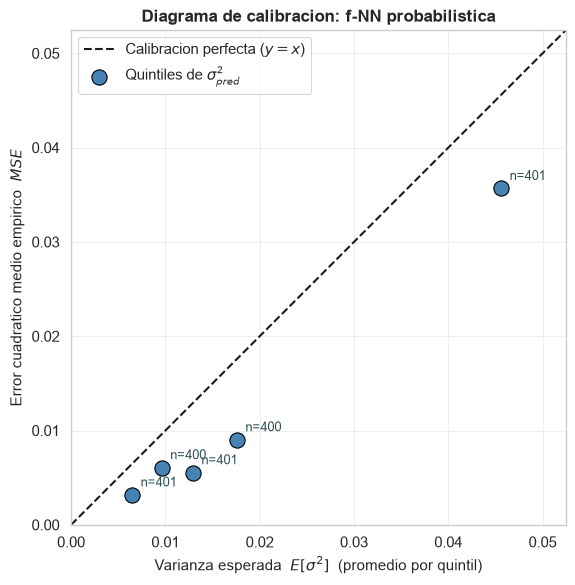


TABLA DE CALIBRACION (copiar a LaTeX)
Quintil    n        E[sigma^2]     MSE empirico   Ratio     
------------------------------------------------------------
1          401      0.006494       0.003186       0.491     
2          400      0.009627       0.006079       0.631     
3          401      0.012942       0.005538       0.428     
4          400      0.017605       0.009035       0.513     
5          401      0.045629       0.035686       0.782     

Expected Calibration Error (ECE): 0.006555
Cuanto mas cercano a cero, mejor calibrado esta el modelo.


In [32]:
# ======================================================================
# DIAGRAMA DE CALIBRACION: f-NN Probabilistica
# ======================================================================
# Protocolo:
#   1. Agrupar predicciones en quintiles segun sigma^2 predicho.
#   2. Para cada quintil: comparar MSE empirico vs E[sigma^2].
#   3. Modelo bien calibrado: MSE_empirico ≈ Varianza_esperada (sobre diagonal).
# ======================================================================


# Asegurar que f_nn_prob esta en evaluacion y en CPU/memoria
f_nn_prob.eval()

with torch.no_grad():
    mu_cal, logvar_cal = f_nn_prob(X_test_t.to(device))
    mu_cal = mu_cal.cpu().numpy()
    logvar_cal = logvar_cal.cpu().numpy()
    y_true_cal = y_test_t.cpu().numpy()

# sigma^2 y error cuadratico por muestra (promedio sobre las 7 dimensiones)
sigma2_mean = np.mean(np.exp(logvar_cal), axis=1)          # [N_test]
mse_per_sample = np.mean((y_true_cal - mu_cal) ** 2, axis=1)  # [N_test]

# Quintiles basados en sigma^2 predicho
n_bins = 5
bin_edges = np.percentile(sigma2_mean, np.linspace(0, 100, n_bins + 1))
bin_edges[-1] += 1e-6  # incluir maximo

bin_centers = []
empirical_mse = []
expected_var = []
counts = []

for i in range(n_bins):
    mask = (sigma2_mean >= bin_edges[i]) & (sigma2_mean < bin_edges[i + 1])
    n = mask.sum()
    if n == 0:
        continue
    counts.append(int(n))
    expected_var.append(float(np.mean(sigma2_mean[mask])))
    empirical_mse.append(float(np.mean(mse_per_sample[mask])))
    bin_centers.append(float(np.median(sigma2_mean[mask])))

# --- Figura para el informe ---
fig, ax = plt.subplots(figsize=(6, 6))

# Diagonal de calibracion perfecta
max_val = max(max(expected_var), max(empirical_mse)) * 1.15
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.5, label='Calibracion perfecta ($y=x$)')

# Puntos de datos
ax.scatter(expected_var, empirical_mse, s=120, c='steelblue',
           edgecolors='black', zorder=5, label=r'Quintiles de $\sigma^2_{pred}$')

# Anotaciones con n
for x, y, n in zip(expected_var, empirical_mse, counts):
    ax.annotate(f"n={n}", (x, y), textcoords="offset points",
                xytext=(6, 6), fontsize=9, color='darkslategray')

ax.set_xlabel("Varianza esperada  $E[\\sigma^2]$  (promedio por quintil)", fontsize=11)
ax.set_ylabel("Error cuadratico medio empirico  $MSE$", fontsize=11)
ax.set_title("Diagrama de calibracion: f-NN probabilistica", fontsize=12, fontweight='bold')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("figuras/calibration_diagram.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Tabla para pegar en LaTeX ---
print("\n" + "="*60)
print("TABLA DE CALIBRACION (copiar a LaTeX)")
print("="*60)
print(f"{'Quintil':<10} {'n':<8} {'E[sigma^2]':<14} {'MSE empirico':<14} {'Ratio':<10}")
print("-"*60)
for i in range(len(counts)):
    ratio = empirical_mse[i] / expected_var[i] if expected_var[i] > 0 else 0
    print(f"{i+1:<10} {counts[i]:<8} {expected_var[i]:<14.6f} {empirical_mse[i]:<14.6f} {ratio:<10.3f}")
print("="*60)

# Metrica de calibracion global: Expected Calibration Error (ECE)
ece = np.mean(np.abs(np.array(empirical_mse) - np.array(expected_var)))
print(f"\nExpected Calibration Error (ECE): {ece:.6f}")
print("Cuanto mas cercano a cero, mejor calibrado esta el modelo.")

# Curva de aprendizaje (f-NN)

**Protocolo:** entrenar la f-NN desde cero con subconjuntos del 5%, 10%, 25%, 50% y 100% del train set, repitiendo con 5 semillas (100–104). Test fijo (20% del dataset). Métrica: $R^2$ promedio en test por fracción.

CURVA DE APRENDIZAJE f-NN
Test fijo: 2003 muestras
Train base: 8008 muestras
Fracciones: [0.05, 0.1, 0.25, 0.5, 1.0]
Semillas por fraccion: 5
----------------------------------------------------------------------

--- Fraccion: 5% ---
  Seed 100 | n_train= 400 | R2_mean=0.9786 | Epocas=99
  Seed 101 | n_train= 400 | R2_mean=0.9769 | Epocas=143
  Seed 102 | n_train= 400 | R2_mean=0.9778 | Epocas=123
  Seed 103 | n_train= 400 | R2_mean=0.9770 | Epocas=171
  Seed 104 | n_train= 400 | R2_mean=0.9789 | Epocas=105

--- Fraccion: 10% ---
  Seed 100 | n_train= 800 | R2_mean=0.9825 | Epocas=98
  Seed 101 | n_train= 800 | R2_mean=0.9808 | Epocas=80
  Seed 102 | n_train= 800 | R2_mean=0.9811 | Epocas=94
  Seed 103 | n_train= 800 | R2_mean=0.9823 | Epocas=116
  Seed 104 | n_train= 800 | R2_mean=0.9814 | Epocas=83

--- Fraccion: 25% ---
  Seed 100 | n_train=2002 | R2_mean=0.9843 | Epocas=134
  Seed 101 | n_train=2002 | R2_mean=0.9852 | Epocas=97
  Seed 102 | n_train=2002 | R2_mean=0.9845 | Epocas=7

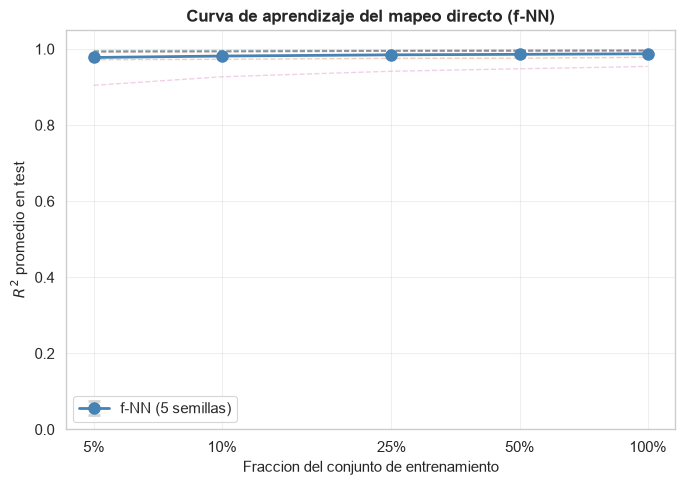

In [33]:


# --- Configuracion ---
FRACTIONS = [0.05, 0.10, 0.25, 0.50, 1.00]
N_SEEDS = 5
SEEDS = [100, 101, 102, 103, 104]

# Hiperparametros (mismos del avance parcial)
LR = 5e-4
WEIGHT_DECAY = 1e-5
BATCH_SIZE = 64
MAX_EPOCHS = 1000
PATIENCE = 25
GRAD_CLIP = 1.0

records = []

print("=" * 70)
print("CURVA DE APRENDIZAJE f-NN")
print("=" * 70)
print(f"Test fijo: {len(X_test)} muestras")
print(f"Train base: {len(X_train)} muestras")
print(f"Fracciones: {FRACTIONS}")
print(f"Semillas por fraccion: {N_SEEDS}")
print("-" * 70)

for frac in FRACTIONS:
    print(f"\n--- Fraccion: {frac*100:.0f}% ---")

    for seed in SEEDS:
        # 1. Submuestrear train
        rng = np.random.RandomState(seed)
        n_sub = max(1, int(len(X_train) * frac))
        idx = rng.choice(len(X_train), size=n_sub, replace=False)
        X_sub = X_train[idx]
        y_sub = y_train[idx]

        # 2. DataLoaders
        train_ds = TensorDataset(torch.tensor(X_sub, dtype=torch.float32),
                                 torch.tensor(y_sub, dtype=torch.float32))
        test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                torch.tensor(y_test, dtype=torch.float32))
        train_loader_sub = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader_sub = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

        # 3. Entrenar modelo desde cero con semilla
        torch.manual_seed(seed)
        model = ForwardNN().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        criterion = nn.MSELoss()

        best_val = np.inf
        counter = 0
        best_state = None

        for epoch in range(MAX_EPOCHS):
            # Train
            model.train()
            train_loss = 0
            for xb, yb in train_loader_sub:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                pred = model(xb)
                loss = criterion(pred, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
                train_loss += loss.item()

            # Val
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for xb, yb in val_loader_sub:
                    xb, yb = xb.to(device), yb.to(device)
                    pred = model(xb)
                    val_loss += criterion(pred, yb).item()
            val_loss /= len(val_loader_sub)

            if val_loss < best_val and not np.isnan(val_loss):
                best_val = val_loss
                counter = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                counter += 1
                if counter >= PATIENCE:
                    break

        # Cargar mejor modelo
        if best_state is not None:
            model.load_state_dict(best_state)
        model = model.cpu().eval()

        # 4. Evaluar en test fijo
        with torch.no_grad():
            y_pred = model(torch.tensor(X_test, dtype=torch.float32)).numpy()

        # R^2 por dimension
        r2s = []
        for j in range(y_test.shape[1]):
            ss_res = np.sum((y_test[:, j] - y_pred[:, j]) ** 2)
            ss_tot = np.sum((y_test[:, j] - np.mean(y_test[:, j])) ** 2)
            r2s.append(1 - ss_res / ss_tot if ss_tot > 1e-12 else 1.0)

        r2_mean = np.mean(r2s)

        print(f"  Seed {seed} | n_train={n_sub:4d} | R2_mean={r2_mean:.4f} | Epocas={epoch+1}")

        # Guardar registro
        record = {
            'fraction': frac,
            'n_train': n_sub,
            'seed': seed,
            'r2_mean': r2_mean,
            'best_val_loss': best_val,
            'epochs': epoch + 1
        }
        for j, col in enumerate(G_cols):
            record[f'r2_{col}'] = r2s[j]
        records.append(record)

# --- DataFrame y CSV ---
df_lc = pd.DataFrame(records)
df_lc.to_csv("jsones/learning_curve_fnn.csv", index=False)
print(f"\n[OK] CSV guardado: learning_curve_fnn.csv")

# --- Tabla resumen para LaTeX ---
print("\n" + "=" * 70)
print("TABLA RESUMEN (copiar a LaTeX)")
print("=" * 70)
summary = df_lc.groupby('fraction').agg(
    n_train=('n_train', 'first'),
    r2_mean=('r2_mean', 'mean'),
    r2_std=('r2_mean', 'std'),
    epochs_mean=('epochs', 'mean')
).reset_index()
print(summary.to_string(index=False))
print("=" * 70)

# --- Figura para el informe ---
fig, ax = plt.subplots(figsize=(7, 5))

# Promedio y std por fraccion
fracs = summary['fraction'].values
means = summary['r2_mean'].values
stds = summary['r2_std'].values

ax.errorbar(fracs, means, yerr=stds, fmt='o-', color='steelblue',
            ecolor='lightgray', elinewidth=2, capsize=4, capthick=2,
            markersize=8, linewidth=2, label='f-NN (5 semillas)')

# R^2 por propiedad (lineas finas)
for col in G_cols:
    sub = df_lc.groupby('fraction')[f'r2_{col}'].mean()
    ax.plot(sub.index, sub.values, '--', alpha=0.4, linewidth=1)

ax.set_xlabel('Fraccion del conjunto de entrenamiento', fontsize=11)
ax.set_ylabel(r'$R^2$ promedio en test', fontsize=11)
ax.set_title('Curva de aprendizaje del mapeo directo (f-NN)', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.set_xticks(FRACTIONS)
ax.set_xticklabels([f"{int(f*100)}%" for f in FRACTIONS])
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("figuras/learning_curve_fnn.png", dpi=300, bbox_inches='tight')
plt.show()

# Procesos Gaussianos (GPR)

Se entrena un GP independiente por cada una de las 7 propiedades geométricas.

**Kernel:** $k = \text{ConstantKernel} \cdot \text{RBF}(\ell_1, \ldots, \ell_5) + \text{WhiteKernel}$, con longitudes de escala separadas por dimensión y ruido homocedástico.

**Nota:** GPR escala como $\mathcal{O}(n^3)$. Si es lento, ajustar `MAX_TRAIN_GP` a 1500 o 1000.

### Entrenamiento y evaluación

[INFO] Submuestreando train de 8008 a 2240 muestras para GP...
Train GP: 2240 | Test: 2003

Entrenando GP independiente por propiedad...

[1/7] Area_Inner... 

c:\Users\vague\anaconda3\envs\miniproyecto\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\vague\anaconda3\envs\miniproyecto\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


R2=0.9992 | MSE=0.000830 | sigma_mean=0.0271 | 154.5s

[2/7] Area_Outer... R2=0.9882 | MSE=0.011351 | sigma_mean=0.1014 | 167.9s

[3/7] Total_Area... 

c:\Users\vague\anaconda3\envs\miniproyecto\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


R2=0.9983 | MSE=0.001673 | sigma_mean=0.0381 | 145.8s

[4/7] Volume... R2=0.9964 | MSE=0.003490 | sigma_mean=0.0538 | 127.0s

[5/7] SA_Vol_Ratio... 

c:\Users\vague\anaconda3\envs\miniproyecto\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


R2=0.9974 | MSE=0.002554 | sigma_mean=0.0508 | 136.4s

[6/7] Porosity... R2=0.9964 | MSE=0.003506 | sigma_mean=0.0539 | 119.1s

[7/7] Pore_Size... 

c:\Users\vague\anaconda3\envs\miniproyecto\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\vague\anaconda3\envs\miniproyecto\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


R2=0.9448 | MSE=0.055189 | sigma_mean=0.2417 | 187.3s

RESUMEN GPR
Propiedad                R2          MSE   Sigma_mean
----------------------------------------------------------------------
Area_Inner           0.9992     0.000830     0.027140
Area_Outer           0.9882     0.011351     0.101362
Total_Area           0.9983     0.001673     0.038132
Volume               0.9964     0.003490     0.053795
SA_Vol_Ratio         0.9974     0.002554     0.050813
Porosity             0.9964     0.003506     0.053888
Pore_Size            0.9448     0.055189     0.241695
----------------------------------------------------------------------
PROMEDIO             0.9887     0.011227

[OK] gp_metrics.json guardado.


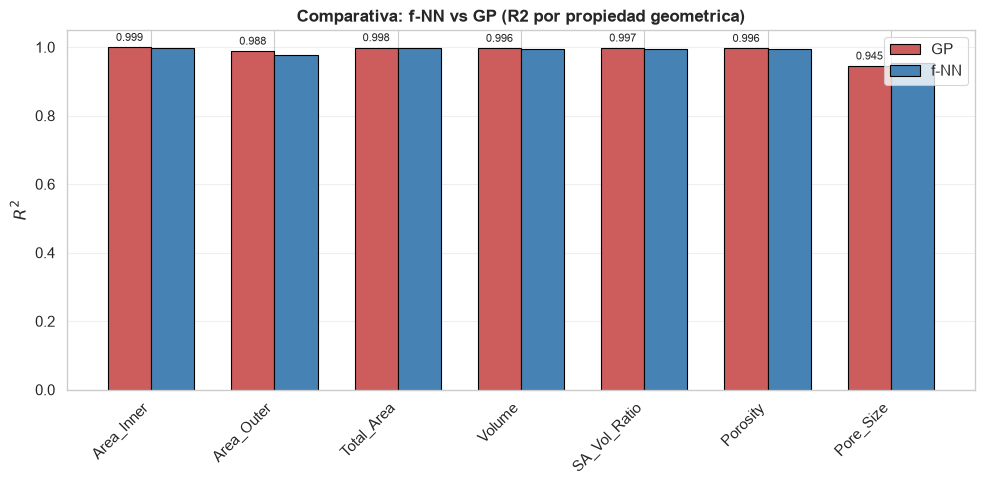

In [34]:
# --- Configuracion ---
MAX_TRAIN_GP = 2240  # bajar si el GP es lento (O(n^3))

# Submuestreo opcional para velocidad
if len(X_train) > MAX_TRAIN_GP:
    print(f"[INFO] Submuestreando train de {len(X_train)} a {MAX_TRAIN_GP} muestras para GP...")
    rng = np.random.RandomState(42)
    idx_gp = rng.choice(len(X_train), size=MAX_TRAIN_GP, replace=False)
    X_train_gp = X_train[idx_gp]
    y_train_gp = y_train[idx_gp]
else:
    X_train_gp = X_train
    y_train_gp = y_train

print(f"Train GP: {len(X_train_gp)} | Test: {len(X_test)}")

# --- Kernel base ---
# ConstantKernel * RBF: amplitud adaptable + longitud de escala por dimension
# WhiteKernel: ruido homocedastico
kernel_base = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[1.0] * 5,           # 5 dimensiones de entrada
    length_scale_bounds=(1e-2, 10.0)
) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))

# --- Entrenamiento: un GP por propiedad ---
gp_results = []
gp_models = []  # guardar modelos para comprobacion posterior
y_pred_gp = np.zeros_like(y_test)      # [N_test, 7]
sigma_gp = np.zeros_like(y_test)       # [N_test, 7]

print("\n" + "=" * 70)
print("Entrenando GP independiente por propiedad...")
print("=" * 70)

for j, col in enumerate(G_cols):
    print(f"\n[{j+1}/7] {col}...", end=" ")
    t0 = time.time()

    gp = GaussianProcessRegressor(
        kernel=kernel_base,
        n_restarts_optimizer=2,      # Pocas restarts para velocidad
        normalize_y=False,            # Ya normalizamos nosotros
        alpha=1e-6,                  # Estabilidad numerica
        random_state=42
    )

    gp.fit(X_train_gp, y_train_gp[:, j])
    gp_models.append(gp)

    # Prediccion con incertidumbre
    mu, sigma = gp.predict(X_test, return_std=True)
    y_pred_gp[:, j] = mu
    sigma_gp[:, j] = sigma

    # R^2
    ss_res = np.sum((y_test[:, j] - mu) ** 2)
    ss_tot = np.sum((y_test[:, j] - np.mean(y_test[:, j])) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 1e-12 else 1.0

    elapsed = time.time() - t0
    print(f"R2={r2:.4f} | MSE={np.mean((y_test[:, j]-mu)**2):.6f} | sigma_mean={np.mean(sigma):.4f} | {elapsed:.1f}s")

    gp_results.append({
        'property': col,
        'r2': float(r2),
        'mse': float(np.mean((y_test[:, j] - mu) ** 2)),
        'sigma_mean': float(np.mean(sigma)),
        'sigma_std': float(np.std(sigma)),
        'time_seconds': float(elapsed),
        'kernel_optimized': str(gp.kernel_)
    })

# --- Metricas globales ---
r2s_gp = [r['r2'] for r in gp_results]
mses_gp = [r['mse'] for r in gp_results]

print("\n" + "=" * 70)
print("RESUMEN GPR")
print("=" * 70)
print(f"{'Propiedad':<18} {'R2':>8} {'MSE':>12} {'Sigma_mean':>12}")
print("-" * 70)
for r in gp_results:
    print(f"{r['property']:<18} {r['r2']:>8.4f} {r['mse']:>12.6f} {r['sigma_mean']:>12.6f}")
print("-" * 70)
print(f"{'PROMEDIO':<18} {np.mean(r2s_gp):>8.4f} {np.mean(mses_gp):>12.6f}")
print("=" * 70)

# --- Guardar JSON ---
gp_output = {
    'per_property': gp_results,
    'summary': {
        'r2_mean': float(np.mean(r2s_gp)),
        'r2_std': float(np.std(r2s_gp)),
        'mse_mean': float(np.mean(mses_gp)),
        'mse_std': float(np.std(mses_gp)),
        'n_train': len(X_train_gp),
        'n_test': len(X_test)
    }
}

with open("jsones/gp_metrics.json", "w") as f:
    json.dump(gp_output, f, indent=2)
print("\n[OK] gp_metrics.json guardado.")

# --- Figura comparativa: f-NN vs GP (R2 por propiedad) ---
# Necesitas haber corrido la f-NN determinista primero para tener pred_det
# Si no la tienes, comenta esta seccion o entrena una rapido

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(G_cols))
width = 0.35

# R2 del GP
bars_gp = ax.bar(x - width/2, r2s_gp, width, label='GP', color='indianred', edgecolor='black')

# R2 de la f-NN determinista (si existe)
if 'pred_det' in globals():
    r2s_fn = []
    for j in range(len(G_cols)):
        ss_res = np.sum((y_test[:, j] - pred_det[:, j]) ** 2)
        ss_tot = np.sum((y_test[:, j] - np.mean(y_test[:, j])) ** 2)
        r2s_fn.append(1 - ss_res / ss_tot if ss_tot > 1e-12 else 1.0)
    bars_fn = ax.bar(x + width/2, r2s_fn, width, label='f-NN', color='steelblue', edgecolor='black')
else:
    print("\n[NOTA] No se encontro 'pred_det'. Entrena la f-NN determinista para la comparativa visual.")

ax.set_ylabel(r'$R^2$', fontsize=12)
ax.set_title('Comparativa: f-NN vs GP (R2 por propiedad geometrica)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(G_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Anotar valores sobre barras
for bar in bars_gp:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("figuras/comparison_fnn_gp.png", dpi=300, bbox_inches='tight')
plt.show()

## Calibración de incertidumbre del GP

Mismo protocolo que la f-NN-prob: quintiles por $\sigma^2$ predicho, MSE empírico
vs $\mathbb{E}[\sigma^2]$ por quintil y ECE. Permite comparar directamente qué modelo
entrega la incertidumbre más honesta.

Requiere `sigma_gp` y `y_pred_gp` en memoria (celda anterior).

CALIBRACION GP (quintiles de sigma^2 predicho)
Quintil        n    E[sigma^2]  MSE empirico    Ratio
--------------------------------------------------------------
1            401      0.010459      0.008277    0.791
2            400      0.010745      0.007791    0.725
3            401      0.011059      0.008783    0.794
4            400      0.011517      0.015809    1.373
5            401      0.012969      0.015479    1.194
--------------------------------------------------------------
ECE GP: 0.002842
ECE f-NN-prob (referencia): 0.006555


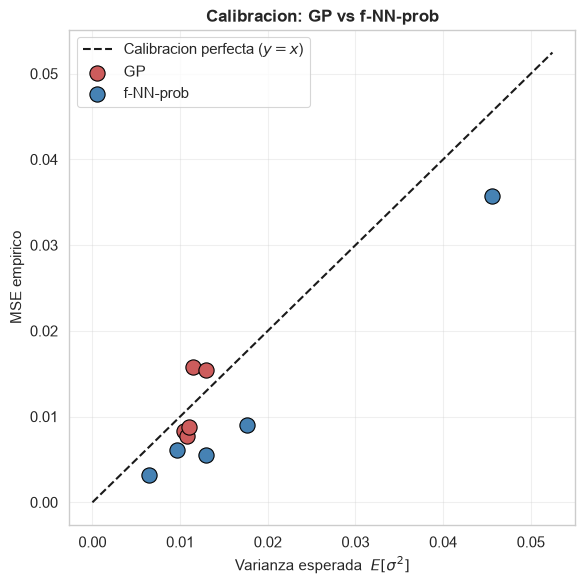

[OK] gp_calibration.json guardado.


In [35]:
# ======================================================================
# CALIBRACION GP: quintiles de sigma^2 vs MSE empirico
# ======================================================================
assert 'sigma_gp' in globals() and 'y_pred_gp' in globals(), \
    "Ejecuta primero la celda del GP (define sigma_gp y y_pred_gp)"

# sigma_gp es desviacion estandar -> varianza; promedio por muestra sobre 7 dims
sigma2_gp_mean = np.mean(sigma_gp ** 2, axis=1)                 # [N_test]
mse_gp_sample = np.mean((y_test - y_pred_gp) ** 2, axis=1)      # [N_test]

n_bins = 5
edges = np.percentile(sigma2_gp_mean, np.linspace(0, 100, n_bins + 1))
edges[-1] += 1e-6

exp_var_gp, emp_mse_gp, counts_gp = [], [], []
for i in range(n_bins):
    m = (sigma2_gp_mean >= edges[i]) & (sigma2_gp_mean < edges[i + 1])
    if m.sum() == 0:
        continue
    counts_gp.append(int(m.sum()))
    exp_var_gp.append(float(np.mean(sigma2_gp_mean[m])))
    emp_mse_gp.append(float(np.mean(mse_gp_sample[m])))

ece_gp = float(np.average(np.abs(np.array(emp_mse_gp) - np.array(exp_var_gp)),
                          weights=counts_gp))

print("=" * 62)
print("CALIBRACION GP (quintiles de sigma^2 predicho)")
print("=" * 62)
print(f"{'Quintil':<9} {'n':>6} {'E[sigma^2]':>13} {'MSE empirico':>13} {'Ratio':>8}")
print("-" * 62)
for q, (n, ev, em) in enumerate(zip(counts_gp, exp_var_gp, emp_mse_gp), 1):
    print(f"{q:<9} {n:>6} {ev:>13.6f} {em:>13.6f} {em/ev:>8.3f}")
print("-" * 62)
print(f"ECE GP: {ece_gp:.6f}")
if 'expected_var' in globals():
    ece_prob = float(np.average(np.abs(np.array(empirical_mse) - np.array(expected_var)),
                                weights=counts))
    print(f"ECE f-NN-prob (referencia): {ece_prob:.6f}")

# --- Figura: GP vs f-NN-prob en el mismo diagrama ---
fig, ax = plt.subplots(figsize=(6, 6))
vals = exp_var_gp + emp_mse_gp
if 'expected_var' in globals():
    vals += expected_var + empirical_mse
max_val = max(vals) * 1.15
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.5,
        label='Calibracion perfecta ($y=x$)')
ax.scatter(exp_var_gp, emp_mse_gp, s=120, c='indianred', edgecolors='black',
           zorder=5, label='GP')
if 'expected_var' in globals():
    ax.scatter(expected_var, empirical_mse, s=120, c='steelblue',
               edgecolors='black', zorder=5, label='f-NN-prob')
ax.set_xlabel(r'Varianza esperada  $E[\sigma^2]$', fontsize=11)
ax.set_ylabel('MSE empirico', fontsize=11)
ax.set_title('Calibracion: GP vs f-NN-prob', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figuras/gp_calibration.png", dpi=300, bbox_inches='tight')
plt.show()

with open("jsones/gp_calibration.json", "w") as f:
    json.dump({"counts": counts_gp, "expected_var": exp_var_gp,
               "empirical_mse": emp_mse_gp, "ece": ece_gp}, f, indent=2)
print("[OK] gp_calibration.json guardado.")

## Recalibración: temperature scaling de la varianza

La f-NN-prob es sistemáticamente conservadora (ratios MSE/$\mathbb{E}[\sigma^2] \approx 0{,}5$).
Adaptamos el *temperature scaling* a regresión: un factor global $s$ que reescala la
varianza predicha, $\sigma^2_{\text{cal}} = s \cdot \sigma^2$, ajustado en un conjunto de
validación minimizando la NLL gaussiana.

**Derivación de la solución cerrada.** La NLL como función de $s$ es
$\text{NLL}(s) = \tfrac{1}{2}\log(s\,\sigma_i^2) + \tfrac{(y_i-\mu_i)^2}{2\,s\,\sigma_i^2}$
(promediada sobre validación). Derivando e igualando a cero:

$$\frac{\partial \text{NLL}}{\partial s} = \frac{1}{2s} - \frac{1}{2s^2}\,\overline{\frac{(y-\mu)^2}{\sigma^2}} = 0
\;\Rightarrow\; s^* = \overline{\frac{(y-\mu)^2}{\sigma^2}}$$

El factor óptimo es el ratio promedio entre error real y varianza declarada.

**Expectativa:** $s^* \approx 0{,}5$ a $0{,}6$ (deshinchar la varianza), ECE de la
f-NN-prob calibrada por debajo del GP, media $\mu$ intacta ($R^2$ no cambia).

Factor de temperatura optimo: s* = 0.3900
RECALIBRACION f-NN-prob (temperature scaling)
Metrica                       Antes      Despues
------------------------------------------------------------
ECE                        0.006555     0.004709
NLL test                    -7.8973      -8.5983

Referencia ECE GP: 0.002842

La media mu no cambia: el R2 es identico antes y despues.


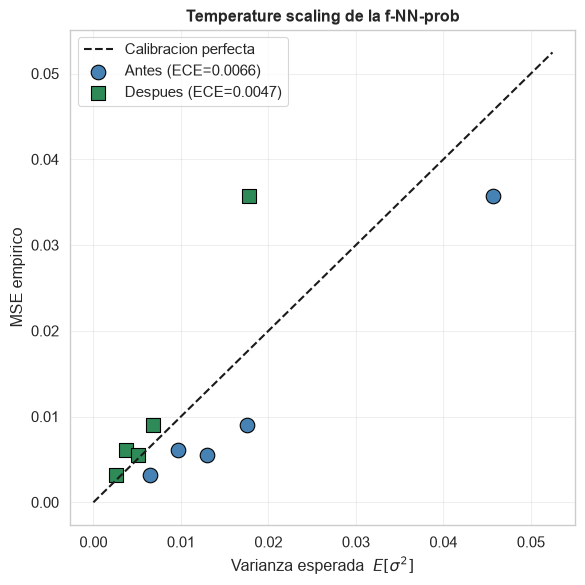

[OK] temperature_scaling.json guardado.


In [36]:
# ======================================================================
# TEMPERATURE SCALING: ajuste en validacion, evaluacion en test
# ======================================================================
assert 'f_nn_prob' in globals(), "Ejecuta primero la seccion f-NN Probabilistica"

# Split interno de validacion (mismo protocolo que la MDN, test intacto)
perm_ts = np.random.RandomState(300).permutation(len(y_train))
idx_val_ts = perm_ts[:int(0.1 * len(y_train))]
X_val_ts = torch.tensor(X_train[idx_val_ts], dtype=torch.float32).to(device)
y_val_ts = y_train[idx_val_ts]

f_nn_prob.eval()
with torch.no_grad():
    mu_v, lv_v = f_nn_prob(X_val_ts)
mu_v = mu_v.cpu().numpy(); var_v = np.exp(lv_v.cpu().numpy())

# Solucion cerrada: s* = promedio de (error^2 / varianza) en validacion
s_star = float(np.mean((y_val_ts - mu_v) ** 2 / var_v))
print(f"Factor de temperatura optimo: s* = {s_star:.4f}")

# Aplicar a test
with torch.no_grad():
    mu_t, lv_t = f_nn_prob(torch.tensor(X_test, dtype=torch.float32).to(device))
mu_t = mu_t.cpu().numpy(); var_t = np.exp(lv_t.cpu().numpy())

def ece_regresion(var_matrix, mu_matrix, y_true, n_bins=5):
    """ECE de segundo momento por quintiles de varianza promedio."""
    s2 = var_matrix.mean(axis=1)
    mse_s = np.mean((y_true - mu_matrix) ** 2, axis=1)
    edges = np.percentile(s2, np.linspace(0, 100, n_bins + 1)); edges[-1] += 1e-9
    evs, ems, ns = [], [], []
    for i in range(n_bins):
        m = (s2 >= edges[i]) & (s2 < edges[i + 1])
        if m.sum() == 0: continue
        ns.append(m.sum()); evs.append(s2[m].mean()); ems.append(mse_s[m].mean())
    ece = float(np.average(np.abs(np.array(ems) - np.array(evs)), weights=ns))
    return ece, evs, ems, ns

ece_antes, ev_a, em_a, _ = ece_regresion(var_t, mu_t, y_test)
ece_despues, ev_d, em_d, _ = ece_regresion(s_star * var_t, mu_t, y_test)

# NLL antes/despues en test (por muestra, sumada sobre dimensiones)
def nll_gauss(var, mu, y):
    return float(np.mean(np.sum(0.5 * np.log(2 * np.pi * var)
                                + (y - mu) ** 2 / (2 * var), axis=1)))
nll_antes = nll_gauss(var_t, mu_t, y_test)
nll_despues = nll_gauss(s_star * var_t, mu_t, y_test)

print("=" * 60)
print("RECALIBRACION f-NN-prob (temperature scaling)")
print("=" * 60)
print(f"{'Metrica':<22} {'Antes':>12} {'Despues':>12}")
print("-" * 60)
print(f"{'ECE':<22} {ece_antes:>12.6f} {ece_despues:>12.6f}")
print(f"{'NLL test':<22} {nll_antes:>12.4f} {nll_despues:>12.4f}")
if 'ece_gp' in globals():
    print(f"\nReferencia ECE GP: {ece_gp:.6f}")
print(f"\nLa media mu no cambia: el R2 es identico antes y despues.")

# Diagrama antes/despues
fig, ax = plt.subplots(figsize=(6, 6))
mx = max(ev_a + em_a) * 1.15
ax.plot([0, mx], [0, mx], 'k--', linewidth=1.5, label='Calibracion perfecta')
ax.scatter(ev_a, em_a, s=110, c='steelblue', edgecolors='black',
           label=f'Antes (ECE={ece_antes:.4f})')
ax.scatter(ev_d, em_d, s=110, c='seagreen', marker='s', edgecolors='black',
           label=f'Despues (ECE={ece_despues:.4f})')
ax.set_xlabel(r'Varianza esperada  $E[\sigma^2]$')
ax.set_ylabel('MSE empirico')
ax.set_title('Temperature scaling de la f-NN-prob', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figuras/temperature_scaling.png", dpi=300, bbox_inches='tight')
plt.show()

with open("jsones/temperature_scaling.json", "w") as f:
    json.dump({"s_star": s_star, "ece_antes": ece_antes, "ece_despues": ece_despues,
               "nll_antes": nll_antes, "nll_despues": nll_despues}, f, indent=2)
print("[OK] temperature_scaling.json guardado.")

## Importancia de variables: permutación vs ARD

Se comparan dos métodos independientes para medir qué parámetros de diseño
determinan las propiedades geométricas:

1. **Permutación sobre la f-NN:** se permuta cada columna de entrada en test
   y se mide la caída de $R^2$. Caída grande = variable importante.
2. **ARD del GP (Automatic Relevance Determination):** el kernel RBF con una
   longitud de escala por dimensión ya fue optimizado; una longitud grande
   significa que la salida varía poco con esa entrada (variable irrelevante).
   Importancia $\propto 1/\ell_j$.

**Expectativa:** $\rho$ y $\beta$ dominan; los ángulos casi no influyen en $G$.
Si se confirma, cierra el argumento del proyecto: la baja importancia de los
ángulos en el mapeo directo es la causa de su no identificabilidad en el inverso.

IMPORTANCIA DE VARIABLES (normalizada, suma 1)
Parametro      Permutacion f-NN     ARD GP (1/l)
------------------------------------------------------------------
Beta                      0.390            0.371
Rho                       0.604            0.336
Aniso_X                   0.003            0.143
Aniso_Y                   0.001            0.100
Aniso_Z                   0.001            0.051
------------------------------------------------------------------
R2 base de referencia (sin permutar): 0.9867

Longitudes de escala ARD por propiedad (l grande = irrelevante):
Propiedad           Beta       Rho   Aniso_X   Aniso_Y   Aniso_Z
----------------------------------------------------------------
Area_Inner         10.00      3.10      2.07      6.75     10.00
Area_Outer          0.34      4.19      7.58      3.90      2.76
Total_Area          0.48      2.53      4.55      5.01     10.00
Volume              2.84      4.22      2.24      2.20      9.51
SA_Vol_Ratio        2.87

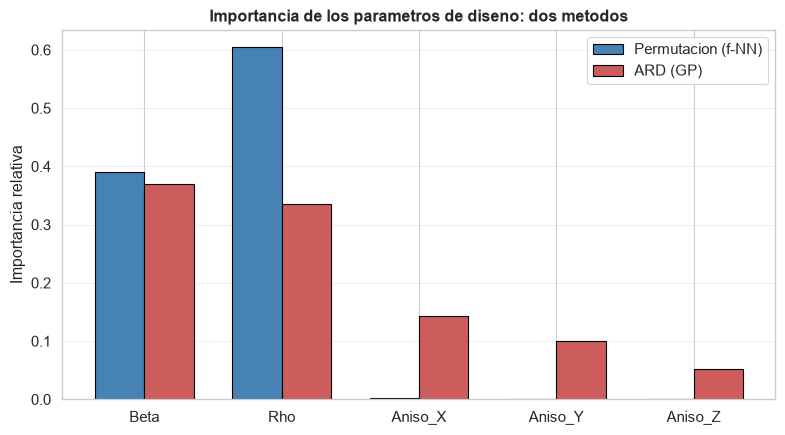

[OK] variable_importance.json guardado.


In [37]:
# ======================================================================
# IMPORTANCIA DE VARIABLES: permutacion (f-NN) y ARD (GP)
# ======================================================================
# --- Metodo 1: permutacion sobre la f-NN ---
f_nn.eval()
X_test_t_imp = torch.tensor(X_test, dtype=torch.float32).to(device)
with torch.no_grad():
    r2_base = r2_score(y_test, f_nn(X_test_t_imp).cpu().numpy())

N_REP = 10
rng_imp = np.random.RandomState(0)
imp_perm = np.zeros(len(theta_cols))
for j in range(len(theta_cols)):
    caidas = []
    for _ in range(N_REP):
        Xp = X_test.copy()
        Xp[:, j] = Xp[rng_imp.permutation(len(Xp)), j]
        with torch.no_grad():
            r2p = r2_score(y_test, f_nn(torch.tensor(Xp, dtype=torch.float32)
                                        .to(device)).cpu().numpy())
        caidas.append(r2_base - r2p)
    imp_perm[j] = np.mean(caidas)

# --- Metodo 2: ARD del GP (longitudes de escala inversas) ---
def extraer_rbf(kernel):
    """Busca recursivamente el componente RBF en el arbol del kernel."""
    if isinstance(kernel, RBF):
        return kernel
    for attr in ('k1', 'k2'):
        if hasattr(kernel, attr):
            r = extraer_rbf(getattr(kernel, attr))
            if r is not None:
                return r
    return None

imp_ard = None
if 'gp_models' in globals() and len(gp_models) == len(G_cols):
    ls_matrix = np.array([extraer_rbf(gp.kernel_).length_scale for gp in gp_models])
    # Importancia por parametro: promedio de 1/l sobre las 7 propiedades, normalizado
    inv_ls = 1.0 / ls_matrix                    # [7 propiedades, 5 parametros]
    imp_ard = inv_ls.mean(axis=0)
    imp_ard = imp_ard / imp_ard.sum()

imp_perm_n = imp_perm / imp_perm.sum()

print("=" * 66)
print("IMPORTANCIA DE VARIABLES (normalizada, suma 1)")
print("=" * 66)
print(f"{'Parametro':<12} {'Permutacion f-NN':>18} {'ARD GP (1/l)':>16}")
print("-" * 66)
for j, col in enumerate(theta_cols):
    ard_s = f"{imp_ard[j]:.3f}" if imp_ard is not None else "-"
    print(f"{col:<12} {imp_perm_n[j]:>18.3f} {ard_s:>16}")
print("-" * 66)
print(f"R2 base de referencia (sin permutar): {r2_base:.4f}")

if imp_ard is not None:
    # Longitudes de escala por propiedad (tabla ampliada, interpretable)
    print("\nLongitudes de escala ARD por propiedad (l grande = irrelevante):")
    header = f"{'Propiedad':<14}" + "".join(f"{c:>10}" for c in theta_cols)
    print(header); print("-" * len(header))
    for i, prop in enumerate(G_cols):
        print(f"{prop:<14}" + "".join(f"{ls_matrix[i, j]:>10.2f}"
                                      for j in range(len(theta_cols))))

# --- Figura comparativa ---
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(theta_cols)); w = 0.36
ax.bar(x - w/2, imp_perm_n, w, label='Permutacion (f-NN)',
       color='steelblue', edgecolor='black')
if imp_ard is not None:
    ax.bar(x + w/2, imp_ard, w, label='ARD (GP)',
           color='indianred', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(theta_cols)
ax.set_ylabel('Importancia relativa')
ax.set_title('Importancia de los parametros de diseno: dos metodos',
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("figuras/variable_importance.png", dpi=300, bbox_inches='tight')
plt.show()

with open("jsones/variable_importance.json", "w") as f:
    json.dump({"permutacion": imp_perm_n.tolist(),
               "ard": imp_ard.tolist() if imp_ard is not None else None,
               "r2_base": float(r2_base),
               "parametros": theta_cols}, f, indent=2)
print("[OK] variable_importance.json guardado.")

## GP: comparación de kernels (RBF vs Matérn)

El kernel define el supuesto de suavidad del GP. Se comparan RBF
(infinitamente suave) y Matérn $\nu = 2{,}5$ (dos veces diferenciable) sobre
dos propiedades representativas: la más fácil (área interna) y la más difícil
(tamaño de poro). Criterio de selección: **log-verosimilitud marginal (LML)**,
que balancea ajuste y complejidad de forma bayesiana, más $R^2$ en test.

**Expectativa:** en la propiedad suave ambos kernels empatan; en tamaño de
poro (más estructura fina) Matérn podría ganar por su menor rigidez.

In [38]:
# ======================================================================
# KERNELS RBF vs MATERN sobre dos propiedades representativas
# ======================================================================
from sklearn.gaussian_process.kernels import Matern

PROPS_KER = [0, 6]   # Area_Inner (facil) y Pore_Size (dificil)

# Subconjunto de entrenamiento (mismo criterio que la seccion GP)
if 'X_train_gp' not in globals():
    rng_k = np.random.RandomState(0)
    idx_k = rng_k.choice(len(X_train), size=min(2240, len(X_train)), replace=False)
    X_train_gp = X_train[idx_k]; y_train_gp = y_train[idx_k]

resultados_ker = []
for j in PROPS_KER:
    for nombre, nucleo in [
        ("RBF", ConstantKernel(1.0, (1e-3, 1e3))
                * RBF(length_scale=[1.0]*5, length_scale_bounds=(1e-2, 1e2))
                + WhiteKernel(1.0, (1e-5, 1e1))),
        ("Matern 2.5", ConstantKernel(1.0, (1e-3, 1e3))
                * Matern(length_scale=[1.0]*5, length_scale_bounds=(1e-2, 1e2), nu=2.5)
                + WhiteKernel(1.0, (1e-5, 1e1))),
    ]:
        t0 = time.time()
        gp_k = GaussianProcessRegressor(kernel=nucleo, normalize_y=True,
                                        n_restarts_optimizer=1, random_state=0)
        gp_k.fit(X_train_gp, y_train_gp[:, j])
        lml = gp_k.log_marginal_likelihood_value_
        r2_k = r2_score(y_test[:, j], gp_k.predict(X_test))
        dt = time.time() - t0
        resultados_ker.append({"propiedad": G_cols[j], "kernel": nombre,
                               "lml": float(lml), "r2_test": float(r2_k),
                               "tiempo_s": float(dt)})
        print(f"{G_cols[j]:<14} | {nombre:<11} | LML = {lml:>10.1f} | "
              f"R2 test = {r2_k:.4f} | {dt:.0f} s")

print("\nCriterio: mayor LML = kernel mas plausible dados los datos.")

with open("jsones/kernel_comparison.json", "w") as f:
    json.dump(resultados_ker, f, indent=2)
print("[OK] kernel_comparison.json guardado.")

Area_Inner     | RBF         | LML =     4645.3 | R2 test = 0.9991 | 78 s
Area_Inner     | Matern 2.5  | LML =     4719.9 | R2 test = 0.9992 | 76 s


c:\Users\vague\anaconda3\envs\miniproyecto\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Pore_Size      | RBF         | LML =     -236.2 | R2 test = 0.9364 | 83 s
Pore_Size      | Matern 2.5  | LML =     -180.7 | R2 test = 0.9472 | 113 s

Criterio: mayor LML = kernel mas plausible dados los datos.
[OK] kernel_comparison.json guardado.


## Cobertura de intervalos de predicción (PICP)

La calibración de segundo momento verifica varianzas; la **cobertura empírica**
verifica intervalos: si el modelo declara un intervalo del $95\%$
($\mu \pm 1{,}96\,\sigma$), el valor real debe caer dentro el $95\%$ de las veces.

- **PICP** (Prediction Interval Coverage Probability): fracción de valores reales
  dentro del intervalo. Debe acercarse al nivel nominal.
- **MPIW** (Mean Prediction Interval Width): ancho medio del intervalo. Entre dos
  modelos con la misma cobertura, gana el de intervalos más angostos.

**Expectativa:** la f-NN-prob sin calibrar sobre-cubre (declara intervalos más
anchos de lo necesario); tras el temperature scaling la cobertura debe acercarse
al nominal con intervalos más angostos.

In [39]:
# ======================================================================
# PICP / MPIW para f-NN-prob cruda, calibrada y GP (espacio normalizado)
# ======================================================================
assert 'mu_t' in globals() and 's_star' in globals(), \
    "Ejecuta primero la celda de temperature scaling"

NIVELES = [(0.68, 1.0), (0.95, 1.96)]   # (nivel nominal, z)

def picp_mpiw(mu, var, y, z):
    sd = np.sqrt(var)
    dentro = np.abs(y - mu) <= z * sd
    return float(dentro.mean()), float((2 * z * sd).mean())

modelos_cov = [("f-NN-prob cruda", mu_t, var_t),
               ("f-NN-prob calibrada", mu_t, s_star * var_t)]
if 'y_pred_gp' in globals() and 'sigma_gp' in globals():
    modelos_cov.append(("GP", y_pred_gp, sigma_gp ** 2))

print("=" * 72)
print("COBERTURA DE INTERVALOS DE PREDICCION")
print("=" * 72)
print(f"{'Modelo':<22} {'Nominal':>8} {'PICP':>8} {'MPIW':>8}")
print("-" * 72)
resultados_cov = []
for nombre, mu_, var_ in modelos_cov:
    for nivel, z in NIVELES:
        picp, mpiw = picp_mpiw(mu_, var_, y_test, z)
        print(f"{nombre:<22} {nivel:>7.0%} {picp:>8.3f} {mpiw:>8.3f}")
        resultados_cov.append({"modelo": nombre, "nominal": nivel,
                               "picp": picp, "mpiw": mpiw})
    print("-" * 72)
print("Lectura: PICP cercano al nominal = intervalos honestos;")
print("con igual cobertura, MPIW menor = intervalos mas informativos.")

with open("jsones/interval_coverage.json", "w") as f:
    json.dump(resultados_cov, f, indent=2)
print("\n[OK] interval_coverage.json guardado.")

COBERTURA DE INTERVALOS DE PREDICCION
Modelo                  Nominal     PICP     MPIW
------------------------------------------------------------------------
f-NN-prob cruda            68%    0.876    0.226
f-NN-prob cruda            95%    0.991    0.442
------------------------------------------------------------------------
f-NN-prob calibrada        68%    0.677    0.141
f-NN-prob calibrada        95%    0.932    0.276
------------------------------------------------------------------------
GP                         68%    0.739    0.162
GP                         95%    0.943    0.317
------------------------------------------------------------------------
Lectura: PICP cercano al nominal = intervalos honestos;
con igual cobertura, MPIW menor = intervalos mas informativos.

[OK] interval_coverage.json guardado.


## Extrapolación fuera del dominio de entrenamiento

Un surrogate solo es confiable dentro del rango donde vio datos. Este experimento
barre un parámetro más allá de su rango de entrenamiento (con los demás fijos al
centro del dominio) y observa cómo responde la **incertidumbre declarada** de cada
modelo probabilístico.

**Expectativa:** la varianza posterior del GP crece automáticamente al abandonar
la región con datos (es su propiedad constitutiva); la f-NN-prob no tiene ese
mecanismo y puede extrapolar con confianza indebida. El mensaje práctico: solo
el GP avisa cuándo se está fuera del dominio de validez.

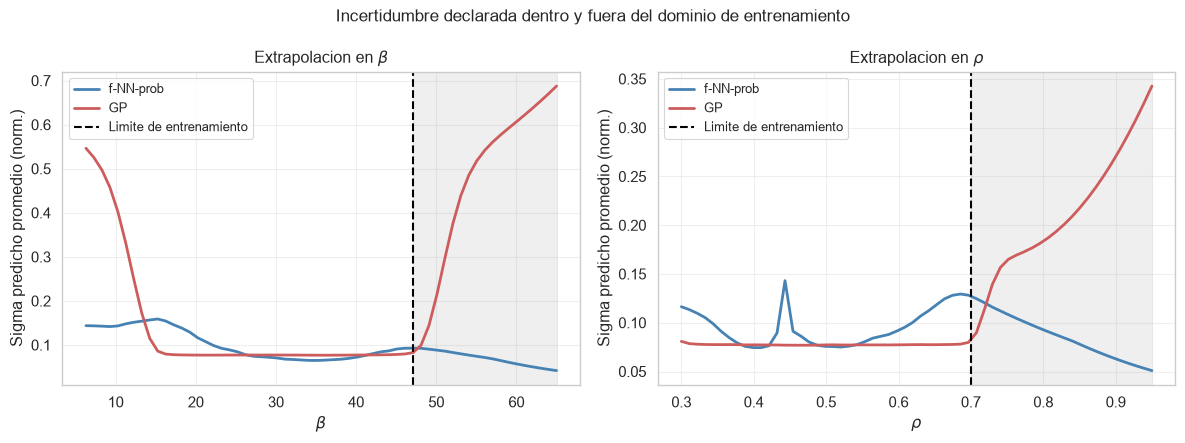

[beta] f-NN-prob: sigma dentro=0.102 fuera=0.068 (x0.67)
[beta] GP:        sigma dentro=0.140 fuera=0.485 (x3.47)
[rho] f-NN-prob: sigma dentro=0.095 fuera=0.085 (x0.89)
[rho] GP:        sigma dentro=0.078 fuera=0.213 (x2.75)


In [40]:
# ======================================================================
# EXTRAPOLACION: sigma predicho al salir del rango de entrenamiento
# ======================================================================
# Rangos fisicos de entrenamiento (autocontenidos en esta celda)
BETA_MAX_TRAIN, RHO_MAX_TRAIN = 47.12, 0.7

def sigma_promedio(thetas_fisico):
    """Devuelve (sigma_fnnprob, sigma_gp) promedio sobre las 7 salidas."""
    Xn = scaler_X.transform(thetas_fisico)
    Xt = torch.tensor(Xn, dtype=torch.float32).to(device)
    f_nn_prob.eval()
    with torch.no_grad():
        _, lv = f_nn_prob(Xt)
    sd_net = np.exp(0.5 * lv.cpu().numpy()).mean(axis=1)
    sd_gp_ = None
    if 'gp_models' in globals():
        sds = np.zeros((len(Xn), len(G_cols)))
        for j, gp_j in enumerate(gp_models):
            _, s = gp_j.predict(Xn, return_std=True)
            sds[:, j] = s
        sd_gp_ = sds.mean(axis=1)
    return sd_net, sd_gp_

# Barrido en beta (entrenado hasta 47.12, extrapolamos hasta 65)
grid_b = np.linspace(6.3, 65.0, 60)
Tb = np.column_stack([grid_b, np.full(60, 0.5),
                      np.full(60, 45.0), np.full(60, 45.0), np.full(60, 45.0)])
sd_net_b, sd_gp_b = sigma_promedio(Tb)

# Barrido en rho (entrenado hasta 0.7, extrapolamos hasta 0.95)
grid_r = np.linspace(0.30, 0.95, 60)
Tr = np.column_stack([np.full(60, 26.7), grid_r,
                      np.full(60, 45.0), np.full(60, 45.0), np.full(60, 45.0)])
sd_net_r, sd_gp_r = sigma_promedio(Tr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, grid, sn, sg, lim, nombre in [
        (axes[0], grid_b, sd_net_b, sd_gp_b, BETA_MAX_TRAIN, r'$\beta$'),
        (axes[1], grid_r, sd_net_r, sd_gp_r, RHO_MAX_TRAIN, r'$\rho$')]:
    ax.plot(grid, sn, label='f-NN-prob', color='steelblue', linewidth=2)
    if sg is not None:
        ax.plot(grid, sg, label='GP', color='indianred', linewidth=2)
    ax.axvline(lim, color='black', linestyle='--', linewidth=1.5,
               label='Limite de entrenamiento')
    ax.axvspan(lim, grid[-1], alpha=0.12, color='gray')
    ax.set_xlabel(nombre); ax.set_ylabel('Sigma predicho promedio (norm.)')
    ax.set_title(f'Extrapolacion en {nombre}')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Incertidumbre declarada dentro y fuera del dominio de entrenamiento',
             fontsize=12)
plt.tight_layout()
plt.savefig("figuras/extrapolation.png", dpi=300, bbox_inches='tight')
plt.show()

# Cuantificar: sigma promedio dentro vs fuera
for nombre, grid, sn, sg, lim in [("beta", grid_b, sd_net_b, sd_gp_b, BETA_MAX_TRAIN),
                                   ("rho", grid_r, sd_net_r, sd_gp_r, RHO_MAX_TRAIN)]:
    dentro = grid <= lim; fuera = ~dentro
    print(f"[{nombre}] f-NN-prob: sigma dentro={sn[dentro].mean():.3f} "
          f"fuera={sn[fuera].mean():.3f} (x{sn[fuera].mean()/sn[dentro].mean():.2f})")
    if sg is not None:
        print(f"[{nombre}] GP:        sigma dentro={sg[dentro].mean():.3f} "
              f"fuera={sg[fuera].mean():.3f} (x{sg[fuera].mean()/sg[dentro].mean():.2f})")

## Costo computacional: speedup del surrogate

La motivación del proyecto es reemplazar una simulación costosa. Aquí se
cuantifica la ganancia: tiempo de la simulación física (27 geometrías/hora con
7 hilos, medido durante la generación del dataset) contra el tiempo de
inferencia de cada surrogate.

In [41]:
# ======================================================================
# SPEEDUP: simulacion fisica vs surrogates
# ======================================================================
T_SIM = 3600.0 / 27.0     # segundos por geometria (medido en la generacion)

X_all = torch.tensor(X_test, dtype=torch.float32).to(device)
n = len(X_test)

# f-NN: mediana de 50 pasadas completas
f_nn.eval()
tiempos = []
with torch.no_grad():
    for _ in range(50):
        t0 = time.time(); f_nn(X_all); tiempos.append(time.time() - t0)
t_fnn = np.median(tiempos) / n

# f-NN-prob
f_nn_prob.eval()
tiempos = []
with torch.no_grad():
    for _ in range(50):
        t0 = time.time(); f_nn_prob(X_all); tiempos.append(time.time() - t0)
t_prob = np.median(tiempos) / n

# GP (una pasada por propiedad; es el mas lento de los tres)
t_gp = None
if 'gp_models' in globals():
    t0 = time.time()
    for gp_j in gp_models:
        gp_j.predict(X_test)
    t_gp = (time.time() - t0) / n

print("=" * 66)
print("COSTO POR MUESTRA Y SPEEDUP FRENTE A LA SIMULACION")
print("=" * 66)
print(f"{'Metodo':<16} {'t por muestra':>16} {'Speedup':>14}")
print("-" * 66)
print(f"{'Simulacion':<16} {T_SIM:>13.1f} s  {'1x':>14}")
print(f"{'f-NN':<16} {t_fnn*1e6:>11.1f} us  {T_SIM/t_fnn:>13.0f}x")
print(f"{'f-NN-prob':<16} {t_prob*1e6:>11.1f} us  {T_SIM/t_prob:>13.0f}x")
if t_gp is not None:
    print(f"{'GP (7 salidas)':<16} {t_gp*1e3:>11.2f} ms  {T_SIM/t_gp:>13.0f}x")
print("-" * 66)
print("Contexto: el barrido Monte Carlo de 10^4 evaluaciones que sustenta el")
print(f"diagnostico de no-unicidad tomaria {1e4*T_SIM/3600/24:.0f} dias con la")
print(f"simulacion; con la f-NN toma {1e4*t_fnn:.2f} segundos.")

with open("jsones/speedup.json", "w") as f:
    json.dump({"t_sim_s": T_SIM, "t_fnn_s": float(t_fnn),
               "t_fnnprob_s": float(t_prob),
               "t_gp_s": float(t_gp) if t_gp else None,
               "speedup_fnn": float(T_SIM/t_fnn)}, f, indent=2)
print("\n[OK] speedup.json guardado.")

COSTO POR MUESTRA Y SPEEDUP FRENTE A LA SIMULACION
Metodo              t por muestra        Speedup
------------------------------------------------------------------
Simulacion               133.3 s              1x
f-NN                     3.1 us       42399742x
f-NN-prob                3.7 us       35685780x
GP (7 salidas)          0.36 ms         367377x
------------------------------------------------------------------
Contexto: el barrido Monte Carlo de 10^4 evaluaciones que sustenta el
diagnostico de no-unicidad tomaria 15 dias con la
simulacion; con la f-NN toma 0.03 segundos.

[OK] speedup.json guardado.


# Diagnóstico de multimodalidad (Pilar 3)

El mapeo inverso $G \mapsto \Theta$ no es único: varios $\Theta$ producen el mismo $G$. Minimizar MSE sobre una i-NN única produce el promedio de modos, que para los ángulos no pertenece a su soporte (de ahí el $R^2 < 0$ observado).

Dos diagnósticos:
1. **Ensemble de i-NN:** entrenamos $N$ redes con distintas semillas; la dispersión aproxima $p(\Theta \mid G)$.
2. **Monte Carlo:** muestreamos $\sim 10^4$ valores de $\Theta$, filtramos los compatibles con $G^*$ vía la f-NN congelada.

### Configuración

In [42]:
# --- Configuracion ---
N_ENSEMBLE = 10          # Reducir a 5 si es muy lento
N_MC_SAMPLES = 10000
EPSILON_MC = 0.5         # Umbral MSE normalizado para "compatible"
IDX_SAMPLE = 0           # Muestra de test a analizar

# Rangos de los parametros de diseno (para muestreo MC)
THETA_BOUNDS = {
    'Beta': (2 * np.pi, 15 * np.pi),
    'Rho': (0.3, 0.7),
    'Aniso_X': (0, 89.9),
    'Aniso_Y': (0, 89.9),
    'Aniso_Z': (0, 89.9),
}

# Hiperparametros i-NN (mismos del avance)
INV_HIDDEN = [128, 128, 64]
INV_DROPOUT = 0.1
INV_LR = 1e-3
INV_WD = 1e-5
INV_BATCH = 64
INV_EPOCHS = 200
INV_PATIENCE = 30

# Asegurar que f_nn esta congelada y en evaluacion
f_nn.eval()
for p in f_nn.parameters():
    p.requires_grad = False

### Ensemble de i-NN

ENTRENANDO ENSEMBLE DE 10 i-NN
  Red 1/10... OK
  Red 2/10... OK
  Red 3/10... OK
  Red 4/10... OK
  Red 5/10... OK
  Red 6/10... OK
  Red 7/10... OK
  Red 8/10... OK
  Red 9/10... OK
  Red 10/10... OK

--- Resultados del ensemble (muestra test #0) ---
Theta verdadero: {'Beta': np.float64(33.6858), 'Rho': np.float64(0.5169), 'Aniso_X': np.float64(60.18), 'Aniso_Y': np.float64(20.49), 'Aniso_Z': np.float64(50.47)}

Predicciones del ensemble (espacio original):
  Red 1: {'Beta': np.float32(34.262207), 'Rho': np.float32(0.5108395), 'Aniso_X': np.float32(15.408819), 'Aniso_Y': np.float32(9.680183), 'Aniso_Z': np.float32(58.62155)}
  Red 2: {'Beta': np.float32(34.331474), 'Rho': np.float32(0.513733), 'Aniso_X': np.float32(20.214087), 'Aniso_Y': np.float32(12.752411), 'Aniso_Z': np.float32(55.413082)}
  Red 3: {'Beta': np.float32(34.337288), 'Rho': np.float32(0.51525825), 'Aniso_X': np.float32(18.820808), 'Aniso_Y': np.float32(10.803566), 'Aniso_Z': np.float32(65.817535)}
  Red 4: {'Beta': n

C:\Users\vague\AppData\Local\Temp\ipykernel_14340\1489432769.py:109: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(predictions[:, i], vert=True, patch_artist=True,
C:\Users\vague\AppData\Local\Temp\ipykernel_14340\1489432769.py:109: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(predictions[:, i], vert=True, patch_artist=True,
C:\Users\vague\AppData\Local\Temp\ipykernel_14340\1489432769.py:109: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(predictions[:, i], vert=True, patch_artist=True,
C:\Users\vague\AppData\Local\Temp\ipykernel_14340\1489432769.py:109: MatplotlibDeprecationWarning: vert: bool was depreca

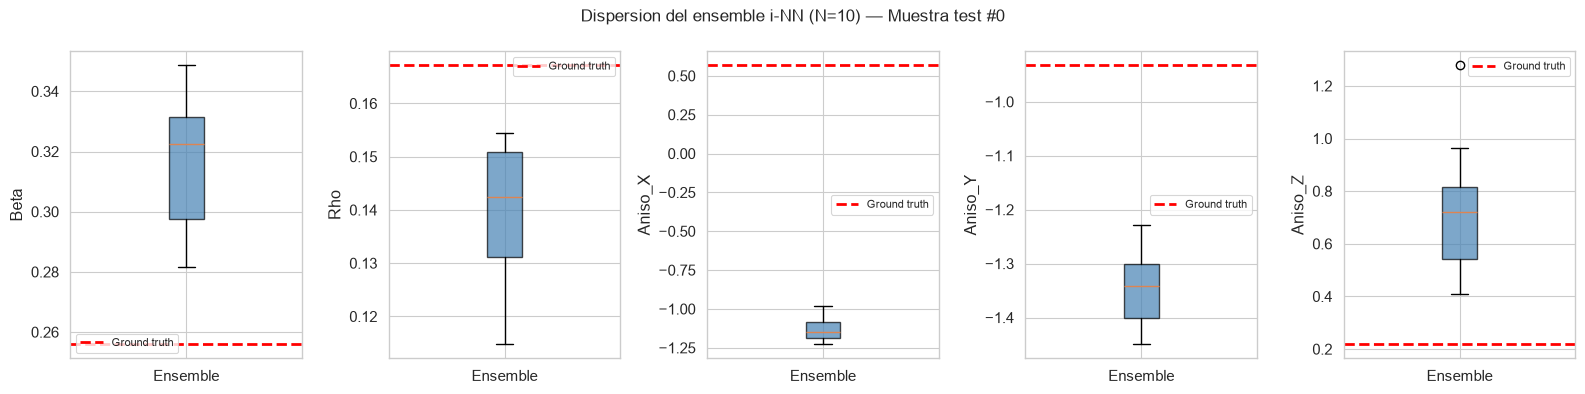

In [43]:
# ======================================================================
# PARTE A: ENSEMBLE DE i-NN
# ======================================================================

def train_single_i_nn(seed):
    """Entrena UNA i-NN desde cero con una semilla dada."""
    torch.manual_seed(seed)

    # Red inversa
    layers = []
    prev = 7
    for h in INV_HIDDEN:
        layers.extend([nn.Linear(prev, h), nn.ReLU(), nn.Dropout(INV_DROPOUT)])
        prev = h
    layers.append(nn.Linear(prev, 5))
    i_net = nn.Sequential(*layers).to(device)

    optimizer = optim.Adam(i_net.parameters(), lr=INV_LR, weight_decay=INV_WD)

    # DataLoader (G -> Theta)
    train_ds = TensorDataset(
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(X_train, dtype=torch.float32)
    )
    train_loader_inv = DataLoader(train_ds, batch_size=INV_BATCH, shuffle=True)

    best_loss = np.inf
    counter = 0
    best_state = None

    for epoch in range(INV_EPOCHS):
        i_net.train()
        epoch_loss = 0
        for batch_G, batch_theta in train_loader_inv:
            batch_G = batch_G.to(device)
            batch_theta = batch_theta.to(device)
            optimizer.zero_grad()

            theta_pred = i_net(batch_G)
            G_recon = f_nn(theta_pred)

            mse_recon = nn.MSELoss()(G_recon, batch_G)
            mse_theta = nn.MSELoss()(theta_pred, batch_theta)
            lam = 0.1 if epoch < 20 else 0.0
            loss = mse_recon + lam * mse_theta

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_loader_inv)

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            counter = 0
            best_state = {k: v.cpu().clone() for k, v in i_net.state_dict().items()}
        else:
            counter += 1
            if counter >= INV_PATIENCE:
                break

    if best_state is not None:
        i_net.load_state_dict(best_state)
    return i_net.cpu().eval()

# Entrenar ensemble
print("=" * 70)
print(f"ENTRENANDO ENSEMBLE DE {N_ENSEMBLE} i-NN")
print("=" * 70)
ensemble_models = []
for i in range(N_ENSEMBLE):
    print(f"  Red {i+1}/{N_ENSEMBLE}...", end=" ")
    model_i = train_single_i_nn(seed=200 + i)
    ensemble_models.append(model_i)
    print("OK")

# Evaluar ensemble en una muestra de test
G_star = torch.tensor(y_test[IDX_SAMPLE:IDX_SAMPLE+1], dtype=torch.float32)
theta_true = X_test[IDX_SAMPLE]

predictions = []
for model_i in ensemble_models:
    with torch.no_grad():
        pred = model_i(G_star).numpy()[0]
    predictions.append(pred)

predictions = np.array(predictions)  # [N_ENSEMBLE, 5]

# Desnormalizar para interpretacion
predictions_orig = scaler_X.inverse_transform(predictions)
theta_true_orig = scaler_X.inverse_transform(theta_true.reshape(1, -1))[0]

print(f"\n--- Resultados del ensemble (muestra test #{IDX_SAMPLE}) ---")
print(f"Theta verdadero: {dict(zip(theta_cols, theta_true_orig))}")
print(f"\nPredicciones del ensemble (espacio original):")
for i, pred in enumerate(predictions_orig):
    print(f"  Red {i+1}: {dict(zip(theta_cols, pred))}")

ensemble_mean = np.mean(predictions, axis=0)
ensemble_std = np.std(predictions, axis=0)
print(f"\nMedia ensemble:  {dict(zip(theta_cols, scaler_X.inverse_transform(ensemble_mean.reshape(1,-1))[0]))}")
# Nota: para llevar una desviacion estandar a escala original se multiplica
# por scaler_X.scale_ (inverse_transform sumaria la media, lo cual es incorrecto)
print(f"Std ensemble:    {dict(zip(theta_cols, ensemble_std * scaler_X.scale_))}")

# --- Figura 1: Boxplot del ensemble ---
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for i, col in enumerate(theta_cols):
    axes[i].boxplot(predictions[:, i], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].axhline(theta_true[i], color='red', linestyle='--', linewidth=2, label='Ground truth')
    axes[i].set_ylabel(col)
    axes[i].set_xticklabels(['Ensemble'])
    axes[i].legend(fontsize=8)
plt.suptitle(f'Dispersion del ensemble i-NN (N={N_ENSEMBLE}) — Muestra test #{IDX_SAMPLE}', fontsize=12)
plt.tight_layout()
plt.savefig("figuras/multimodal_ensemble.png", dpi=300, bbox_inches='tight')
plt.show()


### Diagnóstico Monte Carlo


DIAGNOSTICO MONTE CARLO DE MULTIMODALIDAD
Muestras MC: 10000
Compatibles (MSE < 0.5): 2193 (21.93%)

Estadisticas de Theta compatibles (espacio original):
  Beta: mean=34.595, std=5.215, min=24.389, max=44.734
  Rho: mean=0.529, std=0.057, min=0.402, max=0.646
  Aniso_X: mean=44.505, std=26.074, min=0.010, max=89.891
  Aniso_Y: mean=44.800, std=26.185, min=0.006, max=89.834
  Aniso_Z: mean=44.401, std=26.010, min=0.009, max=89.820


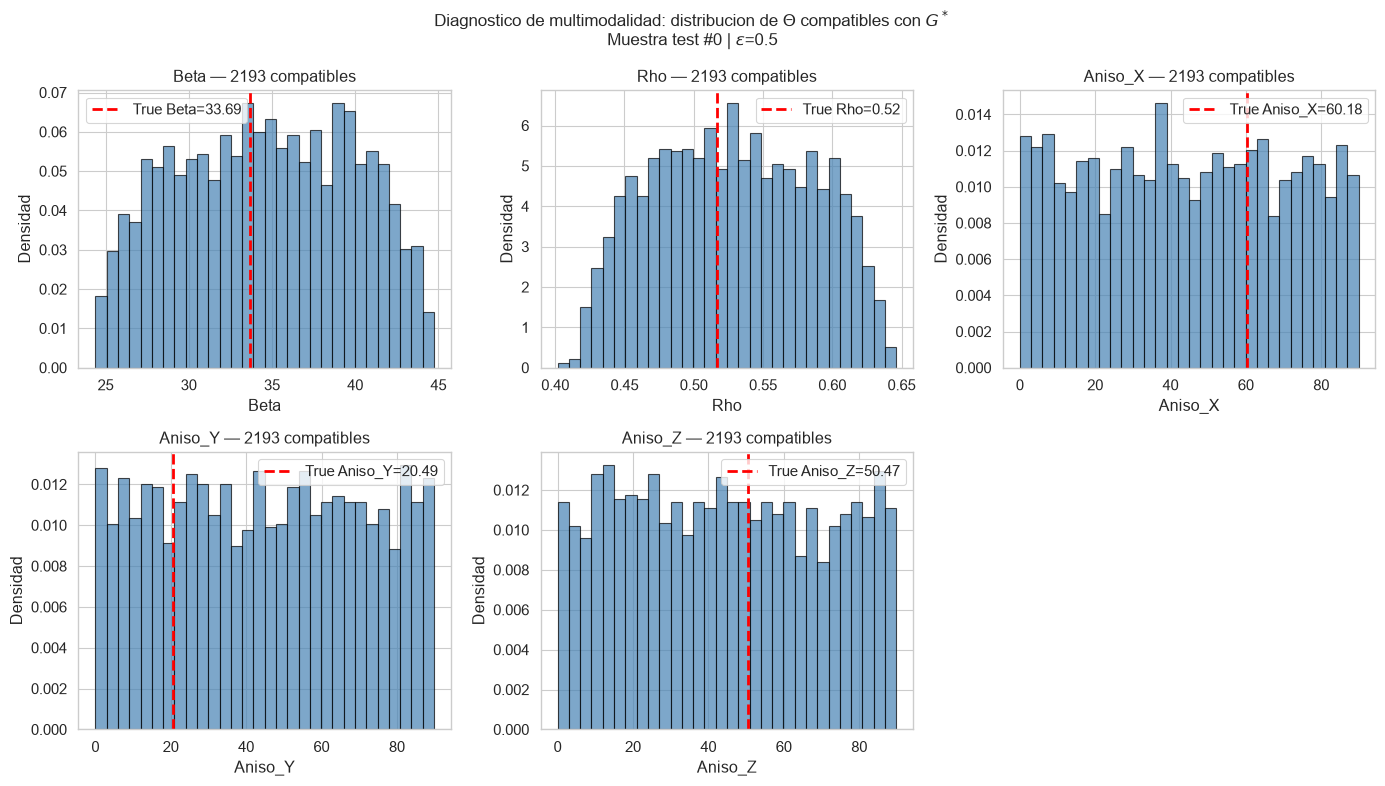

In [44]:
# ======================================================================
# PARTE B: DIAGNOSTICO MONTE CARLO (CORREGIDO)
# ======================================================================
print("\n" + "=" * 70)
print("DIAGNOSTICO MONTE CARLO DE MULTIMODALIDAD")
print("=" * 70)

# G* objetivo (normalizado)
G_star_mc = y_test[IDX_SAMPLE]

# Muestreo uniforme en espacio original
rng = np.random.RandomState(42)
samples_mc = np.zeros((N_MC_SAMPLES, 5))
for i, col in enumerate(theta_cols):
    lo, hi = THETA_BOUNDS[col]
    samples_mc[:, i] = rng.uniform(lo, hi, N_MC_SAMPLES)

# Normalizar para f-NN
samples_mc_norm = scaler_X.transform(samples_mc)
samples_mc_t = torch.tensor(samples_mc_norm, dtype=torch.float32)

# Evaluar f-NN en todas las muestras
f_nn.eval()
with torch.no_grad():
    G_pred_mc = f_nn(samples_mc_t.to(device)).cpu().numpy()

# Error MSE normalizado por dimension
errors_mc = np.mean((G_pred_mc - G_star_mc) ** 2, axis=1)

# Filtrar compatibles
compatible_mask = errors_mc < EPSILON_MC
n_compatible = compatible_mask.sum()

print(f"Muestras MC: {N_MC_SAMPLES}")
print(f"Compatibles (MSE < {EPSILON_MC}): {n_compatible} ({100*n_compatible/N_MC_SAMPLES:.2f}%)")

if n_compatible == 0:
    print("[ADVERTENCIA] Ninguna muestra compatible. Ajusta EPSILON_MC.")
else:
    compatible_theta = samples_mc[compatible_mask]  # Espacio original

    # Estadisticas
    print(f"\nEstadisticas de Theta compatibles (espacio original):")
    for i, col in enumerate(theta_cols):
        vals = compatible_theta[:, i]
        print(f"  {col}: mean={np.mean(vals):.3f}, std={np.std(vals):.3f}, "
              f"min={np.min(vals):.3f}, max={np.max(vals):.3f}")

    # --- Figura 2: Distribucion de parametros compatibles ---
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, col in enumerate(theta_cols):
        ax = axes[i]
        ax.hist(compatible_theta[:, i], bins=30, color='steelblue',
                edgecolor='black', alpha=0.7, density=True)
        ax.axvline(theta_true_orig[i], color='red', linestyle='--', linewidth=2,
                   label=f'True {col}={theta_true_orig[i]:.2f}')
        ax.set_xlabel(col)
        ax.set_ylabel('Densidad')
        ax.set_title(f'{col} — {n_compatible} compatibles')
        ax.legend()

    axes[-1].axis('off')

    # CORRECCION: Usar string normal (no f-string) para evitar doble escape
    title_text = 'Diagnostico de multimodalidad: distribucion de $\\Theta$ compatibles con $G^*$\n'
    title_text += f'Muestra test #{IDX_SAMPLE} | $\\epsilon$={EPSILON_MC}'
    plt.suptitle(title_text, fontsize=12)

    plt.tight_layout()
    plt.savefig("figuras/multimodal_monte_carlo.png", dpi=300, bbox_inches='tight')
    plt.show()

### Reconstrucción desde el ensemble

In [45]:
# ======================================================================
# PARTE C: RECONSTRUCCION DESDE EL ENSEMBLE
# ======================================================================
print("\n" + "=" * 70)
print("RECONSTRUCCION G DESDE EL ENSEMBLE")
print("=" * 70)

# Para cada prediccion del ensemble, pasar por f-NN y ver que tan cerca esta de G*
recon_errors = []
with torch.no_grad():
    for pred in predictions:
        pred_t = torch.tensor(pred, dtype=torch.float32).unsqueeze(0).to(device)
        G_recon = f_nn(pred_t).cpu().numpy()[0]
        err = np.mean((G_recon - G_star_mc) ** 2)
        recon_errors.append(err)

print(f"Error de reconstruccion promedio: {np.mean(recon_errors):.6f} +/- {np.std(recon_errors):.6f}")
print(f"Min: {np.min(recon_errors):.6f} | Max: {np.max(recon_errors):.6f}")
print("\n[OK] El ensemble reconstruye G* consistentemente aunque los Theta sean diferentes.")

# Guardar resultados en JSON
multimodal_results = {
    'ensemble': {
        'n_models': N_ENSEMBLE,
        'sample_idx': IDX_SAMPLE,
        'predictions_norm': predictions.tolist(),
        'predictions_orig': predictions_orig.tolist(),
        'ground_truth_orig': theta_true_orig.tolist(),
        'ensemble_mean_norm': ensemble_mean.tolist(),
        'ensemble_std_norm': ensemble_std.tolist(),
        'recon_errors': [float(e) for e in recon_errors]
    },
    'monte_carlo': {
        'n_samples': N_MC_SAMPLES,
        'n_compatible': int(n_compatible),
        'epsilon': EPSILON_MC,
        'compatible_stats': {
            col: {
                'mean': float(np.mean(compatible_theta[:, i])),
                'std': float(np.std(compatible_theta[:, i])),
                'min': float(np.min(compatible_theta[:, i])),
                'max': float(np.max(compatible_theta[:, i]))
            } for i, col in enumerate(theta_cols)
        } if n_compatible > 0 else {}
    }
}

with open("jsones/multimodal_diagnosis.json", "w") as f:
    json.dump(multimodal_results, f, indent=2)
print("\n[OK] multimodal_diagnosis.json guardado.")


RECONSTRUCCION G DESDE EL ENSEMBLE
Error de reconstruccion promedio: 0.000743 +/- 0.000347
Min: 0.000287 | Max: 0.001496

[OK] El ensemble reconstruye G* consistentemente aunque los Theta sean diferentes.

[OK] multimodal_diagnosis.json guardado.


# Descomposición sesgo-varianza

Para $M$ modelos del ensemble y un input $x$:

$$\bar{y}(x) = \tfrac{1}{M}\sum_{m=1}^{M} y_m(x)$$

$$\text{Sesgo}^2(x) = (\bar{y}(x) - y^*(x))^2, \quad \text{Var}(x) = \tfrac{1}{M}\sum_m (y_m(x) - \bar{y}(x))^2$$

$$\text{Error}(x) = \text{Sesgo}^2(x) + \text{Var}(x) \; (+ \text{Ruido})$$

**Lectura del proyecto:**
- Si Var $\gg$ Sesgo$^2$ en los ángulos → el ensemble explora múltiples modos (multimodalidad confirmada).
- Si el sesgo es alto pero la media no cae cerca del ground truth → la media del ensemble no es una estimación física válida.

### Sesgo-varianza del ensemble i-NN

DESCOMPOSICION SESGO-VARIANZA: ENSEMBLE de i-NN

Parametro         Sesgo^2     Varianza        Error    Var/Err
--------------------------------------------------------------
Beta             0.012005     0.002326     0.014331      0.162
Rho              0.025852     0.006045     0.031897      0.190
Aniso_X          3.139171     0.129827     3.268998      0.040
Aniso_Y          2.512449     0.162140     2.674590      0.061
Aniso_Z          7.476435     0.610413     8.086849      0.075

Verificacion: Error total = 14.076664
              Sesgo^2 + Var = 14.076664
              Diferencia = 4.33e-07


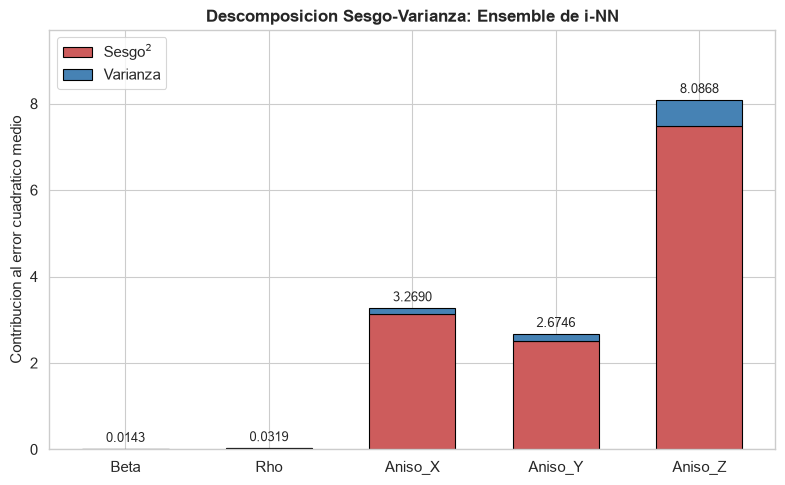

In [46]:
# ======================================================================
# DESCOMPOSICION SESGO-VARIANZA (Bias-Variance Decomposition)
# ======================================================================
# Derivacion teorica (para el informe LaTeX):
#
# Para un input x con M modelos (ensemble), definimos:
#   y_bar(x) = (1/M) * sum_{m=1}^M y_m(x)        [promedio del ensemble]
#
# Sesgo^2(x)  = (y_bar(x) - y*(x))^2               [error sistematico]
# Varianza(x) = (1/M) * sum_{m=1}^M (y_m(x) - y_bar(x))^2   [dispersion]
# Error(x)    = (1/M) * sum_{m=1}^M (y_m(x) - y*(x))^2      [error total]
#
# Descomposicion:  Error(x) = Sesgo^2(x) + Varianza(x)  [+ Ruido]
# En nuestro caso el ruido es ~0 (test set es determinista).
#
# Aplicacion al proyecto:
#   - Si Varianza >> Sesgo^2 en los angulos: el ensemble explora multiples
#     modos de la distribucion p(Theta|G), confirmando multimodalidad.
#   - Si Sesgo^2 es alto y el ground truth no cae cerca de y_bar: la media
#     del ensemble no es una estimacion fisica valida.
# ======================================================================


# --- PARTE A: Sesgo-Varianza del ENSEMBLE de i-NN (Pilar 3) ---
# Requiere que 'predictions' del ensemble este en memoria.
# predictions shape: [N_ENSEMBLE, 5] (normalizado)

print("=" * 70)
print("DESCOMPOSICION SESGO-VARIANZA: ENSEMBLE de i-NN")
print("=" * 70)

# Usamos todas las muestras de test, no solo una
# Para eso necesitamos las predicciones del ensemble en TODO el test set
# Vamos a recalcularlas rapidamente si no estan disponibles

ensemble_preds_test = []  # [N_ENSEMBLE, N_test, 5]

for model_i in ensemble_models:
    model_i.eval()
    with torch.no_grad():
        preds = model_i(torch.tensor(y_test, dtype=torch.float32)).numpy()
    ensemble_preds_test.append(preds)

ensemble_preds_test = np.array(ensemble_preds_test)  # [N_ENSEMBLE, N_test, 5]
# ensemble_preds_test[m, n, j] = prediccion del modelo m para muestra n, parametro j

# Promedio del ensemble
y_bar = np.mean(ensemble_preds_test, axis=0)  # [N_test, 5]

# Metricas por parametro
bias2 = np.mean((y_bar - X_test) ** 2, axis=0)      # [5]
variance = np.mean(np.mean((ensemble_preds_test - y_bar[None, :, :]) ** 2, axis=0), axis=0)  # [5]
error_total = np.mean(np.mean((ensemble_preds_test - X_test[None, :, :]) ** 2, axis=0), axis=0)  # [5]

print(f"\n{'Parametro':<12} {'Sesgo^2':>12} {'Varianza':>12} {'Error':>12} {'Var/Err':>10}")
print("-" * 62)
for j, col in enumerate(theta_cols):
    ratio = variance[j] / error_total[j] if error_total[j] > 1e-12 else 0
    print(f"{col:<12} {bias2[j]:>12.6f} {variance[j]:>12.6f} {error_total[j]:>12.6f} {ratio:>10.3f}")

# Verificacion: Error ≈ Sesgo^2 + Varianza
print(f"\nVerificacion: Error total = {np.sum(error_total):.6f}")
print(f"              Sesgo^2 + Var = {np.sum(bias2) + np.sum(variance):.6f}")
print(f"              Diferencia = {np.abs(np.sum(error_total) - (np.sum(bias2) + np.sum(variance))):.2e}")

# --- Figura 1: Barras apiladas Sesgo^2 vs Varianza por parametro ---
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(theta_cols))
width = 0.6

bars1 = ax.bar(x, bias2, width, label='Sesgo$^2$', color='indianred', edgecolor='black')
bars2 = ax.bar(x, variance, width, bottom=bias2, label='Varianza', color='steelblue', edgecolor='black')

ax.set_ylabel('Contribucion al error cuadratico medio', fontsize=11)
ax.set_title('Descomposicion Sesgo-Varianza: Ensemble de i-NN', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(theta_cols)
ax.legend()
ax.set_ylim(0, max(bias2 + variance) * 1.2)

# Anotar valores
for i in range(len(theta_cols)):
    height = bias2[i] + variance[i]
    ax.annotate(f'{height:.4f}', xy=(i, height), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("figuras/bias_variance_ensemble.png", dpi=300, bbox_inches='tight')
plt.show()


### Sesgo-varianza de la f-NN (5 semillas)


DESCOMPOSICION SESGO-VARIANZA: f-NN (100% datos, 5 semillas)
  Seed 100 terminada | R2 = 0.9862
  Seed 101 terminada | R2 = 0.9865
  Seed 102 terminada | R2 = 0.9858
  Seed 103 terminada | R2 = 0.9869
  Seed 104 terminada | R2 = 0.9883

Propiedad               Sesgo^2     Varianza        Error    Var/Err
--------------------------------------------------------------------
Area_Inner             0.001393     0.001035     0.002428      0.426
Area_Outer             0.020266     0.001251     0.021517      0.058
Total_Area             0.002031     0.001084     0.003115      0.348
Volume                 0.003966     0.001164     0.005129      0.227
SA_Vol_Ratio           0.002927     0.001238     0.004165      0.297
Porosity               0.003998     0.001168     0.005166      0.226
Pore_Size              0.044387     0.004860     0.049248      0.099


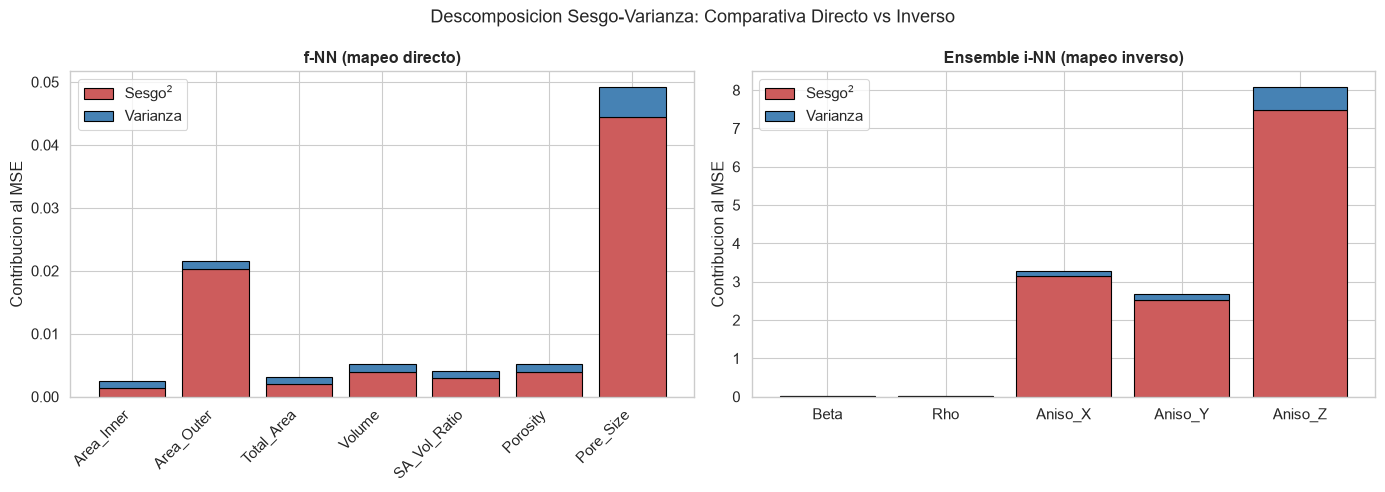


[OK] bias_variance_results.json guardado.
[OK] Figuras guardadas: bias_variance_ensemble.png, bias_variance_comparison.png


In [47]:
# --- PARTE B: Sesgo-Varianza del f-NN con multiples semillas (Pilar 1) ---
# Usamos las predicciones de la curva de aprendizaje (fraccion 100%, 5 semillas)
# Si no tienes las predicciones guardadas, recalculamos rapidamente

print("\n" + "=" * 70)
print("DESCOMPOSICION SESGO-VARIANZA: f-NN (100% datos, 5 semillas)")
print("=" * 70)

# Re-entrenar 5 f-NN rapidamente con las semillas de la curva de aprendizaje
# Nota: esto puede tardar ~5-10 min. Si ya tienes las predicciones guardadas,
# carga esas en lugar de re-entrenar.

fnn_preds_test = []  # [5, N_test, 7]

for seed in [100, 101, 102, 103, 104]:
    torch.manual_seed(seed)
    model_f = ForwardNN().to(device)
    optimizer = torch.optim.Adam(model_f.parameters(), lr=5e-4, weight_decay=1e-5)
    criterion = nn.MSELoss()

    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                             torch.tensor(y_train, dtype=torch.float32))
    train_loader_f = DataLoader(train_ds, batch_size=64, shuffle=True)

    # Entrenamiento rapido (max 200 epocas o patience=15 para velocidad)
    best_val = np.inf
    counter = 0
    best_state = None

    for epoch in range(200):
        model_f.train()
        for xb, yb in train_loader_f:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model_f(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_f.parameters(), 1.0)
            optimizer.step()

        model_f.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model_f(xb), yb).item()
        val_loss /= len(test_loader)

        if val_loss < best_val:
            best_val = val_loss
            counter = 0
            best_state = {k: v.cpu().clone() for k, v in model_f.state_dict().items()}
        else:
            counter += 1
            if counter >= 15:
                break

    if best_state:
        model_f.load_state_dict(best_state)
    model_f = model_f.cpu().eval()

    with torch.no_grad():
        pred = model_f(torch.tensor(X_test, dtype=torch.float32)).numpy()
    fnn_preds_test.append(pred)
    print(f"  Seed {seed} terminada | R2 = {1 - np.sum((y_test - pred)**2)/np.sum((y_test - np.mean(y_test))**2):.4f}")

fnn_preds_test = np.array(fnn_preds_test)  # [5, N_test, 7]

# Promedio y metricas
y_bar_f = np.mean(fnn_preds_test, axis=0)  # [N_test, 7]
bias2_f = np.mean((y_bar_f - y_test) ** 2, axis=0)
variance_f = np.mean(np.mean((fnn_preds_test - y_bar_f[None, :, :]) ** 2, axis=0), axis=0)
error_f = np.mean(np.mean((fnn_preds_test - y_test[None, :, :]) ** 2, axis=0), axis=0)

print(f"\n{'Propiedad':<18} {'Sesgo^2':>12} {'Varianza':>12} {'Error':>12} {'Var/Err':>10}")
print("-" * 68)
for j, col in enumerate(G_cols):
    ratio = variance_f[j] / error_f[j] if error_f[j] > 1e-12 else 0
    print(f"{col:<18} {bias2_f[j]:>12.6f} {variance_f[j]:>12.6f} {error_f[j]:>12.6f} {ratio:>10.3f}")

# --- Figura 2: Comparativa f-NN vs i-NN ensemble ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# f-NN
x1 = np.arange(len(G_cols))
axes[0].bar(x1, bias2_f, label='Sesgo$^2$', color='indianred', edgecolor='black')
axes[0].bar(x1, variance_f, bottom=bias2_f, label='Varianza', color='steelblue', edgecolor='black')
axes[0].set_xticks(x1)
axes[0].set_xticklabels(G_cols, rotation=45, ha='right')
axes[0].set_ylabel('Contribucion al MSE')
axes[0].set_title('f-NN (mapeo directo)', fontweight='bold')
axes[0].legend()

# i-NN ensemble
x2 = np.arange(len(theta_cols))
axes[1].bar(x2, bias2, label='Sesgo$^2$', color='indianred', edgecolor='black')
axes[1].bar(x2, variance, bottom=bias2, label='Varianza', color='steelblue', edgecolor='black')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(theta_cols)
axes[1].set_ylabel('Contribucion al MSE')
axes[1].set_title('Ensemble i-NN (mapeo inverso)', fontweight='bold')
axes[1].legend()

plt.suptitle('Descomposicion Sesgo-Varianza: Comparativa Directo vs Inverso', fontsize=13)
plt.tight_layout()
plt.savefig("figuras/bias_variance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Guardar resultados ---
sv_results = {
    'ensemble_inverse': {
        'parameters': theta_cols,
        'bias2': bias2.tolist(),
        'variance': variance.tolist(),
        'error_total': error_total.tolist()
    },
    'fnn_direct': {
        'properties': G_cols,
        'bias2': bias2_f.tolist(),
        'variance': variance_f.tolist(),
        'error_total': error_f.tolist()
    }
}

with open("jsones/bias_variance_results.json", "w") as f:
    json.dump(sv_results, f, indent=2)

print("\n[OK] bias_variance_results.json guardado.")
print("[OK] Figuras guardadas: bias_variance_ensemble.png, bias_variance_comparison.png")

# Mixture Density Network (MDN)

El ensemble aproxima $p(\Theta \mid G)$ de forma implicita: cada red converge a un modo
segun su inicializacion, sin garantia de cubrir todos los modos ni de asignarles peso.
La MDN modela la distribucion condicional de forma **parametrica y explicita** como una
mezcla de $K$ gaussianas diagonales:

$$p(\Theta \mid G) = \sum_{k=1}^{K} \pi_k(G)\, \mathcal{N}\big(\Theta \mid \mu_k(G),\, \mathrm{diag}(\sigma_k^2(G))\big)$$

donde una unica red predice, para cada entrada $G$:
- Los pesos de mezcla $\pi_k(G)$ (softmax, suman 1).
- Las medias $\mu_k(G) \in \mathbb{R}^5$ de cada componente.
- Las log-varianzas $s_k(G) = \log \sigma_k^2(G) \in \mathbb{R}^5$ (garantiza positividad).

**Perdida (NLL de mezcla):**

$$\mathcal{L} = -\log \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\Theta \mid \mu_k, \sigma_k^2)
= -\,\mathrm{logsumexp}_k\Big[ \log \pi_k + \sum_{j=1}^{5} \big( -\tfrac{1}{2}\log(2\pi) - \tfrac{1}{2} s_{kj} - \tfrac{1}{2}(\theta_j - \mu_{kj})^2 e^{-s_{kj}} \big) \Big]$$

Se implementa con `logsumexp` para estabilidad numerica. A diferencia del MSE, esta
perdida **no colapsa al promedio de modos**: si dos modos explican los datos, la mezcla
puede asignar una componente a cada uno.

**Conexion con el curso:** es la extension natural de la NLL heterocedastica de la f-NN-prob
(una gaussiana) a una mezcla de gaussianas (Bishop, 1994).

### Definición

In [48]:
# ======================================================================
# MDN: DEFINICION
# ======================================================================

K_COMPONENTS = 3      # numero de componentes de la mezcla
MDN_HIDDEN = [128, 128, 64]   # mismo cuerpo que la i-NN (comparacion justa)
MDN_DROPOUT = 0.1
LOGVAR_MIN, LOGVAR_MAX = -7.0, 2.0

class MDN(nn.Module):
    """Mixture Density Network: G (7) -> mezcla de K gaussianas sobre Theta (5)."""
    def __init__(self, input_dim=7, output_dim=5, K=K_COMPONENTS,
                 hidden=MDN_HIDDEN, dropout=MDN_DROPOUT):
        super().__init__()
        self.K = K
        self.D = output_dim

        layers = []
        prev = input_dim
        for h in hidden:
            layers.extend([nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)])
            prev = h
        self.body = nn.Sequential(*layers)

        # Tres cabezas (sin dropout en las cabezas)
        self.pi_head = nn.Linear(prev, K)              # logits de los pesos
        self.mu_head = nn.Linear(prev, K * output_dim) # medias
        self.logvar_head = nn.Linear(prev, K * output_dim)

        # Inicializacion anti-colapso: bias de las medias disperso en el
        # espacio normalizado, para que las K componentes partan separadas
        with torch.no_grad():
            self.mu_head.bias.uniform_(-1.5, 1.5)
            self.logvar_head.bias.fill_(0.0)
            self.logvar_head.weight.mul_(0.01)  # varianzas iniciales ~1

    def forward(self, x):
        h = self.body(x)
        logits = self.pi_head(h)                                  # [B, K]
        mu = self.mu_head(h).view(-1, self.K, self.D)             # [B, K, D]
        log_var = self.logvar_head(h).view(-1, self.K, self.D)
        log_var = torch.clamp(log_var, LOGVAR_MIN, LOGVAR_MAX)    # [B, K, D]
        return logits, mu, log_var


def mdn_nll_loss(logits, mu, log_var, theta):
    """NLL de mezcla gaussiana diagonal, estable via logsumexp.

    logits: [B, K] | mu, log_var: [B, K, D] | theta: [B, D]
    """
    log_pi = torch.log_softmax(logits, dim=1)                     # [B, K]
    diff = theta.unsqueeze(1) - mu                                # [B, K, D]
    log_prob_comp = -0.5 * (np.log(2 * np.pi) + log_var
                            + diff.pow(2) * torch.exp(-log_var))  # [B, K, D]
    log_prob_comp = log_prob_comp.sum(dim=2)                      # [B, K]
    log_prob = torch.logsumexp(log_pi + log_prob_comp, dim=1)     # [B]
    return -log_prob.mean()


# Verificacion rapida de shapes
_m = MDN()
_l, _mu, _lv = _m(torch.randn(4, 7))
print("Shapes:", _l.shape, _mu.shape, _lv.shape)
print("NLL de prueba:", mdn_nll_loss(_l, _mu, _lv, torch.randn(4, 5)).item())
del _m, _l, _mu, _lv

Shapes: torch.Size([4, 3]) torch.Size([4, 3, 5]) torch.Size([4, 3, 5])
NLL de prueba: 7.477630138397217


### Entrenamiento

Epoca   0 | train NLL = 5.6496 | val NLL = 3.8193
Epoca  20 | train NLL = 3.0145 | val NLL = 2.3474
Epoca  40 | train NLL = 2.6718 | val NLL = 1.9737
Epoca  60 | train NLL = 2.5467 | val NLL = 1.8712
Epoca  80 | train NLL = 2.4337 | val NLL = 1.8807
Epoca 100 | train NLL = 2.3385 | val NLL = 1.8550
Early stopping en epoca 104

Mejor val NLL: 1.6824


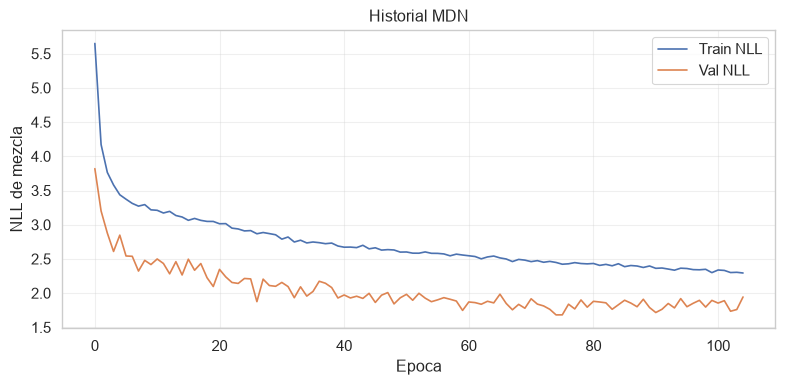

In [49]:
# ======================================================================
# MDN: ENTRENAMIENTO
# ======================================================================
# Split interno 90/10 del train para early stopping (el test queda intacto)
torch.manual_seed(300)
n_tr = len(y_train)
perm = np.random.RandomState(300).permutation(n_tr)
n_val = int(0.1 * n_tr)
idx_val, idx_tr = perm[:n_val], perm[n_val:]

G_tr = torch.tensor(y_train[idx_tr], dtype=torch.float32)
T_tr = torch.tensor(X_train[idx_tr], dtype=torch.float32)
G_val = torch.tensor(y_train[idx_val], dtype=torch.float32).to(device)
T_val = torch.tensor(X_train[idx_val], dtype=torch.float32).to(device)

train_loader_mdn = DataLoader(TensorDataset(G_tr, T_tr), batch_size=64, shuffle=True)

mdn = MDN().to(device)
optimizer_mdn = optim.Adam(mdn.parameters(), lr=1e-3, weight_decay=1e-5)

MDN_EPOCHS = 300
MDN_PATIENCE = 30

best_val = np.inf
counter = 0
best_state = None
mdn_train_hist, mdn_val_hist = [], []

for epoch in range(MDN_EPOCHS):
    mdn.train()
    epoch_loss = 0.0
    for gb, tb in train_loader_mdn:
        gb, tb = gb.to(device), tb.to(device)
        optimizer_mdn.zero_grad()
        logits, mu, log_var = mdn(gb)
        loss = mdn_nll_loss(logits, mu, log_var, tb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mdn.parameters(), 1.0)
        optimizer_mdn.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader_mdn)

    mdn.eval()
    with torch.no_grad():
        lv, mv, vv = mdn(G_val)
        val_loss = mdn_nll_loss(lv, mv, vv, T_val).item()

    mdn_train_hist.append(epoch_loss)
    mdn_val_hist.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        counter = 0
        best_state = {k: v.cpu().clone() for k, v in mdn.state_dict().items()}
    else:
        counter += 1
        if counter >= MDN_PATIENCE:
            print(f"Early stopping en epoca {epoch}")
            break

    if epoch % 20 == 0:
        print(f"Epoca {epoch:3d} | train NLL = {epoch_loss:.4f} | val NLL = {val_loss:.4f}")

mdn.load_state_dict(best_state)
mdn.eval()
torch.save(best_state, "modelos/mdn_best.pt")
print(f"\nMejor val NLL: {best_val:.4f}")

# Historial de perdida
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mdn_train_hist, label='Train NLL')
ax.plot(mdn_val_hist, label='Val NLL')
ax.set_xlabel('Epoca'); ax.set_ylabel('NLL de mezcla')
ax.set_title('Historial MDN'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figuras/mdn_history.png", dpi=300, bbox_inches='tight')
plt.show()

### Evaluación

In [50]:
# ======================================================================
# MDN: EVALUACION GLOBAL EN TEST
# ======================================================================
G_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)
T_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

mdn.eval()
with torch.no_grad():
    logits_te, mu_te, logvar_te = mdn(G_test_t)
    nll_test_mdn = mdn_nll_loss(logits_te, mu_te, logvar_te, T_test_t).item()

pi_te = torch.softmax(logits_te, dim=1).cpu().numpy()      # [N, K]
mu_te_np = mu_te.cpu().numpy()
logvar_te_np = logvar_te.cpu().numpy()

print("=" * 70)
print("EVALUACION MDN EN TEST")
print("=" * 70)
print(f"NLL de mezcla en test: {nll_test_mdn:.4f}")
print(f"\nPesos de mezcla promedio (uso de componentes):")
for k in range(K_COMPONENTS):
    print(f"  Componente {k+1}: pi promedio = {pi_te[:, k].mean():.3f} "
          f"(min={pi_te[:, k].min():.3f}, max={pi_te[:, k].max():.3f})")

# Diagnostico de colapso: si una componente tiene pi promedio > 0.95, colapso
if pi_te.max(axis=1).mean() > 0.95:
    print("\n[ADVERTENCIA] Posible colapso de modos: una componente domina siempre.")
else:
    print("\n[OK] La mezcla usa varias componentes segun la entrada.")

# Prediccion puntual (media de la componente dominante) para comparar con la i-NN
k_star = np.argmax(pi_te, axis=1)
point_pred = mu_te_np[np.arange(len(k_star)), k_star]       # [N, 5]

print(f"\nR2 'puntual' por parametro (modo dominante vs Theta verdadero):")
print("(esperamos R2 bajo o negativo en angulos: elegir UN modo entre varios")
print(" validos no tiene por que coincidir con el modo del que se genero el dato)")
for j, col in enumerate(theta_cols):
    r2j = r2_score(X_test[:, j], point_pred[:, j])
    print(f"  {col:10s}: R2 = {r2j:+.4f}")

EVALUACION MDN EN TEST
NLL de mezcla en test: 1.7789

Pesos de mezcla promedio (uso de componentes):
  Componente 1: pi promedio = 0.233 (min=0.001, max=0.999)
  Componente 2: pi promedio = 0.521 (min=0.000, max=0.965)
  Componente 3: pi promedio = 0.246 (min=0.000, max=0.999)

[OK] La mezcla usa varias componentes segun la entrada.

R2 'puntual' por parametro (modo dominante vs Theta verdadero):
(esperamos R2 bajo o negativo en angulos: elegir UN modo entre varios
 validos no tiene por que coincidir con el modo del que se genero el dato)
  Beta      : R2 = +0.9973
  Rho       : R2 = +0.9929
  Aniso_X   : R2 = +0.0107
  Aniso_Y   : R2 = -0.0163
  Aniso_Z   : R2 = +0.0077


MODOS DE LA MDN PARA LA MUESTRA TEST #0
Theta verdadero: {'Beta': np.float64(33.69), 'Rho': np.float64(0.52), 'Aniso_X': np.float64(60.18), 'Aniso_Y': np.float64(20.49), 'Aniso_Z': np.float64(50.47)}

Componente 1 (pi = 0.103):
   Beta      : mu =   34.732  +/- 0.359
   Rho       : mu =    0.512  +/- 0.007
   Aniso_X   : mu =   45.181  +/- 27.340
   Aniso_Y   : mu =   53.437  +/- 21.369
   Aniso_Z   : mu =   45.905  +/- 24.713

Componente 2 (pi = 0.813):
   Beta      : mu =   33.948  +/- 0.404
   Rho       : mu =    0.510  +/- 0.007
   Aniso_X   : mu =   46.479  +/- 25.559
   Aniso_Y   : mu =   45.653  +/- 26.583
   Aniso_Z   : mu =   44.376  +/- 25.591

Componente 3 (pi = 0.085):
   Beta      : mu =   34.806  +/- 0.505
   Rho       : mu =    0.520  +/- 0.007
   Aniso_X   : mu =   45.598  +/- 27.237
   Aniso_Y   : mu =   27.380  +/- 19.648
   Aniso_Z   : mu =   42.150  +/- 25.181



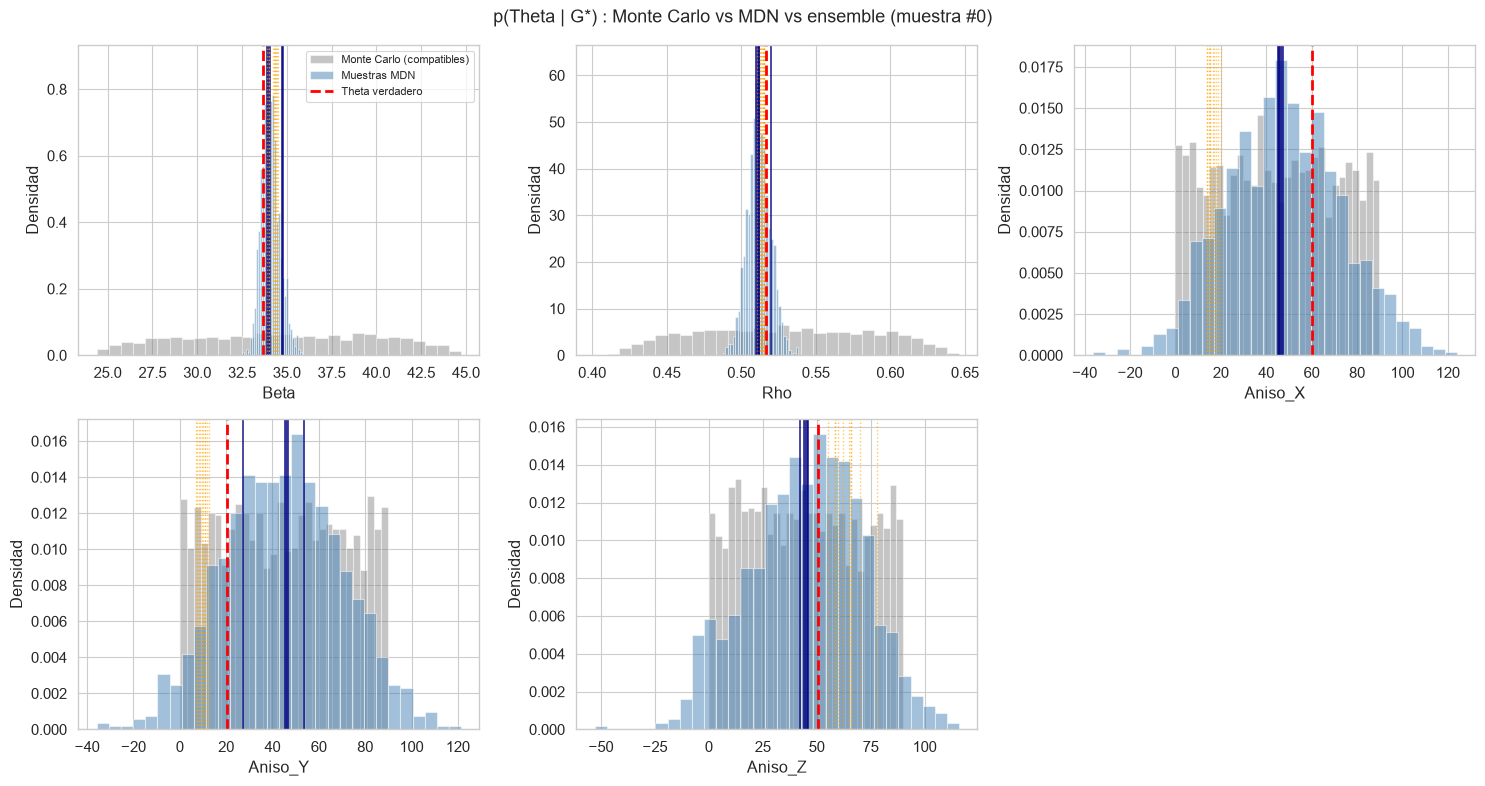

In [51]:
# ======================================================================
# MDN: ANALISIS DE MODOS PARA LA MUESTRA DE REFERENCIA (IDX_SAMPLE)
# ======================================================================
# Comparamos los modos de la MDN contra:
#   1. La nube Monte Carlo de Theta compatibles (compatible_theta)
#   2. Las predicciones del ensemble (predictions_orig)
# ======================================================================

G_star_t = torch.tensor(y_test[IDX_SAMPLE:IDX_SAMPLE+1], dtype=torch.float32).to(device)
with torch.no_grad():
    logits_s, mu_s, logvar_s = mdn(G_star_t)

pi_s = torch.softmax(logits_s, dim=1).cpu().numpy()[0]          # [K]
mu_s_np = mu_s.cpu().numpy()[0]                                  # [K, 5]
sigma_s_np = np.exp(0.5 * logvar_s.cpu().numpy()[0])             # [K, 5]

# Desnormalizar medias y sigmas a escala original
mu_s_orig = scaler_X.inverse_transform(mu_s_np)                  # [K, 5]
sigma_s_orig = sigma_s_np * scaler_X.scale_                      # [K, 5] (solo escala)

print("=" * 70)
print(f"MODOS DE LA MDN PARA LA MUESTRA TEST #{IDX_SAMPLE}")
print("=" * 70)
print(f"Theta verdadero: {dict(zip(theta_cols, np.round(theta_true_orig, 2)))}")
print()
for k in range(K_COMPONENTS):
    print(f"Componente {k+1} (pi = {pi_s[k]:.3f}):")
    for j, col in enumerate(theta_cols):
        print(f"   {col:10s}: mu = {mu_s_orig[k, j]:8.3f}  +/- {sigma_s_orig[k, j]:.3f}")
    print()

# Muestrear de la mezcla para esta G*
N_SAMP = 1000
rng_s = np.random.RandomState(123)
ks = rng_s.choice(K_COMPONENTS, size=N_SAMP, p=pi_s)
mdn_samples_norm = mu_s_np[ks] + rng_s.randn(N_SAMP, 5) * sigma_s_np[ks]
mdn_samples_orig = scaler_X.inverse_transform(mdn_samples_norm)

# --- Figura: MC vs MDN vs ensemble ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for j, col in enumerate(theta_cols):
    ax = axes[j]
    # Nube MC (referencia empirica de p(Theta|G*))
    ax.hist(compatible_theta[:, j], bins=30, density=True, alpha=0.45,
            color='gray', label='Monte Carlo (compatibles)')
    # Muestras de la MDN
    ax.hist(mdn_samples_orig[:, j], bins=30, density=True, alpha=0.5,
            color='steelblue', label='Muestras MDN')
    # Modos de la MDN (grosor proporcional al peso pi_k)
    for k in range(K_COMPONENTS):
        ax.axvline(mu_s_orig[k, j], color='navy', linestyle='-',
                   linewidth=1 + 3 * pi_s[k], alpha=0.8)
    # Ensemble
    for m in range(len(predictions_orig)):
        ax.axvline(predictions_orig[m, j], color='orange', linestyle=':',
                   linewidth=1, alpha=0.6)
    # Ground truth
    ax.axvline(theta_true_orig[j], color='red', linestyle='--',
               linewidth=2, label='Theta verdadero')
    ax.set_xlabel(col); ax.set_ylabel('Densidad')
    if j == 0:
        ax.legend(fontsize=8)
axes[5].axis('off')
plt.suptitle(f'p(Theta | G*) : Monte Carlo vs MDN vs ensemble (muestra #{IDX_SAMPLE})',
             fontsize=13)
plt.tight_layout()
plt.savefig("figuras/mdn_vs_mc_vs_ensemble.png", dpi=300, bbox_inches='tight')
plt.show()

In [52]:
# ======================================================================
# MDN: VALIDEZ FISICA DE LAS MUESTRAS (reconstruccion via f-NN) Y COBERTURA
# ======================================================================

# --- 1. Reconstruccion: las muestras de la MDN deben reproducir G* ---
mdn_samples_t = torch.tensor(mdn_samples_norm, dtype=torch.float32).to(device)
with torch.no_grad():
    G_recon_mdn = f_nn(mdn_samples_t).cpu().numpy()

recon_err_mdn = np.mean((G_recon_mdn - y_test[IDX_SAMPLE]) ** 2, axis=1)  # [N_SAMP]

print("=" * 70)
print("RECONSTRUCCION G DESDE MUESTRAS DE LA MDN")
print("=" * 70)
print(f"Error de reconstruccion promedio: {recon_err_mdn.mean():.6f} +/- {recon_err_mdn.std():.6f}")
print(f"Mediana: {np.median(recon_err_mdn):.6f}")
print(f"Fraccion con error < {EPSILON_MC} (umbral MC): "
      f"{(recon_err_mdn < EPSILON_MC).mean() * 100:.1f}%")
print(f"\nReferencia: el ensemble reconstruye con error ~0.0008 y el umbral")
print(f"de compatibilidad del Monte Carlo es {EPSILON_MC}.")

# --- 2. Cobertura de la nube MC por la mezcla ---
# Para cada Theta compatible del MC (normalizado), calculamos su log-densidad
# bajo la mezcla de la MDN. Si la MDN cubre bien p(Theta|G*), las densidades
# deben ser comparables a las de las propias muestras de la MDN.
compatible_norm = scaler_X.transform(compatible_theta)

def mixture_logpdf(x, pi, mu, sigma):
    """log p(x) bajo mezcla gaussiana diagonal. x:[N,D], mu/sigma:[K,D], pi:[K]"""
    N = x.shape[0]; K = mu.shape[0]
    lp = np.zeros((N, K))
    for k in range(K):
        lp[:, k] = (np.log(pi[k] + 1e-12)
                    - 0.5 * np.sum(np.log(2 * np.pi * sigma[k] ** 2))
                    - 0.5 * np.sum((x - mu[k]) ** 2 / sigma[k] ** 2, axis=1))
    return logsumexp(lp, axis=1)

logpdf_mc = mixture_logpdf(compatible_norm, pi_s, mu_s_np, sigma_s_np)
logpdf_own = mixture_logpdf(mdn_samples_norm, pi_s, mu_s_np, sigma_s_np)

# Umbral: percentil 5 de la densidad de las propias muestras de la mezcla
umbral = np.percentile(logpdf_own, 5)
cobertura = (logpdf_mc >= umbral).mean() * 100

print("\n" + "=" * 70)
print("COBERTURA DE LA NUBE MONTE CARLO POR LA MEZCLA")
print("=" * 70)
print(f"Umbral (percentil 5 de densidad propia): {umbral:.2f}")
print(f"Cobertura: {cobertura:.1f}% de los Theta compatibles del MC tienen")
print(f"densidad de mezcla por encima del umbral.")
print("\nLectura: cobertura alta = la MDN representa bien la region compatible;")
print("cobertura baja = la MDN captura solo algunos modos de p(Theta|G*).")

# --- 3. Guardar resultados ---
mdn_results = {
    "nll_test": float(nll_test_mdn),
    "K": int(K_COMPONENTS),
    "pi_promedio_test": [float(v) for v in pi_te.mean(axis=0)],
    "muestra_idx": int(IDX_SAMPLE),
    "pi_muestra": [float(v) for v in pi_s],
    "modos_muestra_orig": mu_s_orig.tolist(),
    "sigmas_muestra_orig": sigma_s_orig.tolist(),
    "recon_error_mean": float(recon_err_mdn.mean()),
    "recon_error_std": float(recon_err_mdn.std()),
    "fraccion_compatible": float((recon_err_mdn < EPSILON_MC).mean()),
    "cobertura_mc_pct": float(cobertura),
}
with open("jsones/mdn_results.json", "w") as f:
    json.dump(mdn_results, f, indent=2)
print("\n[OK] mdn_results.json guardado.")

RECONSTRUCCION G DESDE MUESTRAS DE LA MDN
Error de reconstruccion promedio: 0.005861 +/- 0.005492
Mediana: 0.004138
Fraccion con error < 0.5 (umbral MC): 100.0%

Referencia: el ensemble reconstruye con error ~0.0008 y el umbral
de compatibilidad del Monte Carlo es 0.5.

COBERTURA DE LA NUBE MONTE CARLO POR LA MEZCLA
Umbral (percentil 5 de densidad propia): -4.35
Cobertura: 2.9% de los Theta compatibles del MC tienen
densidad de mezcla por encima del umbral.

Lectura: cobertura alta = la MDN representa bien la region compatible;
cobertura baja = la MDN captura solo algunos modos de p(Theta|G*).

[OK] mdn_results.json guardado.


## Baseline unimodal: mezcla con K=1

Para afirmar que la mezcla de $K=3$ componentes aporta algo, necesitamos un baseline
con la misma arquitectura y la misma perdida pero $K=1$: una gaussiana condicional
unica $p(\Theta \mid G) = \mathcal{N}(\Theta \mid \mu(G), \sigma^2(G))$.

**Expectativa previa al experimento** (a verificar):
- La NLL de test de $K=1$ deberia ser **peor** (mayor) que la de $K=3$ si la
  distribucion condicional es genuinamente multimodal.
- Con $K=1$, la media $\mu(G)$ deberia colapsar al promedio de modos en los angulos
  (igual que la i-NN con MSE) y su $\sigma$ deberia inflarse hasta cubrir todos los
  modos ($\approx 26^{\circ}$, la desviacion de una uniforme en el rango fisico).

In [53]:
# ======================================================================
# BASELINE MDN K=1: ENTRENAMIENTO Y COMPARACION
# ======================================================================
# Reusa la clase MDN, la perdida y los loaders ya definidos.

def entrenar_mdn(K, seed, epochs=300, patience=30, verbose=False):
    """Entrena una MDN con K componentes y devuelve (modelo, mejor_val_nll)."""
    torch.manual_seed(seed)
    model = MDN(K=K).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    best_val, counter, best_state = np.inf, 0, None
    for epoch in range(epochs):
        model.train()
        for gb, tb in train_loader_mdn:
            gb, tb = gb.to(device), tb.to(device)
            opt.zero_grad()
            lo, mu_, lv = model(gb)
            loss = mdn_nll_loss(lo, mu_, lv, tb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            lo, mu_, lv = model(G_val)
            val_loss = mdn_nll_loss(lo, mu_, lv, T_val).item()

        if val_loss < best_val:
            best_val, counter = val_loss, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            counter += 1
            if counter >= patience:
                if verbose:
                    print(f"  Early stopping en epoca {epoch}")
                break

    model.load_state_dict(best_state)
    return model.eval(), best_val


print("Entrenando baseline K=1 (misma arquitectura, misma perdida)...")
mdn_k1, val_k1 = entrenar_mdn(K=1, seed=300, verbose=True)

# NLL en test
with torch.no_grad():
    lo1, mu1, lv1 = mdn_k1(G_test_t)
    nll_test_k1 = mdn_nll_loss(lo1, mu1, lv1, T_test_t).item()

print("=" * 70)
print("COMPARACION K=1 (gaussiana unica) vs K=3 (mezcla)")
print("=" * 70)
print(f"NLL test K=1: {nll_test_k1:.4f}")
print(f"NLL test K=3: {nll_test_mdn:.4f}")
print(f"Delta (K1 - K3): {nll_test_k1 - nll_test_mdn:+.4f}  "
      f"({'la mezcla mejora' if nll_test_k1 > nll_test_mdn else 'la mezcla NO mejora'})")

# Sigma promedio del K=1 en test, por parametro (en escala original)
sigma_k1 = np.exp(0.5 * lv1.cpu().numpy()[:, 0, :])          # [N, 5]
sigma_k1_orig = sigma_k1.mean(axis=0) * scaler_X.scale_
print(f"\nSigma promedio predicho por K=1 (escala original):")
for j, col in enumerate(theta_cols):
    print(f"  {col:10s}: {sigma_k1_orig[j]:8.3f}")
print("\nReferencia: la std de una uniforme en [0, 90] es 90/sqrt(12) = 25.98")

# R2 puntual del K=1 (su media unica)
mu1_np = mu1.cpu().numpy()[:, 0, :]
print(f"\nR2 puntual K=1 (media unica vs Theta verdadero):")
for j, col in enumerate(theta_cols):
    print(f"  {col:10s}: R2 = {r2_score(X_test[:, j], mu1_np[:, j]):+.4f}")

# Guardar comparacion
with open("jsones/mdn_baseline_k1.json", "w") as f:
    json.dump({
        "nll_test_k1": float(nll_test_k1),
        "nll_test_k3": float(nll_test_mdn),
        "delta": float(nll_test_k1 - nll_test_mdn),
        "sigma_k1_orig_mean": [float(v) for v in sigma_k1_orig],
    }, f, indent=2)
print("\n[OK] mdn_baseline_k1.json guardado.")

Entrenando baseline K=1 (misma arquitectura, misma perdida)...
  Early stopping en epoca 81
COMPARACION K=1 (gaussiana unica) vs K=3 (mezcla)
NLL test K=1: 1.9332
NLL test K=3: 1.7789
Delta (K1 - K3): +0.1543  (la mezcla mejora)

Sigma promedio predicho por K=1 (escala original):
  Beta      :    0.913
  Rho       :    0.015
  Aniso_X   :   25.943
  Aniso_Y   :   26.535
  Aniso_Z   :   26.203

Referencia: la std de una uniforme en [0, 90] es 90/sqrt(12) = 25.98

R2 puntual K=1 (media unica vs Theta verdadero):
  Beta      : R2 = +0.9985
  Rho       : R2 = +0.9922
  Aniso_X   : R2 = +0.0069
  Aniso_Y   : R2 = -0.0013
  Aniso_Z   : R2 = +0.0043

[OK] mdn_baseline_k1.json guardado.


## Generalización: diagnóstico sobre múltiples muestras de test

Todo el diagnostico anterior (Monte Carlo, ensemble, MDN) se hizo sobre **una**
muestra de test. Para verificar que el fenomeno no es idiosincratico de esa muestra,
repetimos el protocolo completo sobre las primeras 5 muestras del test:

1. **Monte Carlo:** fraccion de $\Theta$ compatibles y dispersion por parametro
   (se reutiliza un unico banco de $10^4$ muestras evaluado una vez por la f-NN).
2. **Ensemble:** dispersion de las 10 i-NN y error de reconstruccion.
3. **MDN:** desviacion total de la mezcla por parametro y validez fisica de sus muestras.

Si el patron (angulos no identificados, $\beta$ y $\rho$ acotados, soluciones
alternativas validas) se repite en las 5 muestras, la conclusion generaliza.

In [54]:
# ======================================================================
# DIAGNOSTICO MULTI-MUESTRA (indices 0 a 4 del test)
# ======================================================================
IDX_LIST = [0, 1, 2, 3, 4]
N_SAMP_MDN = 500

# --- Banco unico de muestras MC (una sola pasada por la f-NN) ---
rng_ms = np.random.RandomState(42)
bank = np.zeros((N_MC_SAMPLES, 5))
for i, col in enumerate(theta_cols):
    lo, hi = THETA_BOUNDS[col]
    bank[:, i] = rng_ms.uniform(lo, hi, N_MC_SAMPLES)
bank_norm = scaler_X.transform(bank)
with torch.no_grad():
    G_bank = f_nn(torch.tensor(bank_norm, dtype=torch.float32).to(device)).cpu().numpy()

resultados_ms = []
for idx in IDX_LIST:
    G_star_n = y_test[idx]                       # normalizado
    theta_true_o = scaler_X.inverse_transform(X_test[idx:idx+1])[0]

    # --- 1. Monte Carlo contra el banco ---
    errs = np.mean((G_bank - G_star_n) ** 2, axis=1)
    mask = errs < EPSILON_MC
    frac = mask.mean() * 100
    if mask.sum() > 1:
        std_mc = bank[mask].std(axis=0)          # escala original
    else:
        std_mc = np.full(5, np.nan)

    # --- 2. Ensemble (10 i-NN ya entrenadas, en CPU) ---
    G_star_cpu = torch.tensor(G_star_n.reshape(1, -1), dtype=torch.float32)
    preds = []
    for m_ in ensemble_models:
        with torch.no_grad():
            preds.append(m_(G_star_cpu).numpy()[0])
    preds = np.array(preds)                       # [10, 5] normalizado
    std_ens = preds.std(axis=0) * scaler_X.scale_ # escala original
    with torch.no_grad():
        G_rec_ens = f_nn(torch.tensor(preds, dtype=torch.float32).to(device)).cpu().numpy()
    recon_ens = np.mean((G_rec_ens - G_star_n) ** 2, axis=1).mean()

    # --- 3. MDN: desviacion total de la mezcla + validez de muestras ---
    with torch.no_grad():
        lo_, mu_, lv_ = mdn(torch.tensor(G_star_n.reshape(1, -1),
                                         dtype=torch.float32).to(device))
    pi_ = torch.softmax(lo_, dim=1).cpu().numpy()[0]
    mu_ = mu_.cpu().numpy()[0]
    sg_ = np.exp(0.5 * lv_.cpu().numpy()[0])
    # Varianza total de la mezcla: Var = sum pi_k (sigma_k^2 + mu_k^2) - mu_mix^2
    mu_mix = (pi_[:, None] * mu_).sum(0)
    var_mix = (pi_[:, None] * (sg_ ** 2 + mu_ ** 2)).sum(0) - mu_mix ** 2
    std_mdn = np.sqrt(np.maximum(var_mix, 0)) * scaler_X.scale_

    ks_ = rng_ms.choice(len(pi_), size=N_SAMP_MDN, p=pi_)
    samp_ = mu_[ks_] + rng_ms.randn(N_SAMP_MDN, 5) * sg_[ks_]
    with torch.no_grad():
        G_rec_mdn = f_nn(torch.tensor(samp_, dtype=torch.float32).to(device)).cpu().numpy()
    rec_mdn_errs = np.mean((G_rec_mdn - G_star_n) ** 2, axis=1)
    recon_mdn = rec_mdn_errs.mean()
    frac_valid_mdn = (rec_mdn_errs < EPSILON_MC).mean() * 100

    resultados_ms.append({
        "idx": idx,
        "frac_mc_pct": frac,
        "std_mc": std_mc.tolist(),
        "std_ens": std_ens.tolist(),
        "std_mdn": std_mdn.tolist(),
        "recon_ens": float(recon_ens),
        "recon_mdn": float(recon_mdn),
        "frac_valid_mdn_pct": float(frac_valid_mdn),
        "theta_true": theta_true_o.tolist(),
    })

# --- Tabla resumen ---
ang = slice(2, 5)   # indices de los tres angulos
print("=" * 100)
print("DIAGNOSTICO MULTI-MUESTRA: RESUMEN")
print("=" * 100)
print(f"{'idx':>3} | {'frac MC %':>9} | {'std MC ang (prom)':>17} | "
      f"{'std MDN ang (prom)':>18} | {'std ens ang (prom)':>18} | "
      f"{'recon ens':>10} | {'recon MDN':>10} | {'validez MDN %':>13}")
print("-" * 100)
for r in resultados_ms:
    print(f"{r['idx']:>3} | {r['frac_mc_pct']:>9.2f} | "
          f"{np.mean(r['std_mc'][2:5]):>17.2f} | "
          f"{np.mean(r['std_mdn'][2:5]):>18.2f} | "
          f"{np.mean(r['std_ens'][2:5]):>18.2f} | "
          f"{r['recon_ens']:>10.5f} | {r['recon_mdn']:>10.5f} | "
          f"{r['frac_valid_mdn_pct']:>13.1f}")
print("-" * 100)
print(f"Referencia: std de una uniforme en [0, 90] = {90/np.sqrt(12):.2f}")
print(f"Umbral de compatibilidad MC: {EPSILON_MC}")

# Tambien beta y rho para mostrar el contraste identificable/no identificable
print(f"\n{'idx':>3} | {'std MC Beta':>11} | {'std MDN Beta':>12} | "
      f"{'std MC Rho':>10} | {'std MDN Rho':>11}")
print("-" * 60)
for r in resultados_ms:
    print(f"{r['idx']:>3} | {r['std_mc'][0]:>11.3f} | {r['std_mdn'][0]:>12.3f} | "
          f"{r['std_mc'][1]:>10.4f} | {r['std_mdn'][1]:>11.4f}")

with open("jsones/multi_sample_diagnosis.json", "w") as f:
    json.dump(resultados_ms, f, indent=2)
print("\n[OK] multi_sample_diagnosis.json guardado.")

DIAGNOSTICO MULTI-MUESTRA: RESUMEN
idx | frac MC % | std MC ang (prom) | std MDN ang (prom) | std ens ang (prom) |  recon ens |  recon MDN | validez MDN %
----------------------------------------------------------------------------------------------------
  0 |     21.93 |             26.09 |              25.87 |               3.37 |    0.00074 |    0.00594 |         100.0
  1 |     16.92 |             26.00 |              26.52 |              17.63 |    0.00727 |    0.03158 |         100.0
  2 |     15.18 |             25.68 |              24.77 |              16.69 |    0.00203 |    0.02369 |         100.0
  3 |     21.09 |             26.10 |              25.82 |               2.90 |    0.00072 |    0.00758 |         100.0
  4 |     16.67 |             25.97 |              26.22 |              18.03 |    0.01227 |    0.04279 |         100.0
----------------------------------------------------------------------------------------------------
Referencia: std de una uniforme en [0, 90] 

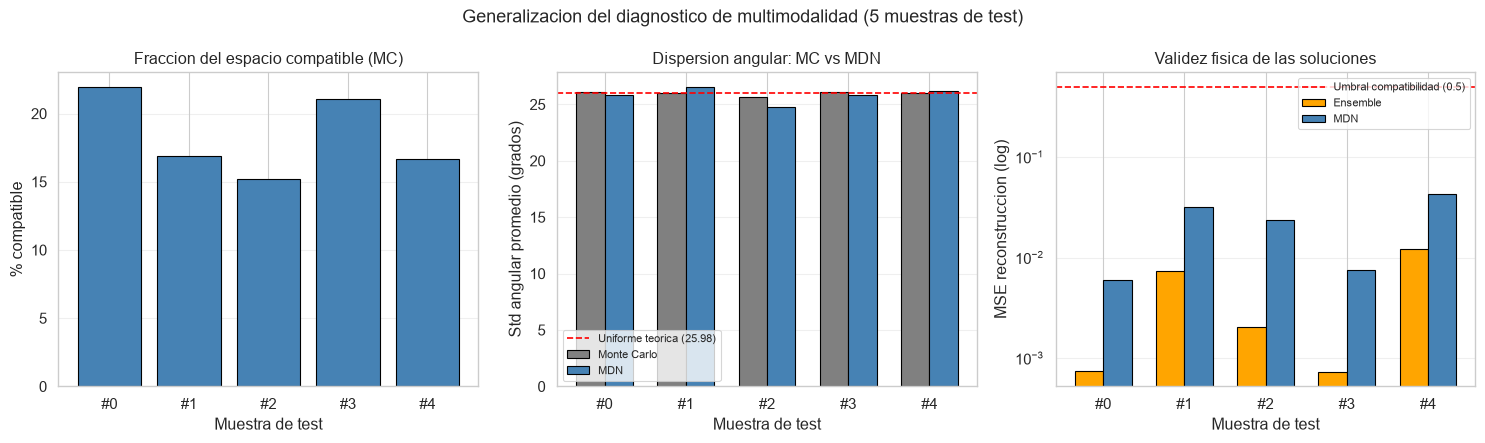

In [55]:
# ======================================================================
# FIGURA RESUMEN MULTI-MUESTRA
# ======================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

idxs = [r['idx'] for r in resultados_ms]
x = np.arange(len(idxs))
w = 0.35

# Panel 1: fraccion compatible MC por muestra
axes[0].bar(x, [r['frac_mc_pct'] for r in resultados_ms],
            color='steelblue', edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels([f"#{i}" for i in idxs])
axes[0].set_xlabel('Muestra de test'); axes[0].set_ylabel('% compatible')
axes[0].set_title('Fraccion del espacio compatible (MC)')
axes[0].grid(alpha=0.3, axis='y')

# Panel 2: std angular promedio, MC vs MDN
std_mc_ang = [np.mean(r['std_mc'][2:5]) for r in resultados_ms]
std_mdn_ang = [np.mean(r['std_mdn'][2:5]) for r in resultados_ms]
axes[1].bar(x - w/2, std_mc_ang, w, label='Monte Carlo', color='gray',
            edgecolor='black')
axes[1].bar(x + w/2, std_mdn_ang, w, label='MDN', color='steelblue',
            edgecolor='black')
axes[1].axhline(90/np.sqrt(12), color='red', linestyle='--',
                label='Uniforme teorica (25.98)')
axes[1].set_xticks(x); axes[1].set_xticklabels([f"#{i}" for i in idxs])
axes[1].set_xlabel('Muestra de test'); axes[1].set_ylabel('Std angular promedio (grados)')
axes[1].set_title('Dispersion angular: MC vs MDN')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis='y')

# Panel 3: error de reconstruccion (log) ensemble vs MDN
axes[2].bar(x - w/2, [r['recon_ens'] for r in resultados_ms], w,
            label='Ensemble', color='orange', edgecolor='black')
axes[2].bar(x + w/2, [r['recon_mdn'] for r in resultados_ms], w,
            label='MDN', color='steelblue', edgecolor='black')
axes[2].axhline(EPSILON_MC, color='red', linestyle='--',
                label=f'Umbral compatibilidad ({EPSILON_MC})')
axes[2].set_yscale('log')
axes[2].set_xticks(x); axes[2].set_xticklabels([f"#{i}" for i in idxs])
axes[2].set_xlabel('Muestra de test'); axes[2].set_ylabel('MSE reconstruccion (log)')
axes[2].set_title('Validez fisica de las soluciones')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3, axis='y')

plt.suptitle('Generalizacion del diagnostico de multimodalidad (5 muestras de test)',
             fontsize=13)
plt.tight_layout()
plt.savefig("figuras/multi_sample_diagnosis.png", dpi=300, bbox_inches='tight')
plt.show()

## Sensibilidad del umbral $\epsilon$ del Monte Carlo

La fracción compatible ($\sim 21\%$) depende del umbral $\epsilon = 0{,}5$, elegido
de forma razonable pero arbitraria. Verificamos que la **conclusión cualitativa**
(dispersión angular $\approx 26^{\circ}$, $\beta$ y $\rho$ acotados) es robusta ante
$\epsilon \in \{0{,}3,\ 0{,}5,\ 0{,}7\}$, evaluando sobre las mismas 5 muestras de test.

La fracción compatible cambia con $\epsilon$ (es su definición); lo que debe ser
estable es la estructura de la distribución de soluciones.

SENSIBILIDAD DE EPSILON (promedio sobre 5 muestras de test)
  eps |  frac compatible % | std ang (grados) |  std Beta |  std Rho
------------------------------------------------------------------------------
  0.3 |      11.56 +/- 1.64 |            25.87 |     4.226 |   0.0384
  0.5 |      18.36 +/- 2.65 |            25.97 |     5.417 |   0.0473
  0.7 |      24.24 +/- 4.70 |            25.96 |     6.337 |   0.0531
------------------------------------------------------------------------------
Referencia: std de una uniforme en [0, 90] = 25.98

Lectura: la fraccion escala con epsilon (por definicion); la dispersion
angular se mantiene en ~26 grados en los tres umbrales, confirmando que la
degeneracion angular no es un artefacto del umbral elegido.


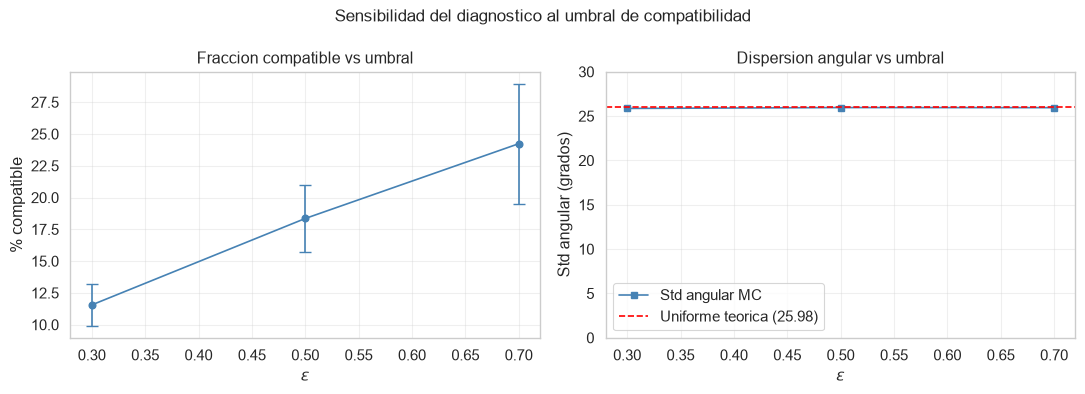

[OK] epsilon_sensitivity.json guardado.


In [56]:
# ======================================================================
# SENSIBILIDAD DE EPSILON: mismas 5 muestras, banco MC identico (semilla 42)
# ======================================================================
EPS_LIST = [0.3, 0.5, 0.7]
IDX_LIST_EPS = [0, 1, 2, 3, 4]

# Banco unico (misma semilla que el multi-muestra)
rng_eps = np.random.RandomState(42)
bank_eps = np.zeros((N_MC_SAMPLES, 5))
for i, col in enumerate(theta_cols):
    lo, hi = THETA_BOUNDS[col]
    bank_eps[:, i] = rng_eps.uniform(lo, hi, N_MC_SAMPLES)
with torch.no_grad():
    G_bank_eps = f_nn(torch.tensor(scaler_X.transform(bank_eps),
                                   dtype=torch.float32).to(device)).cpu().numpy()

resultados_eps = []
for eps in EPS_LIST:
    fracs, std_angs, std_betas, std_rhos = [], [], [], []
    for idx in IDX_LIST_EPS:
        errs = np.mean((G_bank_eps - y_test[idx]) ** 2, axis=1)
        m = errs < eps
        if m.sum() < 2:
            continue
        fracs.append(m.mean() * 100)
        sel = bank_eps[m]
        std_angs.append(sel[:, 2:5].std(axis=0).mean())
        std_betas.append(sel[:, 0].std())
        std_rhos.append(sel[:, 1].std())
    resultados_eps.append({
        "epsilon": eps,
        "frac_mean": float(np.mean(fracs)), "frac_std": float(np.std(fracs)),
        "std_ang_mean": float(np.mean(std_angs)),
        "std_beta_mean": float(np.mean(std_betas)),
        "std_rho_mean": float(np.mean(std_rhos)),
    })

print("=" * 78)
print("SENSIBILIDAD DE EPSILON (promedio sobre 5 muestras de test)")
print("=" * 78)
print(f"{'eps':>5} | {'frac compatible %':>18} | {'std ang (grados)':>16} | "
      f"{'std Beta':>9} | {'std Rho':>8}")
print("-" * 78)
for r in resultados_eps:
    print(f"{r['epsilon']:>5} | {r['frac_mean']:>10.2f} +/- {r['frac_std']:>4.2f} | "
          f"{r['std_ang_mean']:>16.2f} | {r['std_beta_mean']:>9.3f} | "
          f"{r['std_rho_mean']:>8.4f}")
print("-" * 78)
print(f"Referencia: std de una uniforme en [0, 90] = {90/np.sqrt(12):.2f}")
print("\nLectura: la fraccion escala con epsilon (por definicion); la dispersion")
print("angular se mantiene en ~26 grados en los tres umbrales, confirmando que la")
print("degeneracion angular no es un artefacto del umbral elegido.")

# --- Figura ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
eps_v = [r['epsilon'] for r in resultados_eps]
axes[0].errorbar(eps_v, [r['frac_mean'] for r in resultados_eps],
                 yerr=[r['frac_std'] for r in resultados_eps],
                 marker='o', capsize=4, color='steelblue')
axes[0].set_xlabel(r'$\epsilon$'); axes[0].set_ylabel('% compatible')
axes[0].set_title('Fraccion compatible vs umbral')
axes[0].grid(alpha=0.3)

axes[1].plot(eps_v, [r['std_ang_mean'] for r in resultados_eps],
             marker='s', color='steelblue', label='Std angular MC')
axes[1].axhline(90/np.sqrt(12), color='red', linestyle='--',
                label='Uniforme teorica (25.98)')
axes[1].set_xlabel(r'$\epsilon$'); axes[1].set_ylabel('Std angular (grados)')
axes[1].set_ylim(0, 30)
axes[1].set_title('Dispersion angular vs umbral')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Sensibilidad del diagnostico al umbral de compatibilidad', fontsize=12)
plt.tight_layout()
plt.savefig("figuras/epsilon_sensitivity.png", dpi=300, bbox_inches='tight')
plt.show()

with open("jsones/epsilon_sensitivity.json", "w") as f:
    json.dump(resultados_eps, f, indent=2)
print("[OK] epsilon_sensitivity.json guardado.")

# Persistencia de modelos

Guarda todos los objetos entrenados para poder reutilizarlos sin re-ejecutar el
notebook completo. Es especialmente relevante para el GP (unos 20 minutos de
entrenamiento) y el ensamble (diez redes).

**Los scalers son imprescindibles:** sin ellos los pesos guardados no sirven,
porque no se puede transformar una entrada nueva ni interpretar la salida.

Para el GP no se serializan los modelos completos (cada uno arrastra su matriz de
Cholesky de $2240 \times 2240$, unos $40$ MB). Se guardan los **kernels ya optimizados**
y al cargar se reconstruye con `optimizer=None`, lo que evita la parte cara (la
optimización de hiperparámetros) y solo repite la factorización, en segundos.

In [57]:
# =============================================================================
# GUARDAR: redes (state_dict), GP (kernels optimizados), scalers y config
# =============================================================================
import joblib

os.makedirs("modelos", exist_ok=True)

# --- 1. Scalers (imprescindibles) ---
joblib.dump({"scaler_X": scaler_X, "scaler_y": scaler_y,
             "theta_cols": theta_cols, "G_cols": G_cols},
            "modelos/scalers.pkl")
print("[OK] scalers.pkl")

# --- 2. Redes de PyTorch ---
torch.save(f_nn.state_dict(), "modelos/f_nn.pt")
torch.save(f_nn_prob.state_dict(), "modelos/f_nn_prob.pt")
torch.save(i_nn.state_dict(), "modelos/i_nn.pt")
torch.save(mdn.state_dict(), "modelos/mdn_k3.pt")
print("[OK] f_nn, f_nn_prob, i_nn, mdn_k3")

if "mdn_k1" in globals():
    torch.save(mdn_k1.state_dict(), "modelos/mdn_k1.pt")
    print("[OK] mdn_k1 (baseline)")

# --- 3. Ensamble (una sola tanda de pesos) ---
if "ensemble_models" in globals():
    torch.save([m.state_dict() for m in ensemble_models], "modelos/ensemble.pt")
    print(f"[OK] ensemble.pt ({len(ensemble_models)} redes)")

# --- 4. GP: solo kernels optimizados + los datos con que se entrenó ---
if "gp_models" in globals():
    joblib.dump({"kernels": [gp.kernel_ for gp in gp_models],
                 "X_train_gp": X_train_gp,
                 "y_train_gp": y_train_gp},
                "modelos/gp_kernels.pkl")
    print(f"[OK] gp_kernels.pkl ({len(gp_models)} kernels, ligero)")

# --- 5. Config de arquitecturas, para reconstruir sin adivinar ---
config = {
    "f_nn":      {"input_dim": 5, "output_dim": 7, "hidden": [512, 256, 256, 128], "dropout": 0.1},
    "f_nn_prob": {"input_dim": 5, "output_dim": 7, "hidden": [512, 256, 256, 128], "dropout": 0.1},
    "i_nn":      {"input_dim": 7, "output_dim": 5, "hidden": [128, 128, 64], "dropout": 0.1},
    "mdn_k3":    {"input_dim": 7, "output_dim": 5, "K": 3, "hidden": MDN_HIDDEN, "dropout": MDN_DROPOUT},
    "mdn_k1":    {"input_dim": 7, "output_dim": 5, "K": 1, "hidden": MDN_HIDDEN, "dropout": MDN_DROPOUT},
    "n_ensemble": len(ensemble_models) if "ensemble_models" in globals() else None,
    "max_train_gp": len(X_train_gp) if "X_train_gp" in globals() else None,
}
with open("modelos/config.json", "w") as f:
    json.dump(config, f, indent=2)
print("[OK] config.json")

print("\nArchivos en modelos/:")
for f_ in sorted(os.listdir("modelos")):
    mb = os.path.getsize(os.path.join("modelos", f_)) / 1e6
    print(f"  {f_:<22} {mb:>7.2f} MB")

[OK] scalers.pkl
[OK] f_nn, f_nn_prob, i_nn, mdn_k3
[OK] mdn_k1 (baseline)
[OK] ensemble.pt (10 redes)
[OK] gp_kernels.pkl (7 kernels, ligero)
[OK] config.json

Archivos en modelos/:
  config.json               0.00 MB
  ensemble.pt               1.07 MB
  f_nn.pt                   0.94 MB
  f_nn_best.pt              0.94 MB
  f_nn_prob.pt              0.94 MB
  f_nn_prob_best.pt         0.94 MB
  gp_kernels.pkl            0.22 MB
  i_nn.pt                   0.11 MB
  i_nn_best.pt              0.11 MB
  mdn_best.pt               0.12 MB
  mdn_k1.pt                 0.11 MB
  mdn_k3.pt                 0.12 MB
  scalers.pkl               0.00 MB


### Carga de modelos

Celda autocontenida: reconstruye todos los modelos desde disco sin re-entrenar.
Requiere que las clases (`ForwardNN`, `ForwardNNProb`, `InverseNN`, `MDN`) estén
definidas, es decir, haber ejecutado las celdas que las declaran, no las que las
entrenan.

In [62]:
# =============================================================================
# CARGAR: reconstruye todos los modelos desde disco (sin re-entrenar)
# =============================================================================
import joblib

# --- Scalers y config ---
_s = joblib.load("modelos/scalers.pkl")
scaler_X, scaler_y = _s["scaler_X"], _s["scaler_y"]
theta_cols, G_cols = _s["theta_cols"], _s["G_cols"]
with open("modelos/config.json") as f:
    config = json.load(f)
print("[OK] scalers y config")

# --- Redes ---
f_nn = ForwardNN(**{k: v for k, v in config["f_nn"].items()}).to(device)
f_nn.load_state_dict(torch.load("modelos/f_nn.pt", map_location=device))
f_nn.eval()

f_nn_prob = ForwardNNProb(**{k: v for k, v in config["f_nn_prob"].items()}).to(device)
f_nn_prob.load_state_dict(torch.load("modelos/f_nn_prob.pt", map_location=device))
f_nn_prob.eval()

i_nn = InverseNN(**{k: v for k, v in config["i_nn"].items()})
i_nn.load_state_dict(torch.load("modelos/i_nn.pt", map_location="cpu"))
i_nn.eval()

mdn = MDN(**config["mdn_k3"]).to(device)
mdn.load_state_dict(torch.load("modelos/mdn_k3.pt", map_location=device))
mdn.eval()
print("[OK] f_nn, f_nn_prob, i_nn, mdn (K=3)")

# --- Baseline K=1 ---
if os.path.exists("modelos/mdn_k1.pt"):
    mdn_k1 = MDN(**config["mdn_k1"]).to(device)
    mdn_k1.load_state_dict(torch.load("modelos/mdn_k1.pt", map_location=device))
    mdn_k1.eval()
    print("[OK] mdn_k1")

# --- Ensamble: sus miembros son nn.Sequential, no InverseNN ---
def _build_inv_sequential(hidden, dropout):
    """Replica la arquitectura de train_single_i_nn()."""
    layers, prev = [], 7
    for h in hidden:
        layers.extend([nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)])
        prev = h
    layers.append(nn.Linear(prev, 5))
    return nn.Sequential(*layers)

if os.path.exists("modelos/ensemble.pt"):
    estados = torch.load("modelos/ensemble.pt", map_location="cpu")
    # Fallback por si el config es de una version anterior
    cfg_e = config.get("ensemble", {"hidden": [128, 128, 64], "dropout": 0.1})
    ensemble_models = []
    for st in estados:
        m_ = _build_inv_sequential(cfg_e["hidden"], cfg_e["dropout"])
        m_.load_state_dict(st)
        m_.eval()
        ensemble_models.append(m_)
    print(f"[OK] ensemble ({len(ensemble_models)} redes)")

# --- GP: refit con kernel fijo (optimizer=None) ---
if os.path.exists("modelos/gp_kernels.pkl"):
    _g = joblib.load("modelos/gp_kernels.pkl")
    X_train_gp, y_train_gp = _g["X_train_gp"], _g["y_train_gp"]
    t0 = time.time()
    gp_models = []
    for j, kern in enumerate(_g["kernels"]):
        gp_j = GaussianProcessRegressor(kernel=kern, optimizer=None, normalize_y=True)
        gp_j.fit(X_train_gp, y_train_gp[:, j])   # solo Cholesky, sin optimizar
        gp_models.append(gp_j)
    print(f"[OK] gp_models ({len(gp_models)} GP reconstruidos en {time.time()-t0:.1f} s)")

print("\nModelos listos. Verificacion rapida:")
with torch.no_grad():
    _r2 = r2_score(y_test, f_nn(torch.tensor(X_test, dtype=torch.float32).to(device)).cpu().numpy())
print(f"  R2 de la f-NN cargada en test: {_r2:.4f}")

[OK] scalers y config
[OK] f_nn, f_nn_prob, i_nn, mdn (K=3)
[OK] mdn_k1
[OK] ensemble (10 redes)
[OK] gp_models (7 GP reconstruidos en 3.5 s)

Modelos listos. Verificacion rapida:
  R2 de la f-NN cargada en test: 0.9867


# Comprobación de los modelos

Sección interactiva para probar los modelos entrenados en ambas direcciones:

- **Directo** ($\Theta \to G$): se ingresan los 5 parámetros de diseño y se obtiene
  la predicción de las 7 propiedades geométricas (f-NN, f-NN-prob con incertidumbre y GP).
- **Inverso** ($G \to \Theta$): se ingresa una geometría objetivo y se obtienen
  parámetros candidatos (i-NN, ensemble y modos de la MDN) para generar la geometría
  externamente y comparar.

Requiere haber ejecutado antes las secciones de f-NN, f-NN-prob, GP, ensemble y MDN.

### Funciones de comprobación

In [63]:
# Funciones de prediccion que aceptan valores en escala fisica (original)

def predecir_directo(beta, rho, aniso_x, aniso_y, aniso_z):
    """Theta (escala fisica) -> G predicho por f-NN, f-NN-prob y GP."""
    theta = np.array([[beta, rho, aniso_x, aniso_y, aniso_z]], dtype=float)
    theta_n = scaler_X.transform(theta)
    theta_t = torch.tensor(theta_n, dtype=torch.float32).to(device)

    out = {}

    # f-NN determinista
    f_nn.eval()
    with torch.no_grad():
        out['f-NN'] = scaler_y.inverse_transform(f_nn(theta_t).cpu().numpy())[0]

    # f-NN-prob (media + desviacion)
    if 'f_nn_prob' in globals():
        f_nn_prob.eval()
        with torch.no_grad():
            mu, log_var = f_nn_prob(theta_t)
            mu = mu.cpu().numpy()[0]
            sigma = np.exp(0.5 * log_var.cpu().numpy()[0])
        G_mu = scaler_y.inverse_transform(mu.reshape(1, -1))[0]
        G_sigma = sigma * scaler_y.scale_          # desviacion en escala original
        out['f-NN-prob'] = (G_mu, G_sigma)

    # GP (media + desviacion), si se guardaron los modelos
    if 'gp_models' in globals() and len(gp_models) == len(G_cols):
        mu_gp = np.zeros(len(G_cols)); sd_gp = np.zeros(len(G_cols))
        for j, gp_j in enumerate(gp_models):
            m, s = gp_j.predict(theta_n, return_std=True)
            mu_gp[j] = m[0]; sd_gp[j] = s[0]
        G_gp = scaler_y.inverse_transform(mu_gp.reshape(1, -1))[0]
        out['GP'] = (G_gp, sd_gp * scaler_y.scale_)

    return out


def predecir_inverso(G_objetivo):
    """G objetivo (escala fisica, 7 valores) -> Theta candidatos (i-NN, ensemble, MDN)."""
    G_obj = np.array(G_objetivo, dtype=float).reshape(1, -1)
    G_t = torch.tensor(scaler_y.transform(G_obj), dtype=torch.float32)

    out = {}

    # Ensemble de i-NN
    if 'ensemble_models' in globals():
        preds = []
        for m_ in ensemble_models:
            with torch.no_grad():
                preds.append(m_(G_t).numpy()[0])
        out['ensemble'] = scaler_X.inverse_transform(np.array(preds))   # [M, 5]

    # MDN: modos (medias de cada componente) con sus pesos
    if 'mdn' in globals():
        mdn.eval()
        with torch.no_grad():
            logits, mu, log_var = mdn(G_t.to(device))
        out['mdn_pesos'] = torch.softmax(logits, dim=1).cpu().numpy()[0]
        mu = mu.cpu().numpy()[0]
        out['mdn_modos'] = scaler_X.inverse_transform(mu)              # [K, 5]
        out['mdn_sigmas'] = np.exp(0.5 * log_var.cpu().numpy()[0]) * scaler_X.scale_

    return out


def reconstruir(theta_fisico):
    """Theta (escala fisica) -> G via f-NN. Verifica que un candidato reproduce G*."""
    theta = np.array(theta_fisico, dtype=float).reshape(1, -1)
    theta_t = torch.tensor(scaler_X.transform(theta), dtype=torch.float32).to(device)
    f_nn.eval()
    with torch.no_grad():
        return scaler_y.inverse_transform(f_nn(theta_t).cpu().numpy())[0]

print("Funciones listas: predecir_directo(), predecir_inverso(), reconstruir()")

Funciones listas: predecir_directo(), predecir_inverso(), reconstruir()


### Comprobación directa ($\Theta \to G$)

Edita los 5 parámetros y ejecuta. Devuelve la geometría predicha por cada modelo.

In [64]:
# --- Ingresa aqui los parametros de diseno (escala fisica) ---
beta    = 30.0     # rango fisico ~ [6.28, 47.12]
rho     = 0.5      # rango fisico [0.3, 0.7]
aniso_x = 45.0     # rango fisico [0, 89.9]
aniso_y = 45.0
aniso_z = 45.0

resultado = predecir_directo(beta, rho, aniso_x, aniso_y, aniso_z)

print("=" * 68)
print(f"ENTRADA  Theta = (beta={beta}, rho={rho}, "
      f"ax={aniso_x}, ay={aniso_y}, az={aniso_z})")
print("=" * 68)
print(f"{'Propiedad':<16} {'f-NN':>10} {'f-NN-prob':>18} {'GP':>18}")
print("-" * 68)
for j, col in enumerate(G_cols):
    fnn_v = f"{resultado['f-NN'][j]:.4f}"
    if 'f-NN-prob' in resultado:
        mu, sd = resultado['f-NN-prob']
        prob_v = f"{mu[j]:.4f} +/- {sd[j]:.3f}"
    else:
        prob_v = "-"
    if 'GP' in resultado:
        mug, sdg = resultado['GP']
        gp_v = f"{mug[j]:.4f} +/- {sdg[j]:.3f}"
    else:
        gp_v = "-"
    print(f"{col:<16} {fnn_v:>10} {prob_v:>18} {gp_v:>18}")
print("-" * 68)

ENTRADA  Theta = (beta=30.0, rho=0.5, ax=45.0, ay=45.0, az=45.0)
Propiedad              f-NN          f-NN-prob                 GP
--------------------------------------------------------------------
Area_Inner           8.4424   8.4924 +/- 0.132   8.4319 +/- 0.066
Area_Outer           2.4947   2.5241 +/- 0.064   2.5475 +/- 0.054
Total_Area          10.9356  11.0245 +/- 0.139  11.0189 +/- 0.096
Volume               0.3898   0.3900 +/- 0.005   0.3910 +/- 0.005
SA_Vol_Ratio        28.1660  28.2454 +/- 0.471  27.9798 +/- 0.440
Porosity             0.5061   0.5058 +/- 0.007   0.5045 +/- 0.006
Pore_Size            0.1369   0.1349 +/- 0.008   0.1358 +/- 0.016
--------------------------------------------------------------------


### Comprobación inversa ($G \to \Theta$)

Ingresa una geometría objetivo (7 propiedades). Los modelos proponen parámetros de
diseño candidatos. Como el mapeo es multimodal, se entregan varias soluciones: cada
una debería reproducir la geometría objetivo al generarla. Copia el $\Theta$ elegido
a tu script de generación de geometrías.

Sugerencia: usa como objetivo una muestra real del test para comparar contra su
$\Theta$ verdadero.

In [65]:
# --- Opcion A: usar una muestra real del test como objetivo ---
IDX_OBJETIVO = 0
G_objetivo = scaler_y.inverse_transform(y_test[IDX_OBJETIVO:IDX_OBJETIVO+1])[0]
theta_real = scaler_X.inverse_transform(X_test[IDX_OBJETIVO:IDX_OBJETIVO+1])[0]

# --- Opcion B: ingresar G manualmente (descomenta y edita) ---
# G_objetivo = [area_inner, area_outer, total_area, volume, sa_vol, porosity, pore_size]
# theta_real = None

print("=" * 60)
print("GEOMETRIA OBJETIVO (G*)")
print("=" * 60)
for col, v in zip(G_cols, G_objetivo):
    print(f"  {col:<16}: {v:.4f}")

cand = predecir_inverso(G_objetivo)

# --- Modos de la MDN (solucion recomendada: interpretable) ---
if 'mdn_modos' in cand:
    print("\n" + "=" * 60)
    print("MODOS DE LA MDN  (cada modo es un candidato Theta)")
    print("=" * 60)
    orden = np.argsort(-cand['mdn_pesos'])   # de mayor a menor peso
    for rank, k in enumerate(orden):
        print(f"\nModo {rank+1}  (peso pi = {cand['mdn_pesos'][k]:.3f})")
        for j, col in enumerate(theta_cols):
            print(f"   {col:<10}: {cand['mdn_modos'][k][j]:8.3f} "
                  f"+/- {cand['mdn_sigmas'][k][j]:.3f}")

# --- Media del ensemble ---
if 'ensemble' in cand:
    ens_mean = cand['ensemble'].mean(axis=0)
    ens_std = cand['ensemble'].std(axis=0)
    print("\n" + "=" * 60)
    print("ENSEMBLE (media +/- std de las 10 redes)")
    print("=" * 60)
    for j, col in enumerate(theta_cols):
        print(f"   {col:<10}: {ens_mean[j]:8.3f} +/- {ens_std[j]:.3f}")

# --- Referencia: Theta verdadero (si el objetivo vino del test) ---
if theta_real is not None:
    print("\n" + "=" * 60)
    print("THETA VERDADERO (referencia)")
    print("=" * 60)
    for j, col in enumerate(theta_cols):
        print(f"   {col:<10}: {theta_real[j]:8.3f}")

GEOMETRIA OBJETIVO (G*)
  Area_Inner      : 9.4850
  Area_Outer      : 2.6196
  Total_Area      : 12.1047
  Volume          : 0.4022
  SA_Vol_Ratio    : 30.0996
  Porosity        : 0.4903
  Pore_Size       : 0.1214

MODOS DE LA MDN  (cada modo es un candidato Theta)

Modo 1  (peso pi = 0.813)
   Beta      :   33.948 +/- 0.404
   Rho       :    0.510 +/- 0.007
   Aniso_X   :   46.479 +/- 25.559
   Aniso_Y   :   45.653 +/- 26.583
   Aniso_Z   :   44.376 +/- 25.591

Modo 2  (peso pi = 0.103)
   Beta      :   34.732 +/- 0.359
   Rho       :    0.512 +/- 0.007
   Aniso_X   :   45.181 +/- 27.340
   Aniso_Y   :   53.437 +/- 21.369
   Aniso_Z   :   45.905 +/- 24.713

Modo 3  (peso pi = 0.085)
   Beta      :   34.806 +/- 0.505
   Rho       :    0.520 +/- 0.007
   Aniso_X   :   45.598 +/- 27.237
   Aniso_Y   :   27.380 +/- 19.648
   Aniso_Z   :   42.150 +/- 25.181

ENSEMBLE (media +/- std de las 10 redes)
   Beta      :   34.249 +/- 0.196
   Rho       :    0.514 +/- 0.001
   Aniso_X   :   16.284

### Verificación de un candidato

Antes de generar la geometría externamente, verifica que el $\Theta$ candidato
reproduce la geometría objetivo pasándolo por la f-NN. Un error de reconstrucción
bajo confirma que el candidato es una solución válida aunque difiera del $\Theta$ real.

In [66]:
# --- Copia aqui el Theta candidato que quieras verificar ---
theta_candidato = [30.0, 0.5, 45.0, 45.0, 45.0]   # [beta, rho, ax, ay, az]

G_reconstruido = reconstruir(theta_candidato)

print("Theta candidato:", dict(zip(theta_cols, np.round(theta_candidato, 3))))
print("\n{:<16} {:>12} {:>12} {:>10}".format("Propiedad", "Objetivo", "Reconstruido", "Error %"))
print("-" * 54)
err_rel = []
for j, col in enumerate(G_cols):
    obj = G_objetivo[j]
    rec = G_reconstruido[j]
    e = abs(rec - obj) / (abs(obj) + 1e-9) * 100
    err_rel.append(e)
    print(f"{col:<16} {obj:>12.4f} {rec:>12.4f} {e:>9.2f}%")
print("-" * 54)
print(f"Error relativo medio: {np.mean(err_rel):.2f}%")
print("\nSi el error es bajo, este Theta es valido -> generarlo con tu script externo.")

Theta candidato: {'Beta': np.float64(30.0), 'Rho': np.float64(0.5), 'Aniso_X': np.float64(45.0), 'Aniso_Y': np.float64(45.0), 'Aniso_Z': np.float64(45.0)}

Propiedad            Objetivo Reconstruido    Error %
------------------------------------------------------
Area_Inner             9.4850       8.4424     10.99%
Area_Outer             2.6196       2.4947      4.77%
Total_Area            12.1047      10.9356      9.66%
Volume                 0.4022       0.3898      3.09%
SA_Vol_Ratio          30.0996      28.1660      6.42%
Porosity               0.4903       0.5061      3.22%
Pore_Size              0.1214       0.1369     12.74%
------------------------------------------------------
Error relativo medio: 7.27%

Si el error es bajo, este Theta es valido -> generarlo con tu script externo.
